
# SECTION 1: SETUP AND DATA LOADING


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_ind, f_oneway
from typing import Dict, List, Tuple, Optional

# Set plotting style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams.update({'font.size': 12})

# Define column mappings for easier reference
column_mapping = {
    # Demographics
    "¿En qué país resides?": "Country",
    "Tu edad está dentro del rango:": "Age_Range",
    "¿Tu género es?": "Gender",
    "NIVEL HOMEOFFICE": "RemoteWork_Level",
    
    # Performance metrics
    "Siento que mi rendimiento ahora es:": "Performance",
    "Siento que la productividad de mi equipo es:": "Team_Productivity",
    "Siento que la capacidad de mi equipo para cumplir hitos es:": "Team_Milestones",
    "Siento que mi concentración cuando estoy trabajando es:": "Concentration",
    
    # Stress metrics
    "Siento que mi nivel de estrés es:": "Stress_Level",
    "Siento que mi nivel de confianza para enfrentarme a los retos del trabajo es:": "Confidence_Level",
    "Siento que mi nivel de frustración con relación al trabajo es:": "Frustration",
    "Siento que el nivel de presión por terminar las tareas ahora es:": "Task_Pressure",
    "Siento que la flexibilidad de mi trabajo ahora es:": "Flexibility",
    "Siento que los problemas de comunicación ahora son:": "Communication_Issues",
    "Siento que la generación de confianza entre los miembros del equipo ahora es:": "Team_Trust",
    "Siento que ahora mi manejo del tiempo en general es:": "Time_Management",
    "Siento que los problemas de coordinación afectan a mi estrés:": "Coordination_Issues",
    
    # Motivation metrics
    "Siento que mi nivel de motivación en el trabajo es:": "Motivation",
    "Mi comodidad ahora cuando estoy trabajando es:": "Comfort",
    "Mi confianza para hacer preguntas a un superior ahora es:": "Trust_in_Superior",
    "Mi habilidad para resolver problemas ahora es:": "Problem_Solving",
    "En términos de disfrute en el trabajo siento que ahora es:": "Work_Enjoyment",
    "Siento que el nivel de interés hacia mi trabajo ahora es:": "Work_Interest",
    "Siento que mi empresa me aprecia:": "Company_Appreciation", 
    "Siento que el equilibrio vida personal - trabajo es ahora:": "Work_Life_Balance",
    "Siento que ahora la retroalimentación que recibo por parte de mis compañeros y superiores es:": "Feedback",
    "Siento que mi nivel de aburrimiento en el trabajo es ahora:": "Boredom",
    "Siento que mi nivel de atención a cada individuo es ahora:": "Attention_to_Others",
    "Siento que mi miedo a perder el trabajo es ahora:": "Job_Loss_Fear",
    "Siento que el ambiente de trabajo ahora es:": "Work_Environment",
    "Siento que mi nivel de influencia en mi equipo de trabajo es ahora:": "Team_Influence",
    "Siento que la facilidad para desarrollar relaciones personales entre los compañeros de trabajo es ahora": "Personal_Relationships",
    "Siento que el nivel de autonomía en el trabajo es ahora": "Autonomy",
    "Siento que el nivel de relaciones conflictivas entre compañeros es ahora:": "Conflict_Relationships",
    "El sentimiento de pertenencia a mi empresa es ahora": "Belonging",
    "Siento que mi creatividad es:": "Creativity"
}

# %%
# Define the ordinal mapping for converting categorical responses to numeric
ordinal_mapping = {
    # Much lower performance
    "Mucho menor que cuando iba todos los días a la oficina": 1,
    "Mucho menos que cuando iba todos los días a la oficina": 1,
    "Mucho menores que cuando iba todos los días a la oficina": 1,
    "Mucho peor que cuando iba todos los días a la oficina": 1,
    "Muy Negativamente a la hora de desempeñar mi trabajo": 1,
    
    # Lower performance
    "Menor que cuando iba todos los días a la oficina": 2,
    "Menores que cuando iba todos los días a la oficina": 2,
    "Menor cuando iba todos los días a la oficina": 2,
    "Menos que cuando iba todos los días a la oficina": 2,
    "Peor que cuando iba todos los días a la oficina": 2,
    "Negativamente a la hora de desempeñar mi trabajo": 2,

    # Same performance
    "Igual que cuando iba todos los días a la oficina": 3,
    "Iguales que cuando iba todos los días a la oficina": 3,

    # Higher performance
    "Mayor que cuando iba todos los días a la oficina": 4,
    "Mayores que cuando iba todos los días a la oficina": 4,
    "Mas que cuando iba todos los días a la oficina": 4,
    "Más que cuando iba todos los días a la oficina": 4,
    "Mejor que cuando iba todos los días a la oficina": 4,
    "Mejora mi desempeño en el trabajo": 4,

    # Much higher performance
    "Mucho mayor que cuando iba todos los días a la oficina": 5,
    "Mucho mas que cuando iba todos los días a la oficina": 5,
    "Mucho Mayor que cuando iba todos los días a la oficina": 5,
    "Mucho mayores que cuando iba todos los días a la oficina": 5,
    "Mucho más que cuando iba todos los días a la oficina": 5,
    "Mucho mejor que cuando iba todos los días a la oficina": 5,
    "Mucho Mejor que cuando iba todos los días a la oficina": 5,
    "Mejora mucho mi desempeño en el trabajo": 5,

    # Neutral / No influence
    "No tengo la información para contestar a la pregunta": 0,
    "No trabajo con personas de distintas culturas": 0,
    "No hay diferencias culturales en mi equipo": 0,
    "No me influye": 0,
    "No tengo que utilizar diferentes idiomas en mi trabajo": 0,
    "No trabajo  con personas que se encuentran geográficamente distribuidas": 0,
    "No trabajo con personas con distintos horarios": 0,
    "No trabajo con personas con un horario distinto al mío": 0
}

# %%
# Load the data
def load_data(file_path: str) -> pd.DataFrame:
    """
    Load data from Excel file and perform initial cleaning
    """
    print(f"Loading data from {file_path}...")
    df = pd.read_excel(file_path, sheet_name="Datos")
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Reset index
    df.reset_index(inplace=True, drop=True)
    
    print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")
    return df

# Load the survey data
file_path = "data_prueba2.xlsx"  # Update this path if your file is located elsewhere
df = load_data(file_path)

# Display the first few rows to understand the data structure
df.head(4)

Loading data from data_prueba2.xlsx...
Loaded dataset with 232 rows and 100 columns.


,Marca temporal,¿En qué país resides?,Tu edad está dentro del rango:,¿Tu género es?,Indica tu nivel de estudios:,Actualmente trabajas:,"En el caso de trabajar para una empresa, indica en qué país está su sede principal:",Indica los años de experiencia trabajando en empresas de desarrollo de software:,Indica los años que has trabajado de forma presencial,Por favor indica el puesto que ocupabas cuando trabajabas presencialmente en la empresa:,...,Siento que el ambiente de trabajo ahora es:,Siento que mi nivel de influencia en mi equipo de trabajo es ahora:,Siento que la facilidad para desarrollar relaciones personales entre los compañeros de trabajo es ahora,Siento que la participación de los miembros en los proyectos de mi equipo es ahora:,Siento que el nivel de autonomía en el trabajo es ahora,Siento que el nivel de relaciones conflictivas entre compañeros es ahora:,Siento que los problemas relacionados con el liderazgo compartido son ahora:,El sentimiento de pertenencia a mi empresa es ahora,Siento que mi creatividad es:,Correo electrónico para recibir resultados (opcional)
0,2024-10-29 02:39:32.204,Argentina,<35 años,Masculino,Universitarios completo,Como empleado de una empresa,Argentina,5-10 años,<5 años,Desarrollador de Software,...,Igual que cuando iba todos los días a la oficina,Menor que cuando iba todos los días a la oficina,Menor que cuando iba todos los días a la oficina,Mayor que cuando iba todos los días a la oficina,Mucho Mayor que cuando iba todos los días a la...,Mucho menor que cuando iba todos los días a la...,Menores que cuando iba todos los días a la ofi...,Igual que cuando iba todos los días a la oficina,Igual que cuando iba todos los días a la oficina,juan.delafuente@fi.uncoma.edu.ar
1,2024-10-04 16:16:59.618,Argentina,<35 años,Femenino,Universitarios,Como empleado de una empresa,Argentina,<5 años,<5 años,Ing. En yacimiento digital,...,Mejor que cuando iba todos los días a la oficina,Igual que cuando iba todos los días a la oficina,Igual que cuando iba todos los días a la oficina,Igual que cuando iba todos los días a la oficina,Mucho Mayor que cuando iba todos los días a la...,Igual que cuando iba todos los días a la oficina,Iguales que cuando iba todos los días a la ofi...,Igual que cuando iba todos los días a la oficina,Igual que cuando iba todos los días a la oficina,NaN
2,2024-10-07 02:20:49.941,Argentina,<35 años,Femenino,universitario,De ambas formas,Argentina,21-30 años,5-10 años,Referente IT,...,Mejor que cuando iba todos los días a la oficina,Mayor que cuando iba todos los días a la oficina,Igual que cuando iba todos los días a la oficina,Mayor que cuando iba todos los días a la oficina,Mayor que cuando iba todos los días a la oficina,Menor que cuando iba todos los días a la oficina,Menores que cuando iba todos los días a la ofi...,Menor que cuando iba todos los días a la oficina,Mayor que cuando iba todos los días a la oficina,baeza.natalia@gmail.com
3,2024-10-31 14:20:11.092,Argentina,<35 años,Masculino,Universitario completo,De forma autónoma/independiente/freelance,Estados Unidos,5-10 años,10-20 años,Software Engineer,...,Mejor que cuando iba todos los días a la oficina,Menor que cuando iba todos los días a la oficina,Mucho menor que cuando iba todos los días a la...,Igual que cuando iba todos los días a la oficina,Mayor que cuando iba todos los días a la oficina,Igual que cuando iba todos los días a la oficina,Iguales que cuando iba todos los días a la ofi...,Igual que cuando iba todos los días a la oficina,Mucho mayor que cuando iba todos los días a la...,NaN


# SECTION 2: DATA CLEANING AND PREPROCESSING

After cleaning: 232 rows, 100 columns
Distribution by Country:
Country
México       89
Colombia     63
España       56
Argentina    24
Name: count, dtype: int64

Distribution by Gender:
Gender
Masculino     184
Femenino       47
No binario      1
Name: count, dtype: int64

Distribution by Age Range:
Age_Range
<35 años    130
36+ años    102
Name: count, dtype: int64

Distribution by Remote Work Level:
RemoteWork_Level
Alto    194
Bajo     38
Name: count, dtype: int64


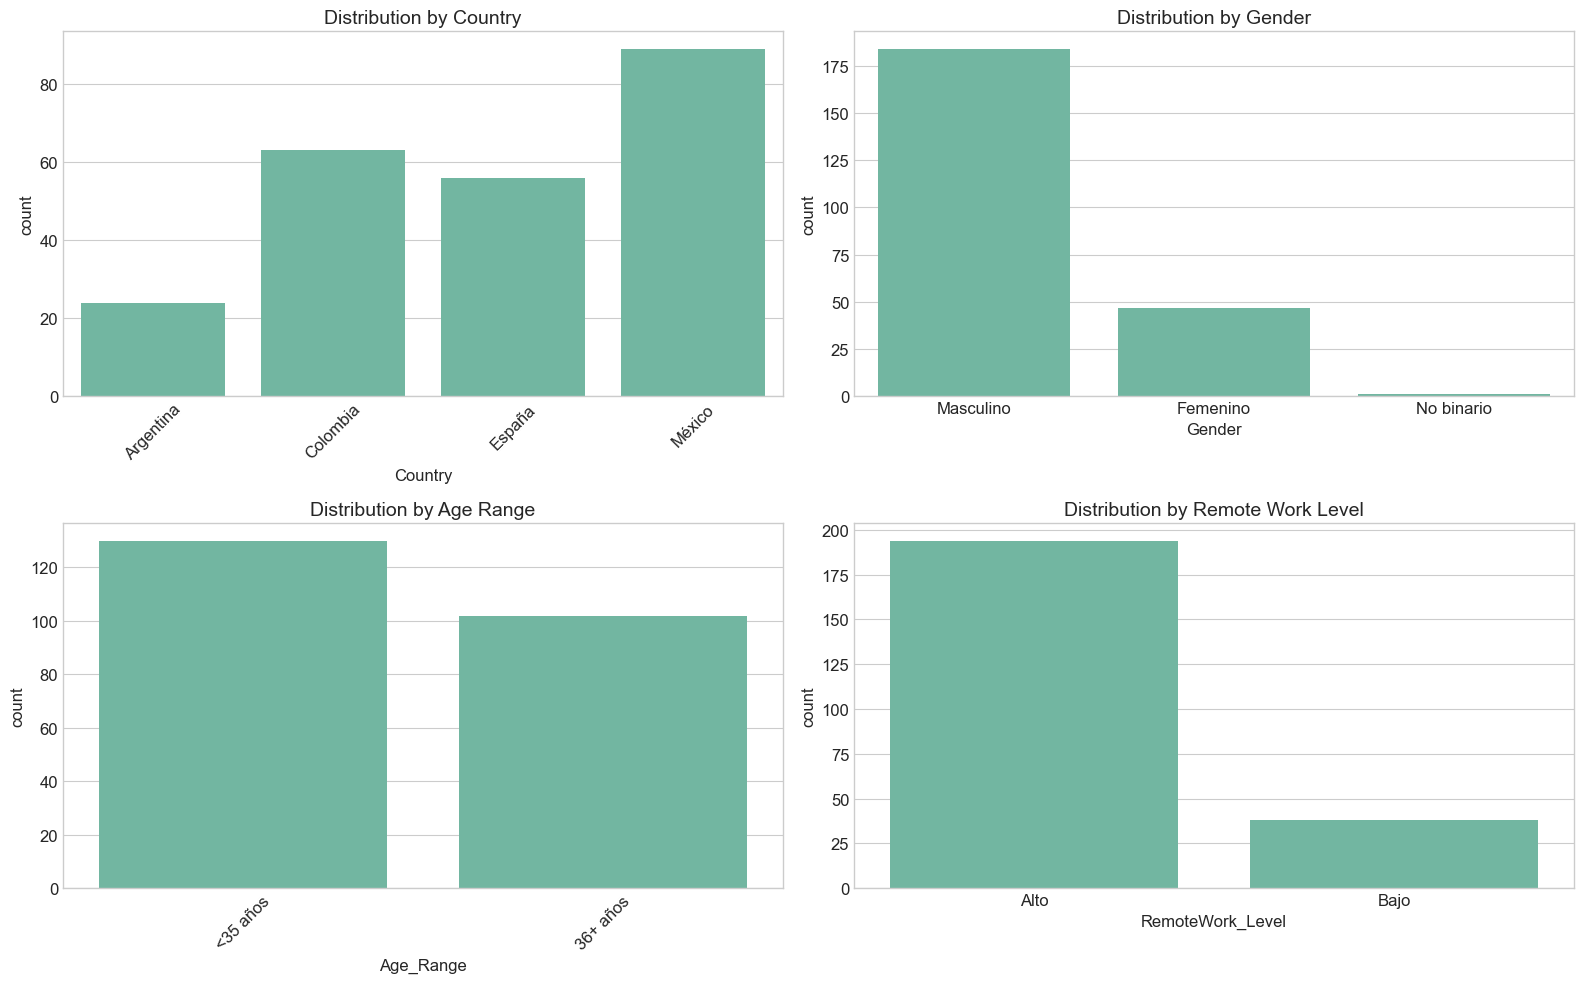

Missing values in key metrics:
Performance          0
Team_Productivity    0
Team_Milestones      0
Concentration        0
Stress_Level         0
Motivation           0
Work_Enjoyment       0
Work_Life_Balance    0
Creativity           0
dtype: int64


In [ ]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean the data by removing duplicates and renaming columns
    """
    # Remove duplicates
    df_clean = df.drop_duplicates()
    
    # Rename columns using the mapping
    df_clean = df_clean.rename(columns=column_mapping)
    
    # Convert categorical responses to numeric
    for col in df_clean.columns:
        if col in column_mapping.values():
            if col not in ['Country', 'Age_Range', 'Gender', 'RemoteWork_Level']:
                df_clean[col] = df_clean[col].map(ordinal_mapping)
    
    print(f"After cleaning: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
    return df_clean

# %%
# Clean the data
df_clean = clean_data(df)

# %%
# Demographic distributions to understand our sample
print("Distribution by Country:")
country_counts = df_clean['Country'].value_counts()
print(country_counts)

print("\nDistribution by Gender:")
gender_counts = df_clean['Gender'].value_counts()
print(gender_counts)

print("\nDistribution by Age Range:")
age_counts = df_clean['Age_Range'].value_counts()
print(age_counts)

print("\nDistribution by Remote Work Level:")
remote_counts = df_clean['RemoteWork_Level'].value_counts()
print(remote_counts)

# %%
# Visualize demographic distributions
plt.figure(figsize=(16, 10))

# Country distribution
plt.subplot(2, 2, 1)
sns.countplot(x='Country', data=df_clean)
plt.title('Distribution by Country', fontsize=14)
plt.xticks(rotation=45)

# Gender distribution
plt.subplot(2, 2, 2)
sns.countplot(x='Gender', data=df_clean)
plt.title('Distribution by Gender', fontsize=14)

# Age distribution
plt.subplot(2, 2, 3)
age_order = ['<35 años', '36+ años']
sns.countplot(x='Age_Range', data=df_clean, order=age_order)
plt.title('Distribution by Age Range', fontsize=14)
plt.xticks(rotation=45)

# Remote Work Level distribution
plt.subplot(2, 2, 4)
sns.countplot(x='RemoteWork_Level', data=df_clean)
plt.title('Distribution by Remote Work Level', fontsize=14)

plt.tight_layout()
plt.show()

# %%
# Check for missing values in key metrics
key_metrics = [
    'Performance', 'Team_Productivity', 'Team_Milestones', 'Concentration',
    'Stress_Level', 'Motivation', 'Work_Enjoyment', 'Work_Life_Balance',
    'Creativity'
]

missing_data = df_clean[key_metrics].isnull().sum()
print("Missing values in key metrics:")
print(missing_data)

# SECTION 3: DESCRIPTIVE STATISTICS BY DEMOGRAPHIC GROUPS

===== STATISTICS BY REMOTE WORK LEVEL =====

Performance Metrics by Remote Work Level:
RemoteWork_Level       Alto      Bajo
Metric                               
Concentration      3.649485  3.526316
Performance        3.896907  3.473684
Team_Milestones    3.391753  3.184211
Team_Productivity  3.505155  3.289474

Stress Metrics by Remote Work Level:
RemoteWork_Level         Alto      Bajo
Metric                                 
Coordination_Issues  2.845361  2.710526
Frustration          2.530928  2.736842
Stress_Level         2.324742  2.421053
Task_Pressure        2.932990  3.157895

Motivation Metrics by Remote Work Level:
RemoteWork_Level       Alto      Bajo
Metric                               
Creativity         3.768041  3.342105
Motivation         3.690722  3.184211
Work_Enjoyment     3.974227  3.500000
Work_Interest      3.396907  3.157895
Work_Life_Balance  4.123711  3.789474


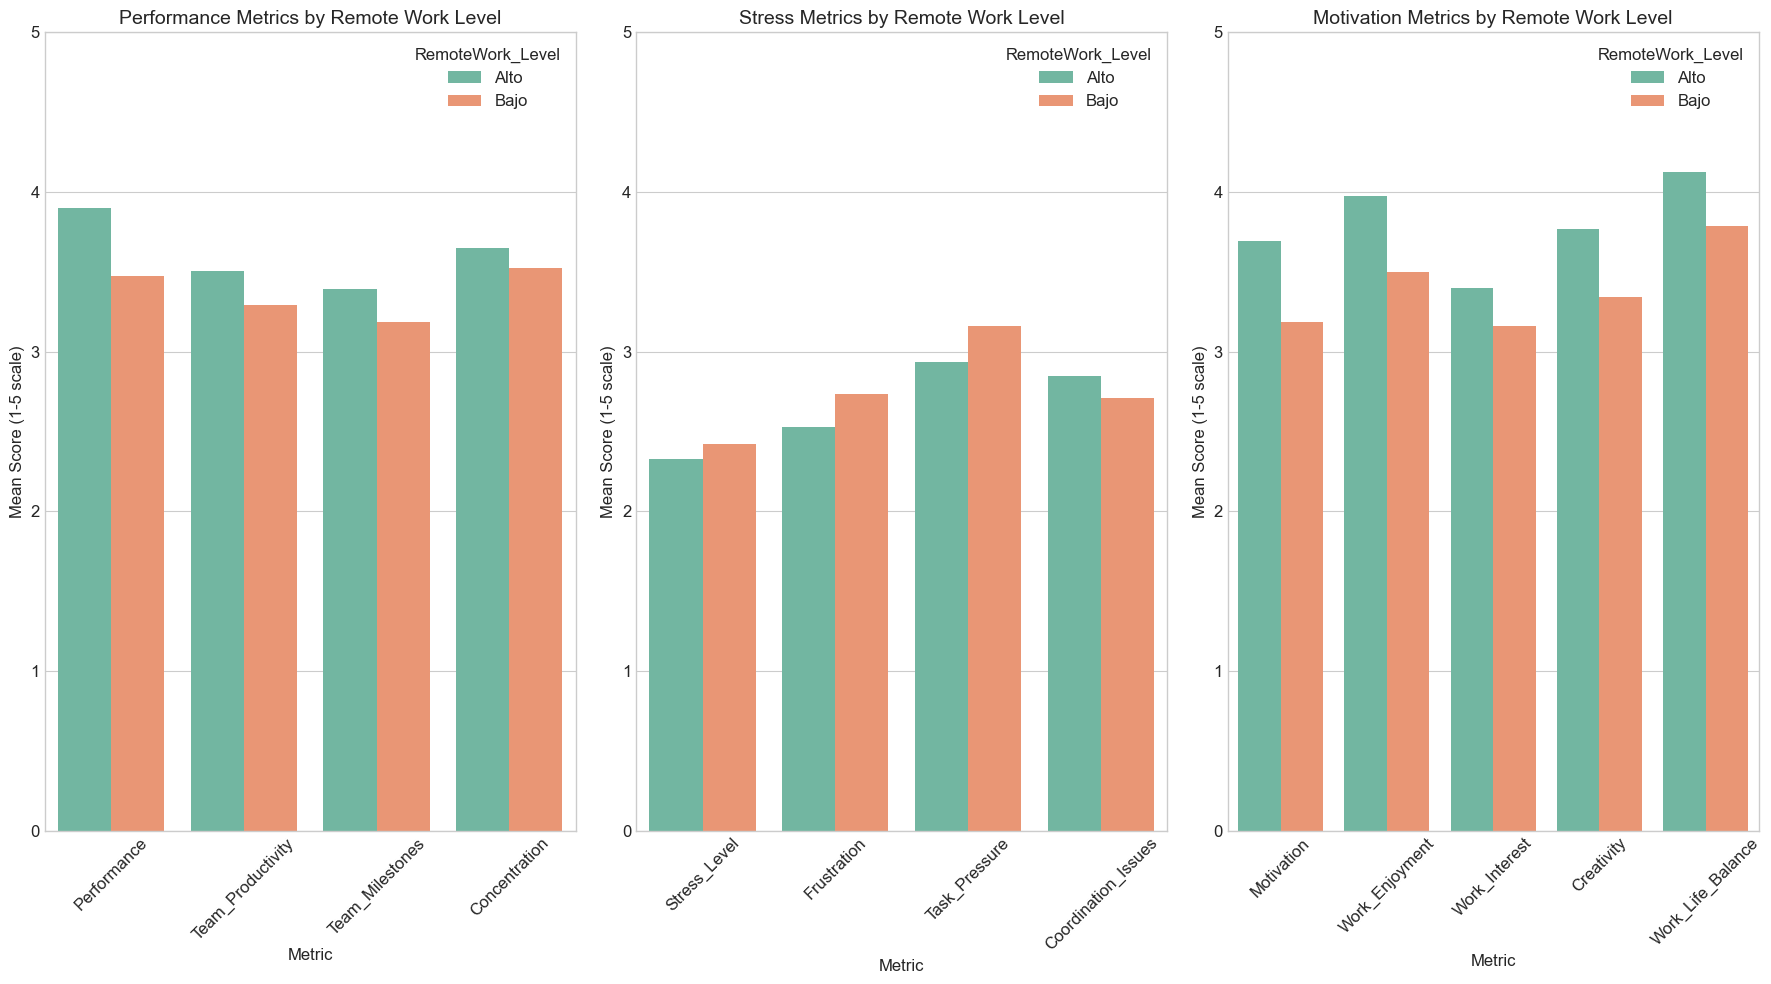


===== STATISTICS BY COUNTRY =====

Performance Metrics by Country:
Country            Argentina  Colombia    España    México
Metric                                                    
Concentration       4.125000  3.603175  3.553571  3.561798
Performance         3.916667  3.920635  3.642857  3.853933
Team_Milestones     3.333333  3.571429  3.357143  3.213483
Team_Productivity   3.625000  3.619048  3.428571  3.348315

Stress Metrics by Country:
Country              Argentina  Colombia    España    México
Metric                                                      
Coordination_Issues   2.500000  2.809524  2.982143  2.820225
Frustration           2.291667  2.571429  2.767857  2.505618
Stress_Level          1.875000  2.301587  2.625000  2.314607
Task_Pressure         3.000000  2.730159  3.125000  3.033708

Motivation Metrics by Country:
Country            Argentina  Colombia    España    México
Metric                                                    
Creativity          3.791667  3.84

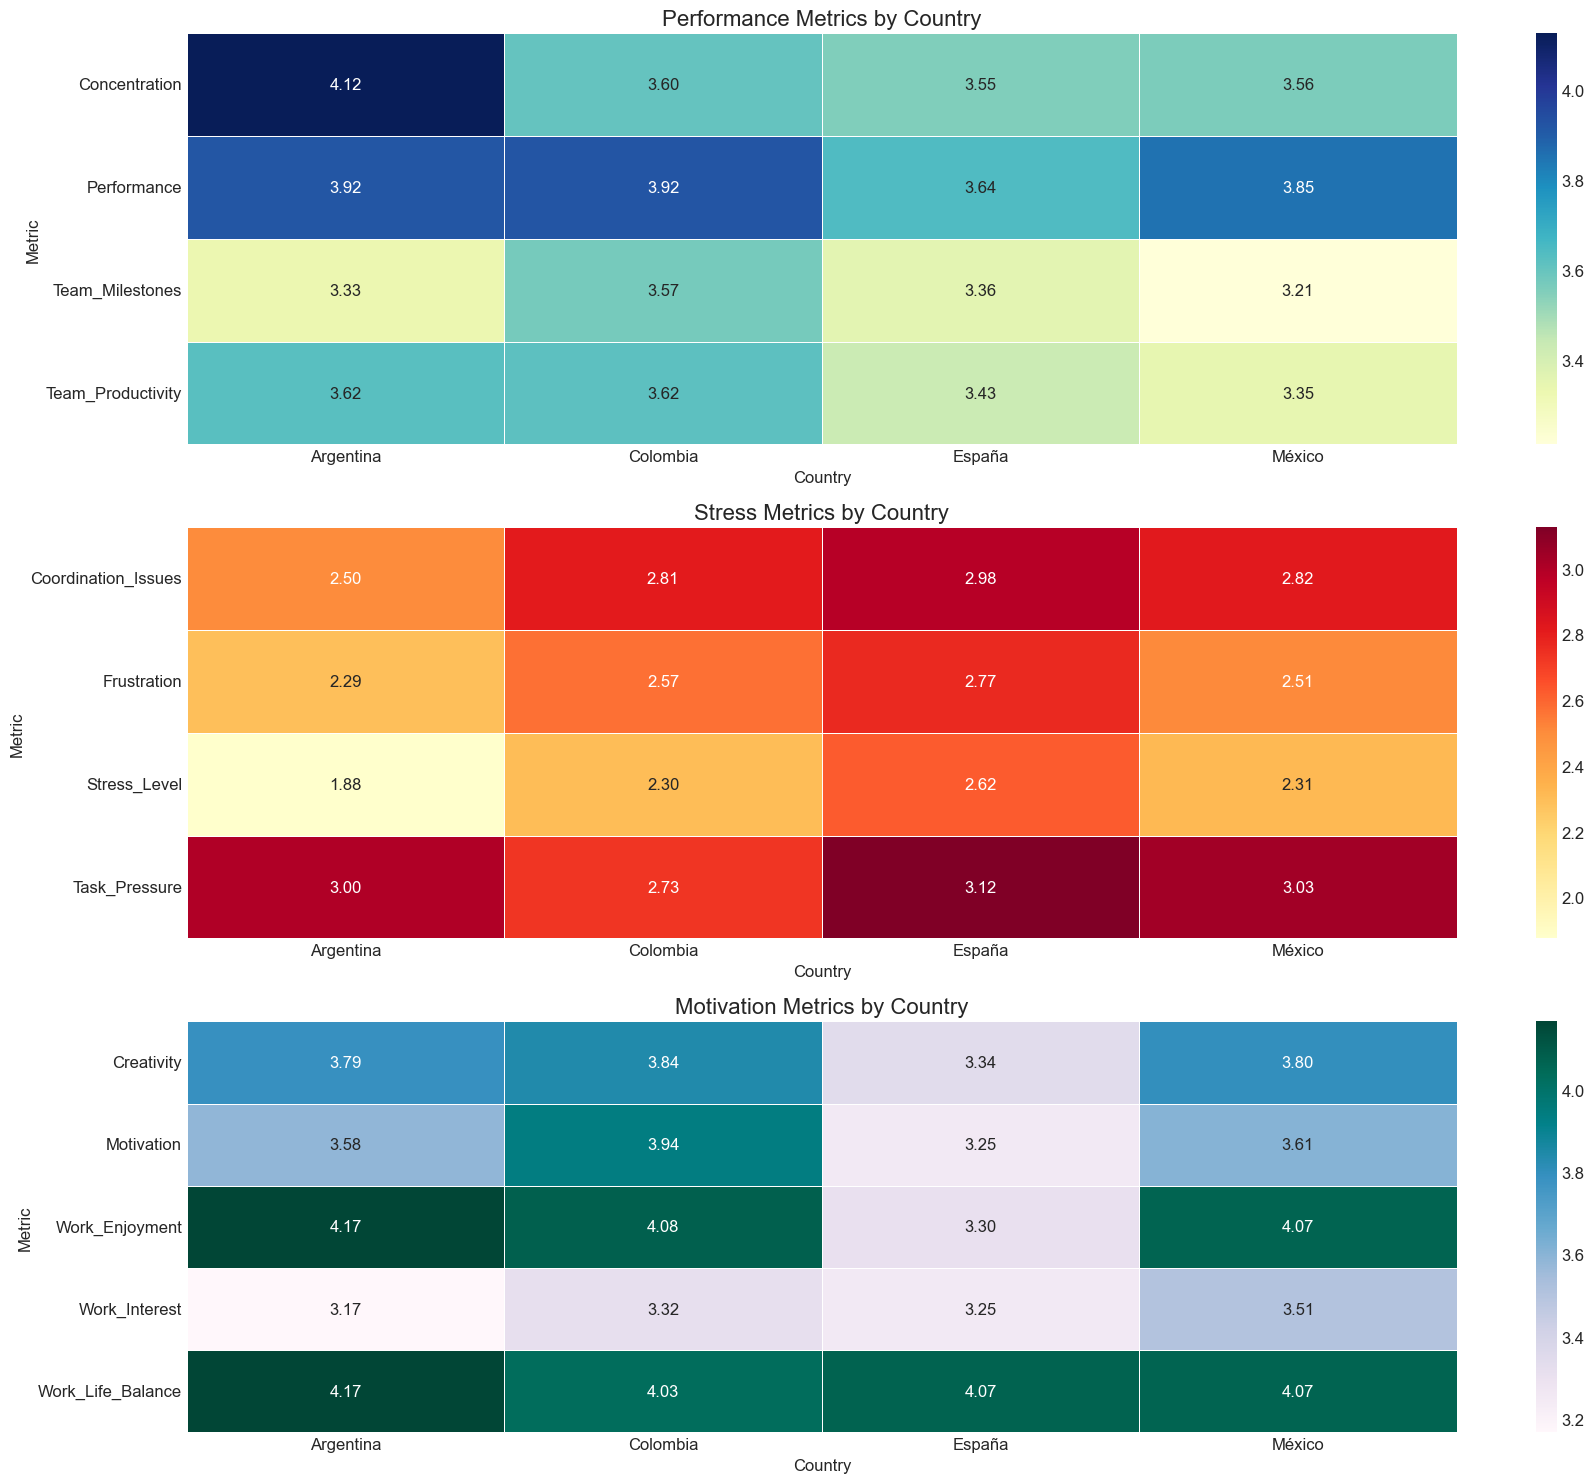


===== STATISTICS BY GENDER =====

Performance Metrics by Gender:
Gender             Femenino  Masculino
Metric                                
Concentration      3.914894   3.548913
Performance        3.829787   3.820652
Team_Milestones    3.255319   3.375000
Team_Productivity  3.574468   3.434783

Stress Metrics by Gender:
Gender               Femenino  Masculino
Metric                                  
Coordination_Issues  2.914894   2.804348
Frustration          2.659574   2.548913
Stress_Level         2.340426   2.347826
Task_Pressure        3.106383   2.940217

Motivation Metrics by Gender:
Gender             Femenino  Masculino
Metric                                
Creativity         3.638298   3.706522
Motivation         3.553191   3.614130
Work_Enjoyment     3.957447   3.875000
Work_Interest      3.340426   3.358696
Work_Life_Balance  4.191489   4.032609


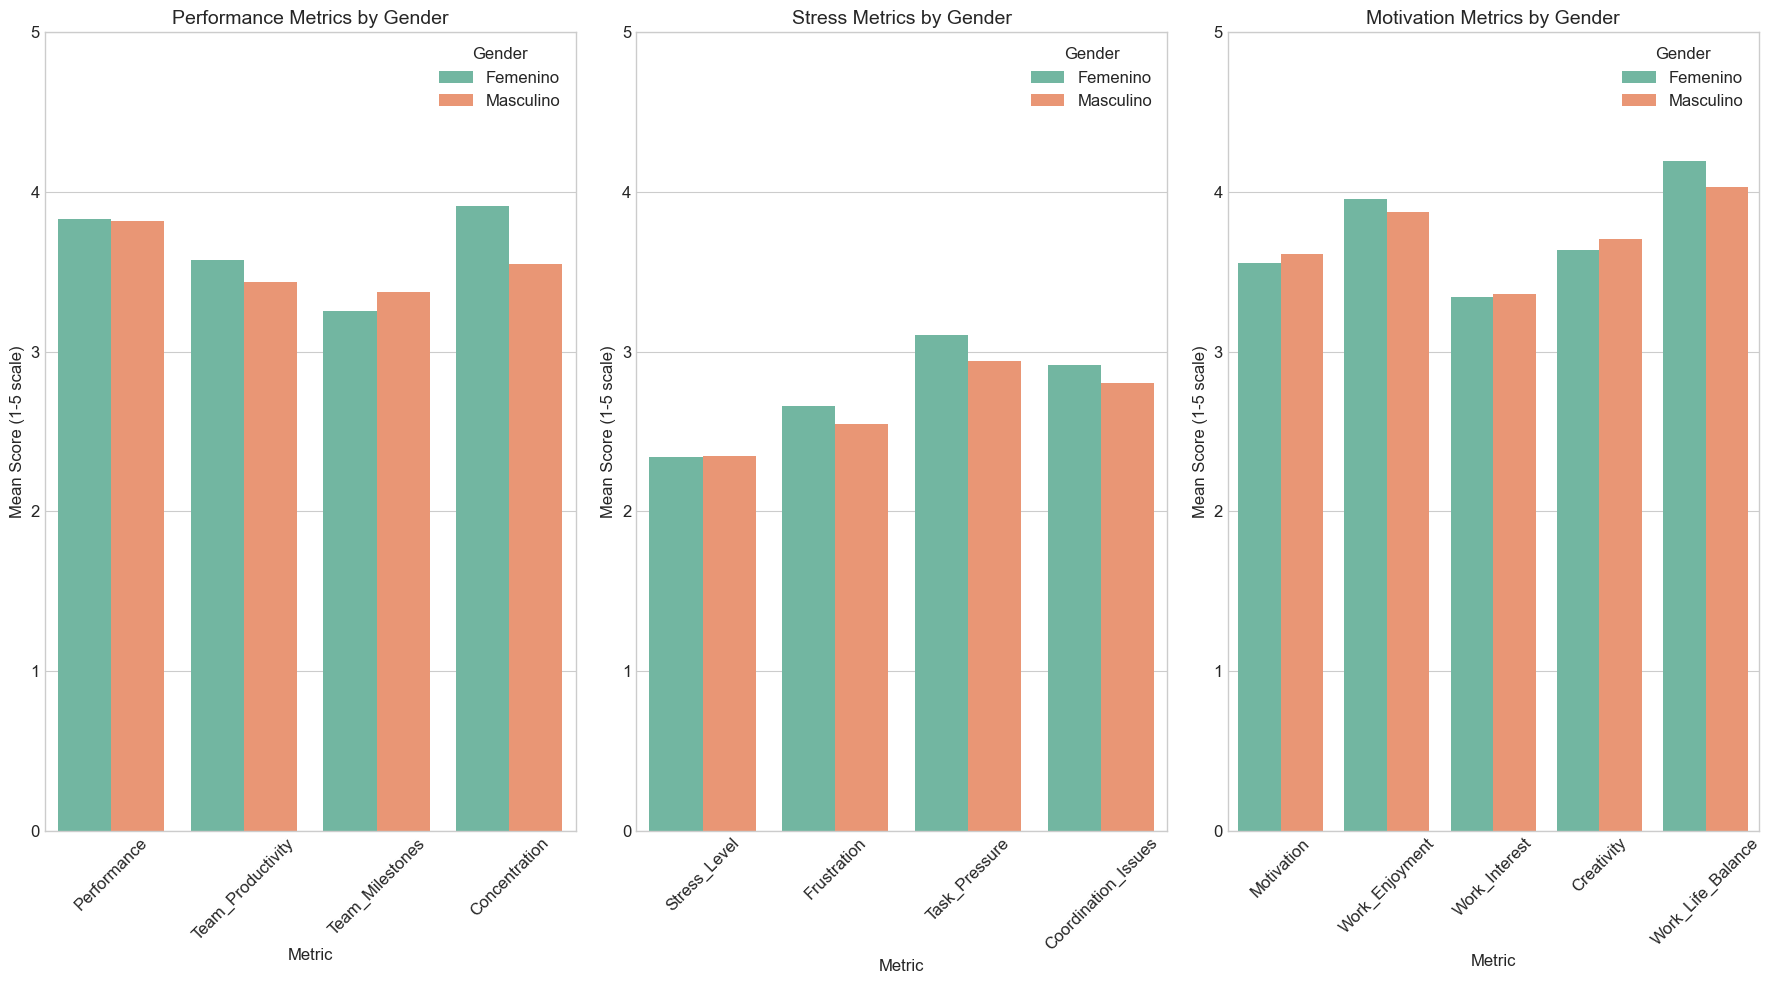


===== STATISTICS BY AGE GROUP =====

Performance Metrics by Age Group:
Age_Range          36+ años  <35 años
Metric                               
Concentration      3.598039  3.653846
Performance        3.941176  3.738462
Team_Milestones    3.352941  3.361538
Team_Productivity  3.558824  3.400000

Stress Metrics by Age Group:
Age_Range            36+ años  <35 años
Metric                                 
Coordination_Issues  2.882353  2.776923
Frustration          2.450980  2.653846
Stress_Level         2.225490  2.430769
Task_Pressure        2.960784  2.976923

Motivation Metrics by Age Group:
Age_Range          36+ años  <35 años
Metric                               
Creativity         3.862745  3.569231
Motivation         3.745098  3.500000
Work_Enjoyment     4.029412  3.792308
Work_Interest      3.558824  3.200000
Work_Life_Balance  4.147059  4.007692


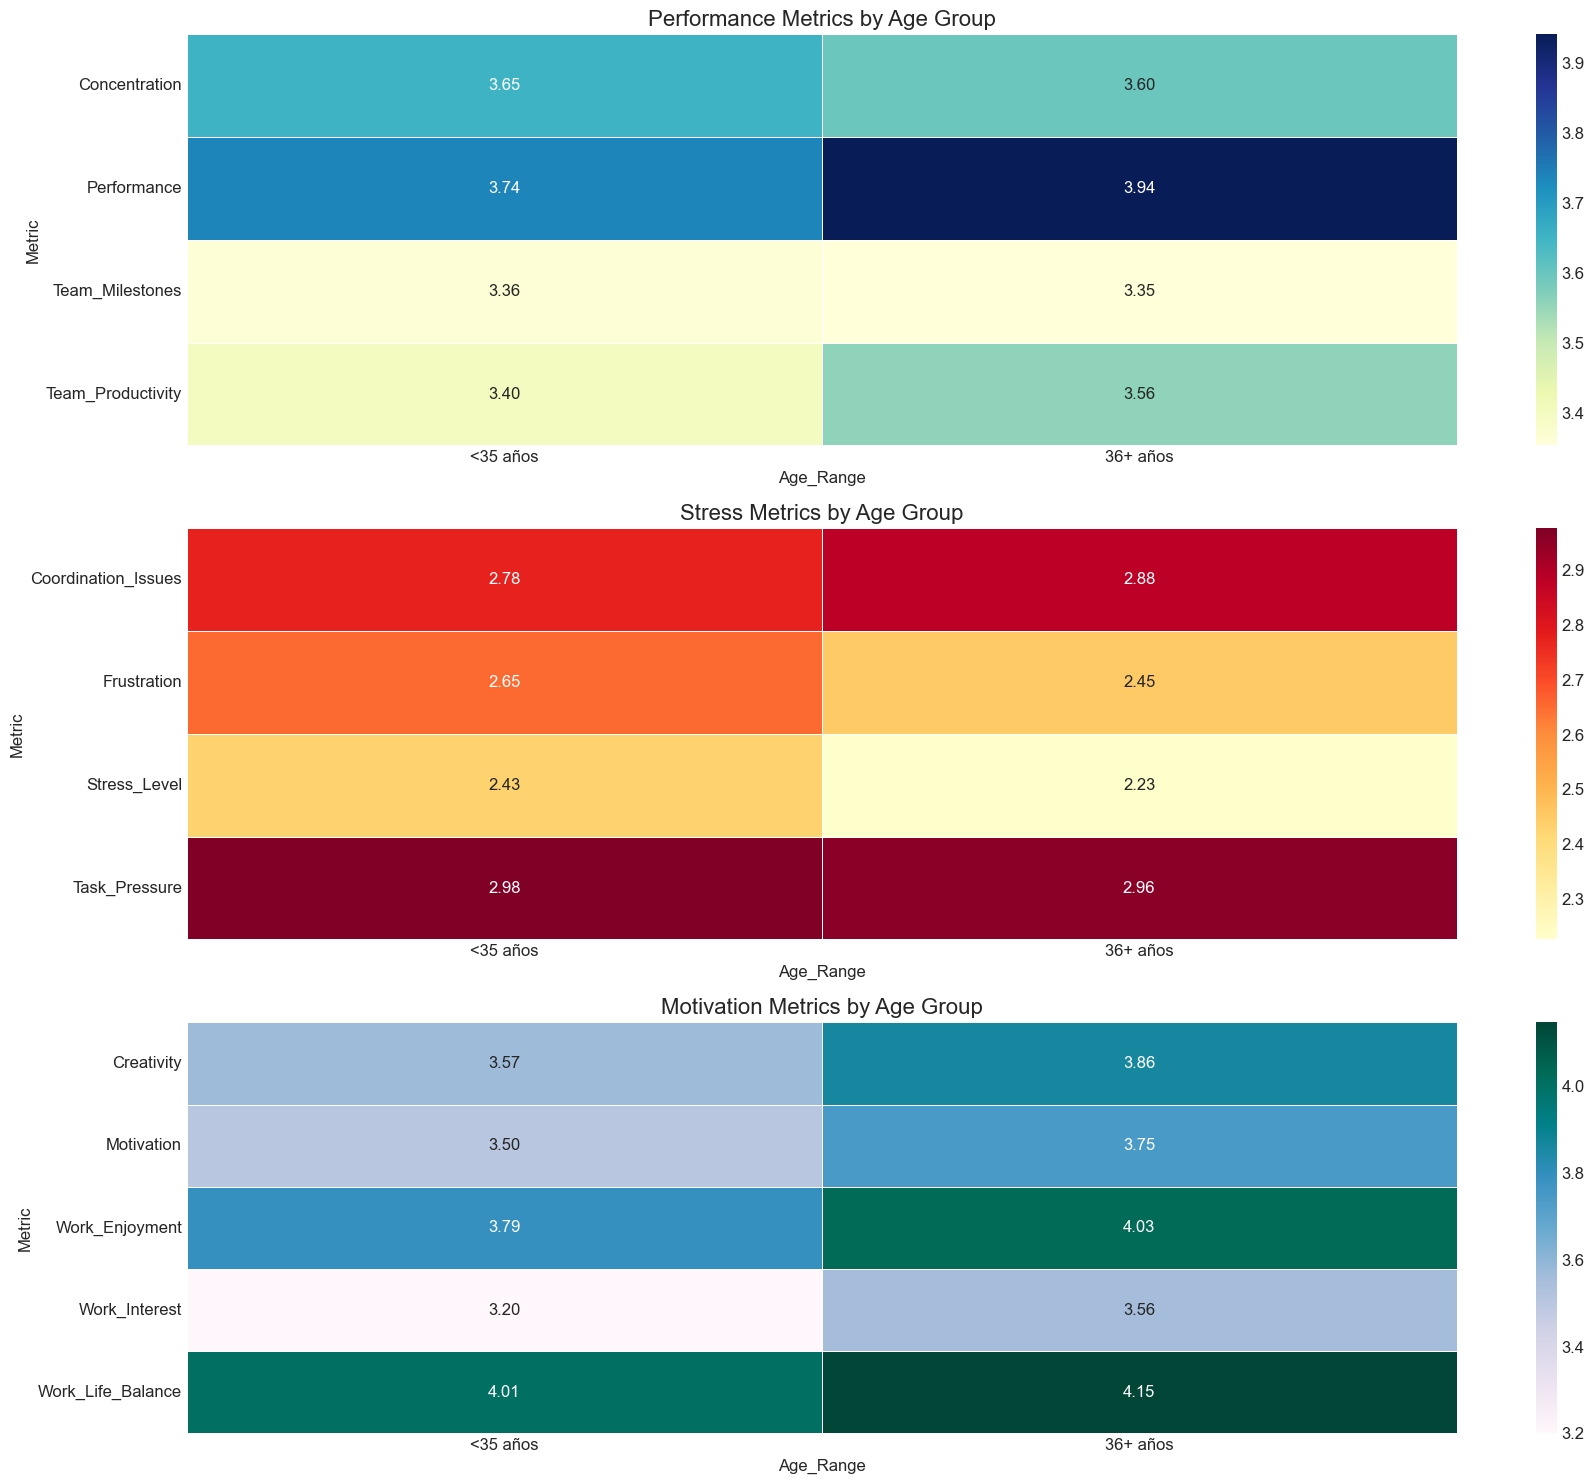


===== INTERACTION BETWEEN REMOTE WORK LEVEL AND OTHER DEMOGRAPHICS =====

Performance Metrics by Country and Remote Work Level:
RemoteWork_Level      Alto      Bajo
Country                             
Argentina         3.944444  3.833333
Colombia          3.932203  3.750000
España            3.794872  3.294118
México            3.910256  3.454545

Performance Metrics by Gender and Remote Work Level:
RemoteWork_Level      Alto      Bajo
Gender                              
Femenino          3.825000  3.857143
Masculino         3.915584  3.333333
No binario             NaN  5.000000


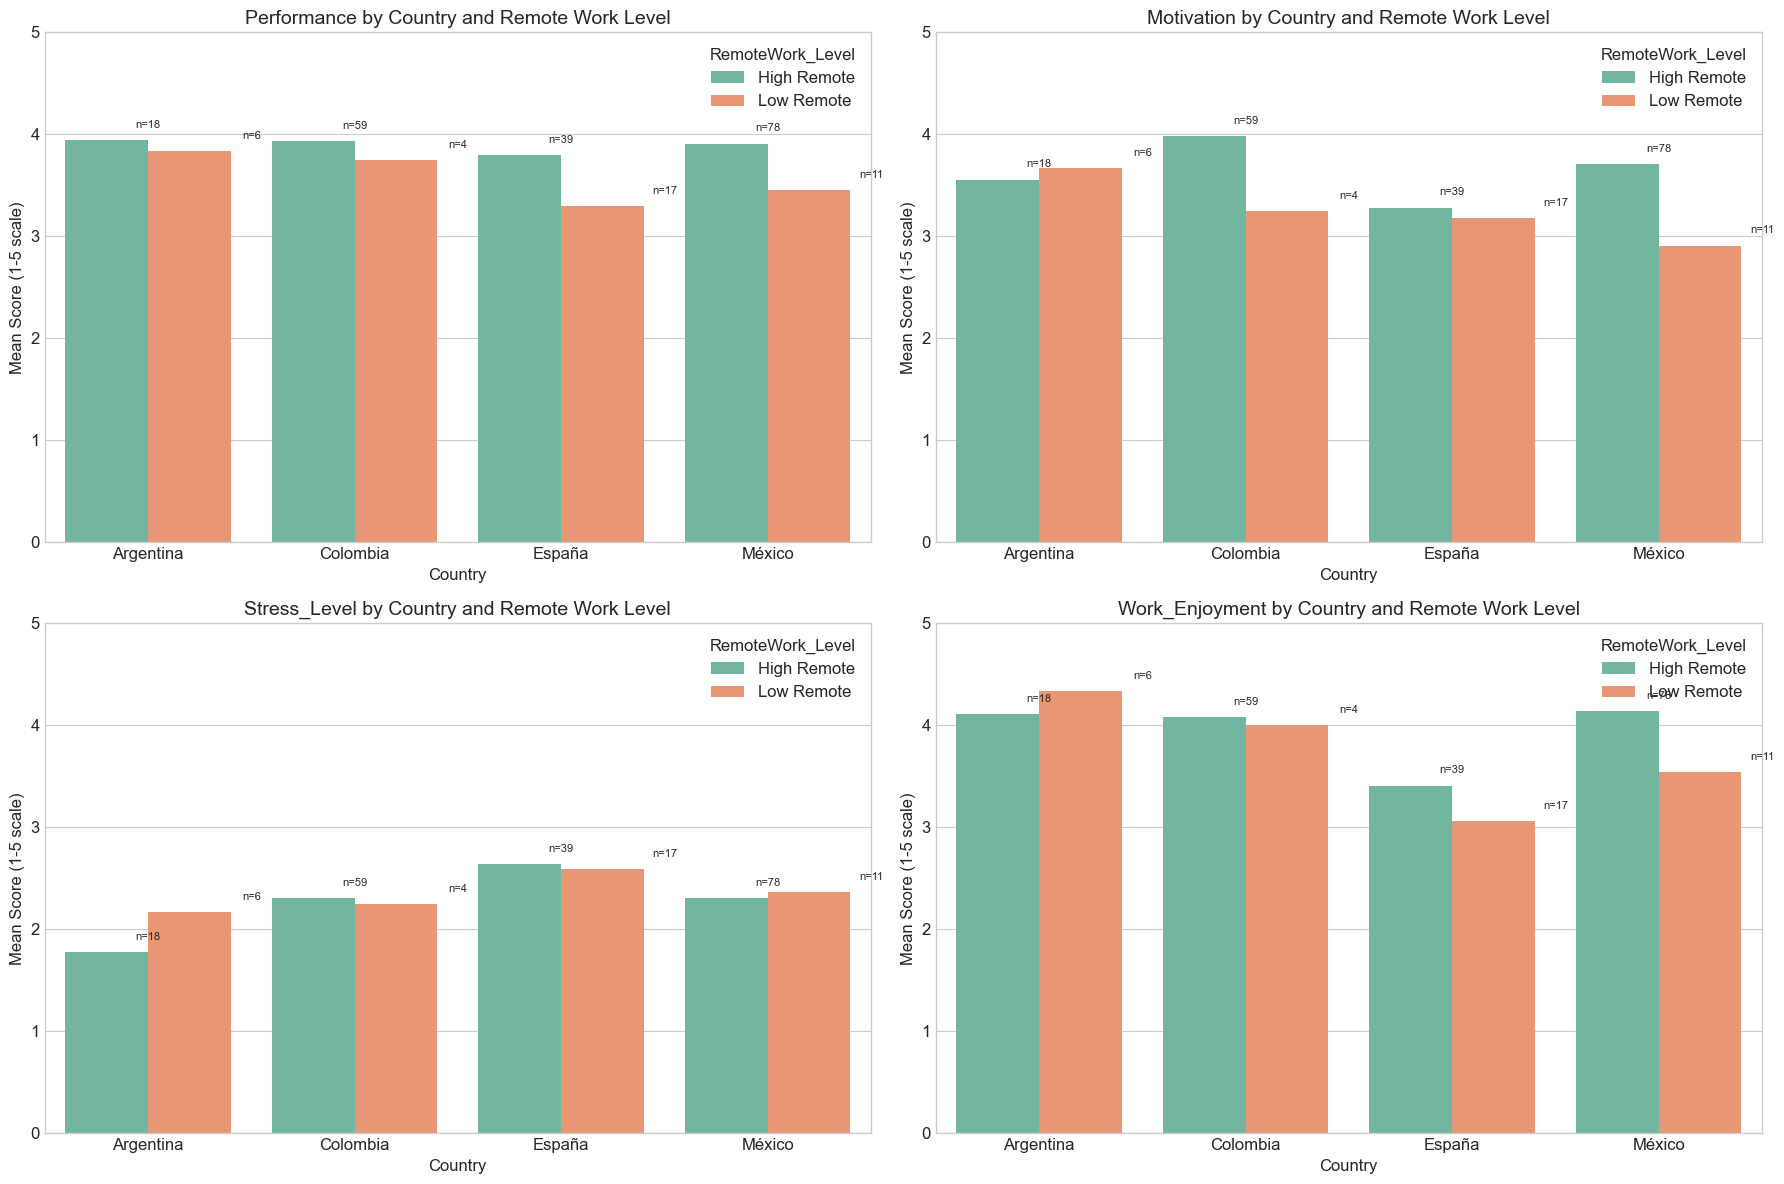

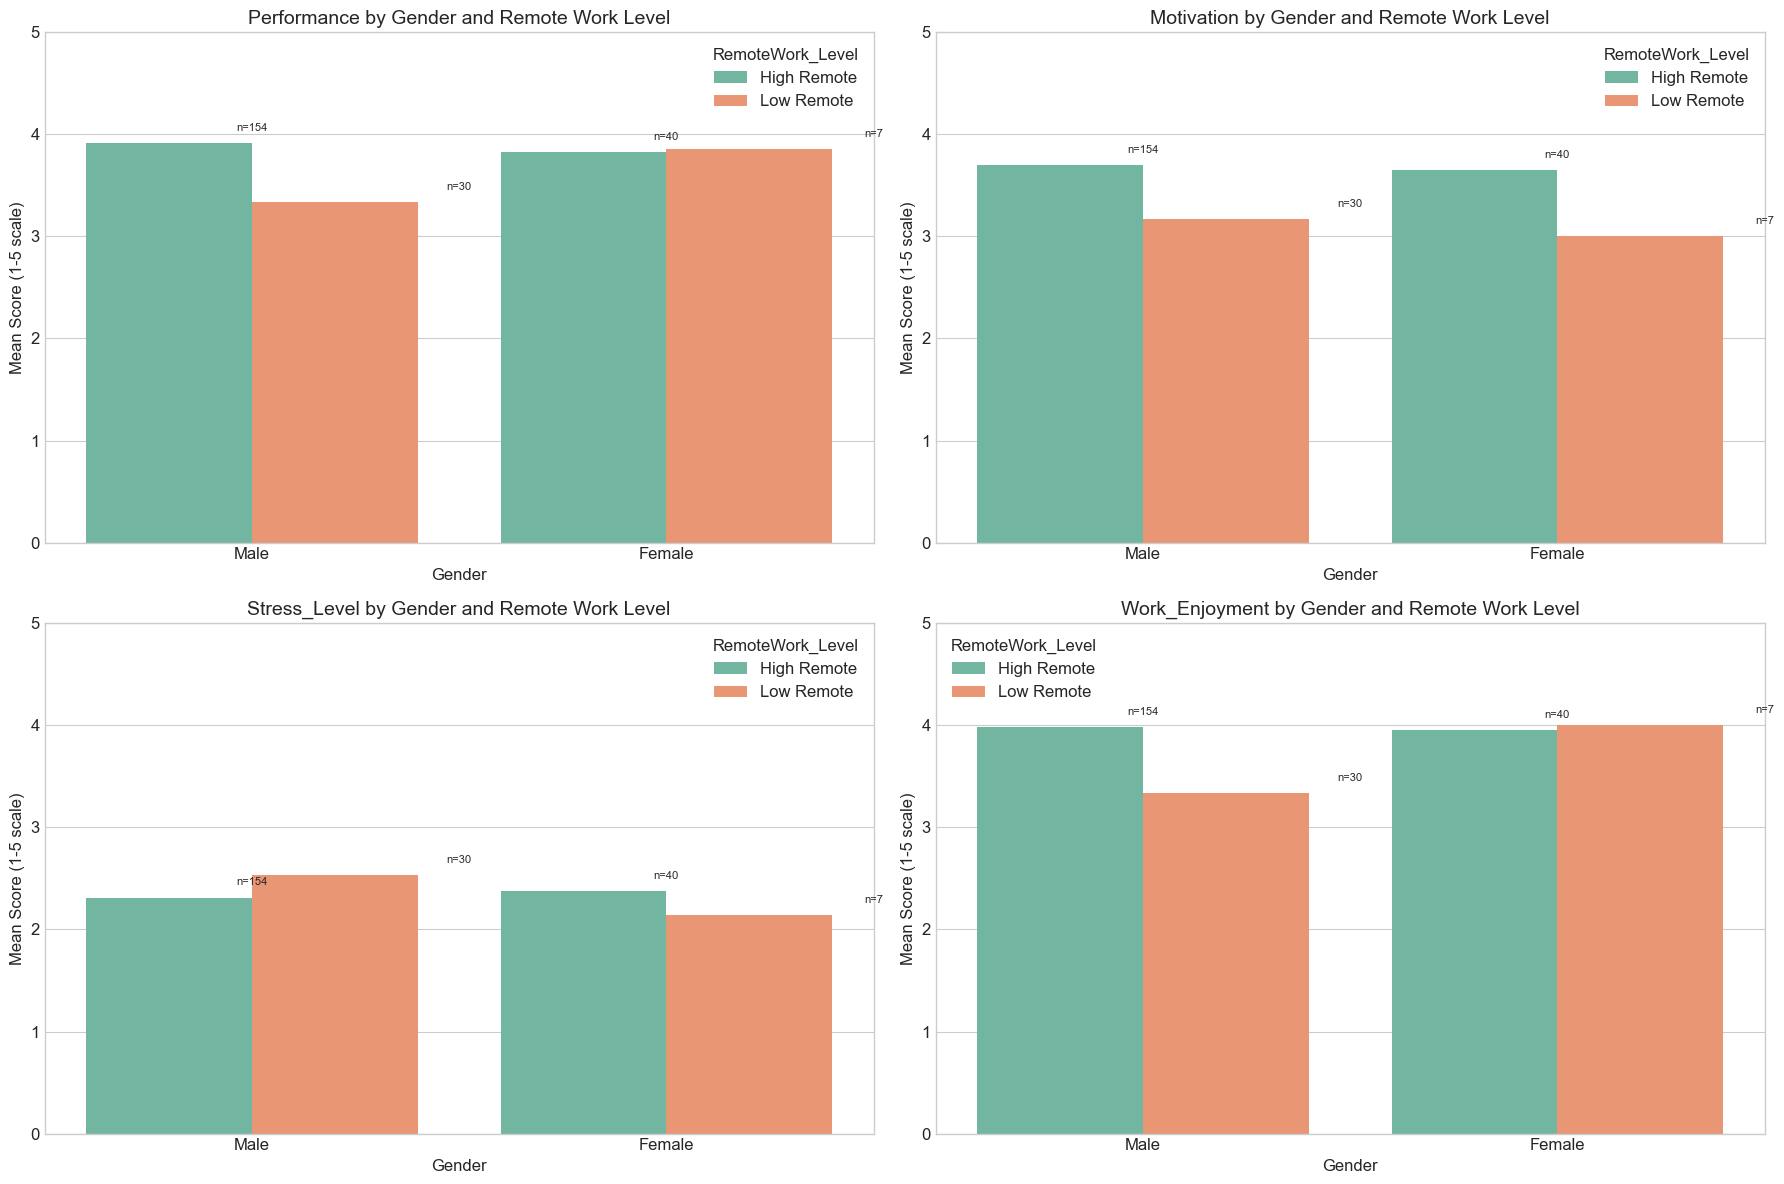

In [ ]:
def calculate_stats_by_group(df: pd.DataFrame, group_col: str, metric_cols: List[str]) -> Dict:
    """
    Calculate statistics (mean, std, count) for each group and metric
    """
    stats_dict = {}
    
    for metric in metric_cols:
        group_stats = df.groupby(group_col)[metric].agg(['mean', 'std', 'count']).reset_index()
        stats_dict[metric] = group_stats
        
    return stats_dict

# %%
# Define key metric groups for analysis
performance_metrics = ['Performance', 'Team_Productivity', 'Team_Milestones', 'Concentration']
stress_metrics = ['Stress_Level', 'Frustration', 'Task_Pressure', 'Coordination_Issues']
motivation_metrics = ['Motivation', 'Work_Enjoyment', 'Work_Interest', 'Creativity', 'Work_Life_Balance']

# Combine all metrics for comprehensive analysis
all_metrics = performance_metrics + stress_metrics + motivation_metrics

# %%
# 3.1 Statistics by Remote Work Level
print("===== STATISTICS BY REMOTE WORK LEVEL =====")

# Calculate statistics for all metrics by Remote Work Level
remote_stats = calculate_stats_by_group(df_clean, 'RemoteWork_Level', all_metrics)

# Create a summary dataframe for visualization
remote_summary = pd.DataFrame()

for metric in all_metrics:
    metric_stats = remote_stats[metric].copy()
    metric_stats['Metric'] = metric
    remote_summary = pd.concat([remote_summary, metric_stats])

# Group metrics by category for better visualization
remote_summary['Category'] = 'Other'
for metric in performance_metrics:
    remote_summary.loc[remote_summary['Metric'] == metric, 'Category'] = 'Performance'
for metric in stress_metrics:
    remote_summary.loc[remote_summary['Metric'] == metric, 'Category'] = 'Stress'
for metric in motivation_metrics:
    remote_summary.loc[remote_summary['Metric'] == metric, 'Category'] = 'Motivation'

# Display performance metrics by remote work level
performance_stats = remote_summary[remote_summary['Category'] == 'Performance']
print("\nPerformance Metrics by Remote Work Level:")
pivot_performance = performance_stats.pivot(index='Metric', columns='RemoteWork_Level', values='mean')
print(pivot_performance)

# show stress metrics by remote work level
stress_stats = remote_summary[remote_summary['Category'] == 'Stress']
print("\nStress Metrics by Remote Work Level:")
pivot_stress = stress_stats.pivot(index='Metric', columns='RemoteWork_Level', values='mean')
print(pivot_stress)

# Show motivation metrics by remote work level
motivation_stats = remote_summary[remote_summary['Category'] == 'Motivation']
print("\nMotivation Metrics by Remote Work Level:")
pivot_motivation = motivation_stats.pivot(index='Metric', columns='RemoteWork_Level', values='mean')
print(pivot_motivation)

# %%
# Visualize metrics by Remote Work Level and category
plt.figure(figsize=(18, 10))

# First category: Performance
plt.subplot(1, 3, 1)
sns.barplot(x='Metric', y='mean', hue='RemoteWork_Level', data=performance_stats)
plt.title('Performance Metrics by Remote Work Level', fontsize=14)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Mean Score (1-5 scale)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 5)

# Second category: Stress
plt.subplot(1, 3, 2)
sns.barplot(x='Metric', y='mean', hue='RemoteWork_Level', data=stress_stats)
plt.title('Stress Metrics by Remote Work Level', fontsize=14)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Mean Score (1-5 scale)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 5)

# Third category: Motivation
plt.subplot(1, 3, 3)
sns.barplot(x='Metric', y='mean', hue='RemoteWork_Level', data=motivation_stats)
plt.title('Motivation Metrics by Remote Work Level', fontsize=14)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Mean Score (1-5 scale)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

# %%
# 3.2 Statistics by Country
print("\n===== STATISTICS BY COUNTRY =====")

# Calculate statistics for all metrics by Country
country_stats = calculate_stats_by_group(df_clean, 'Country', all_metrics)

# Create a summary dataframe for visualization
country_summary = pd.DataFrame()

for metric in all_metrics:
    metric_stats = country_stats[metric].copy()
    metric_stats['Metric'] = metric
    country_summary = pd.concat([country_summary, metric_stats])

# Group metrics by category
country_summary['Category'] = 'Other'
for metric in performance_metrics:
    country_summary.loc[country_summary['Metric'] == metric, 'Category'] = 'Performance'
for metric in stress_metrics:
    country_summary.loc[country_summary['Metric'] == metric, 'Category'] = 'Stress'
for metric in motivation_metrics:
    country_summary.loc[country_summary['Metric'] == metric, 'Category'] = 'Motivation'

# Display performance metrics by country
performance_country = country_summary[country_summary['Category'] == 'Performance']
print("\nPerformance Metrics by Country:")
pivot_perf_country = performance_country.pivot(index='Metric', columns='Country', values='mean')
print(pivot_perf_country)

# Display stress metrics by country
stress_country = country_summary[country_summary['Category'] == 'Stress']
print("\nStress Metrics by Country:")
pivot_stress_country = stress_country.pivot(index='Metric', columns='Country', values='mean')
print(pivot_stress_country)

# Display motivation metrics by country
motivation_country = country_summary[country_summary['Category'] == 'Motivation']
print("\nMotivation Metrics by Country:")
pivot_motivation_country = motivation_country.pivot(index='Metric', columns='Country', values='mean')
print(pivot_motivation_country)

# %%
# Visualize metrics by Country using heatmaps (better for multiple groups)
plt.figure(figsize=(18, 15))

# For Performance metrics
plt.subplot(3, 1, 1)
perf_pivot = performance_country.pivot(index='Metric', columns='Country', values='mean')
sns.heatmap(perf_pivot, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5)
plt.title('Performance Metrics by Country', fontsize=16)

# For Stress metrics
plt.subplot(3, 1, 2)
stress_pivot = stress_country.pivot(index='Metric', columns='Country', values='mean')
sns.heatmap(stress_pivot, annot=True, cmap='YlOrRd', fmt='.2f', linewidths=.5)
plt.title('Stress Metrics by Country', fontsize=16)

# For Motivation metrics
plt.subplot(3, 1, 3)
motiv_pivot = motivation_country.pivot(index='Metric', columns='Country', values='mean')
sns.heatmap(motiv_pivot, annot=True, cmap='PuBuGn', fmt='.2f', linewidths=.5)
plt.title('Motivation Metrics by Country', fontsize=16)

plt.tight_layout()
plt.show()

# %%
# 3.3 Statistics by Gender
print("\n===== STATISTICS BY GENDER =====")

# Calculate statistics for all metrics by Gender
gender_stats = calculate_stats_by_group(df_clean, 'Gender', all_metrics)

# Create a summary dataframe for visualization
gender_summary = pd.DataFrame()

for metric in all_metrics:
    metric_stats = gender_stats[metric].copy()
    metric_stats['Metric'] = metric
    gender_summary = pd.concat([gender_summary, metric_stats])

# Group metrics by category
gender_summary['Category'] = 'Other'
for metric in performance_metrics:
    gender_summary.loc[gender_summary['Metric'] == metric, 'Category'] = 'Performance'
for metric in stress_metrics:
    gender_summary.loc[gender_summary['Metric'] == metric, 'Category'] = 'Stress'
for metric in motivation_metrics:
    gender_summary.loc[gender_summary['Metric'] == metric, 'Category'] = 'Motivation'

# Display metrics by gender, filtering out 'No binario' if sample size is too small
gender_summary_filtered = gender_summary[gender_summary['Gender'] != 'No binario'] if len(df_clean[df_clean['Gender'] == 'No binario']) < 5 else gender_summary

# Display performance metrics by gender
performance_gender = gender_summary_filtered[gender_summary_filtered['Category'] == 'Performance']
print("\nPerformance Metrics by Gender:")
pivot_perf_gender = performance_gender.pivot(index='Metric', columns='Gender', values='mean')
print(pivot_perf_gender)

# Display stress metrics by gender
stress_gender = gender_summary_filtered[gender_summary_filtered['Category'] == 'Stress']
print("\nStress Metrics by Gender:")
pivot_stress_gender = stress_gender.pivot(index='Metric', columns='Gender', values='mean')
print(pivot_stress_gender)

# Display motivation metrics by gender
motivation_gender = gender_summary_filtered[gender_summary_filtered['Category'] == 'Motivation']
print("\nMotivation Metrics by Gender:")
pivot_motivation_gender = motivation_gender.pivot(index='Metric', columns='Gender', values='mean')
print(pivot_motivation_gender)

# %%
# Visualize metrics by Gender
plt.figure(figsize=(18, 10))

# For Performance metrics
plt.subplot(1, 3, 1)
sns.barplot(x='Metric', y='mean', hue='Gender', data=performance_gender)
plt.title('Performance Metrics by Gender', fontsize=14)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Mean Score (1-5 scale)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 5)

# For Stress metrics
plt.subplot(1, 3, 2)
sns.barplot(x='Metric', y='mean', hue='Gender', data=stress_gender)
plt.title('Stress Metrics by Gender', fontsize=14)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Mean Score (1-5 scale)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 5)

# For Motivation metrics
plt.subplot(1, 3, 3)
sns.barplot(x='Metric', y='mean', hue='Gender', data=motivation_gender)
plt.title('Motivation Metrics by Gender', fontsize=14)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Mean Score (1-5 scale)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

# %%
# 3.4 Statistics by Age Group
print("\n===== STATISTICS BY AGE GROUP =====")

# Calculate statistics for all metrics by Age Group
age_stats = calculate_stats_by_group(df_clean, 'Age_Range', all_metrics)

# Create a summary dataframe for visualization
age_summary = pd.DataFrame()

for metric in all_metrics:
    metric_stats = age_stats[metric].copy()
    metric_stats['Metric'] = metric
    age_summary = pd.concat([age_summary, metric_stats])

# Group metrics by category
age_summary['Category'] = 'Other'
for metric in performance_metrics:
    age_summary.loc[age_summary['Metric'] == metric, 'Category'] = 'Performance'
for metric in stress_metrics:
    age_summary.loc[age_summary['Metric'] == metric, 'Category'] = 'Stress'
for metric in motivation_metrics:
    age_summary.loc[age_summary['Metric'] == metric, 'Category'] = 'Motivation'

# Display performance metrics by age
performance_age = age_summary[age_summary['Category'] == 'Performance']
print("\nPerformance Metrics by Age Group:")
pivot_perf_age = performance_age.pivot(index='Metric', columns='Age_Range', values='mean')
print(pivot_perf_age)

# Display stress metrics by age
stress_age = age_summary[age_summary['Category'] == 'Stress']
print("\nStress Metrics by Age Group:")
pivot_stress_age = stress_age.pivot(index='Metric', columns='Age_Range', values='mean')
print(pivot_stress_age)

# Display motivation metrics by age
motivation_age = age_summary[age_summary['Category'] == 'Motivation']
print("\nMotivation Metrics by Age Group:")
pivot_motivation_age = motivation_age.pivot(index='Metric', columns='Age_Range', values='mean')
print(pivot_motivation_age)

# %%
# Visualize metrics by Age Group using heatmaps (better for multiple groups)
plt.figure(figsize=(18, 15))

# For Performance metrics
plt.subplot(3, 1, 1)
perf_pivot_age = performance_age.pivot(index='Metric', columns='Age_Range', values='mean')
# Sort age groups for better visualization
age_order = ['<35 años', '36+ años']
perf_pivot_age = perf_pivot_age.reindex(columns=age_order)
sns.heatmap(perf_pivot_age, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5)
plt.title('Performance Metrics by Age Group', fontsize=16)

# For Stress metrics
plt.subplot(3, 1, 2)
stress_pivot_age = stress_age.pivot(index='Metric', columns='Age_Range', values='mean')
stress_pivot_age = stress_pivot_age.reindex(columns=age_order)
sns.heatmap(stress_pivot_age, annot=True, cmap='YlOrRd', fmt='.2f', linewidths=.5)
plt.title('Stress Metrics by Age Group', fontsize=16)

# For Motivation metrics
plt.subplot(3, 1, 3)
motiv_pivot_age = motivation_age.pivot(index='Metric', columns='Age_Range', values='mean')
motiv_pivot_age = motiv_pivot_age.reindex(columns=age_order)
sns.heatmap(motiv_pivot_age, annot=True, cmap='PuBuGn', fmt='.2f', linewidths=.5)
plt.title('Motivation Metrics by Age Group', fontsize=16)

plt.tight_layout()
plt.show()

# %%
# 3.5 Combining Remote Work Level with other demographics
print("\n===== INTERACTION BETWEEN REMOTE WORK LEVEL AND OTHER DEMOGRAPHICS =====")

# For country × remote work interaction
print("\nPerformance Metrics by Country and Remote Work Level:")
interaction_country = df_clean.groupby(['Country', 'RemoteWork_Level'])['Performance'].mean().unstack()
print(interaction_country)

# For gender × remote work interaction
print("\nPerformance Metrics by Gender and Remote Work Level:")
interaction_gender = df_clean.groupby(['Gender', 'RemoteWork_Level'])['Performance'].mean().unstack()
print(interaction_gender)

# %%
# Visualize country × remote work interaction for key metrics
interaction_metrics = ['Performance', 'Motivation', 'Stress_Level', 'Work_Enjoyment']

plt.figure(figsize=(18, 12))

for i, metric in enumerate(interaction_metrics):
    plt.subplot(2, 2, i+1)
    
    # Calculate means for each country and remote work level combination
    interaction_data = []
    for country in df_clean['Country'].unique():
        for remote_level in ['Alto', 'Bajo']:
            filtered_df = df_clean[(df_clean['Country'] == country) & 
                                 (df_clean['RemoteWork_Level'] == remote_level)]
            
            if len(filtered_df) > 0:
                interaction_data.append({
                    'Country': country,
                    'RemoteWork_Level': 'High Remote' if remote_level == 'Alto' else 'Low Remote',
                    'Value': filtered_df[metric].mean(),
                    'Count': len(filtered_df)
                })
    
    interaction_df = pd.DataFrame(interaction_data)
    
    # Create the interaction plot
    sns.barplot(x='Country', y='Value', hue='RemoteWork_Level', data=interaction_df)
    plt.title(f'{metric} by Country and Remote Work Level', fontsize=14)
    plt.xlabel('Country', fontsize=12)
    plt.ylabel('Mean Score (1-5 scale)', fontsize=12)
    plt.ylim(0, 5)
    
    # Add sample size labels
    for j, row in enumerate(interaction_df.itertuples()):
        plt.text(j/2, row.Value + 0.1, f'n={row.Count}', 
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# %%
# Visualize gender × remote work interaction for key metrics
plt.figure(figsize=(18, 12))

for i, metric in enumerate(interaction_metrics):
    plt.subplot(2, 2, i+1)
    
    # Calculate means for each gender and remote work level combination
    interaction_data = []
    for gender in ['Masculino', 'Femenino']:  # Exclude No binario due to small sample size
        for remote_level in ['Alto', 'Bajo']:
            filtered_df = df_clean[(df_clean['Gender'] == gender) & 
                                 (df_clean['RemoteWork_Level'] == remote_level)]
            
            if len(filtered_df) > 0:
                interaction_data.append({
                    'Gender': 'Male' if gender == 'Masculino' else 'Female',
                    'RemoteWork_Level': 'High Remote' if remote_level == 'Alto' else 'Low Remote',
                    'Value': filtered_df[metric].mean(),
                    'Count': len(filtered_df)
                })
    
    interaction_df = pd.DataFrame(interaction_data)
    
    # Create the interaction plot
    sns.barplot(x='Gender', y='Value', hue='RemoteWork_Level', data=interaction_df)
    plt.title(f'{metric} by Gender and Remote Work Level', fontsize=14)
    plt.xlabel('Gender', fontsize=12)
    plt.ylabel('Mean Score (1-5 scale)', fontsize=12)
    plt.ylim(0, 5)
    
    # Add sample size labels
    for j, row in enumerate(interaction_df.itertuples()):
        plt.text(j/2, row.Value + 0.1, f'n={row.Count}', 
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

#Section 4: Visaluzation

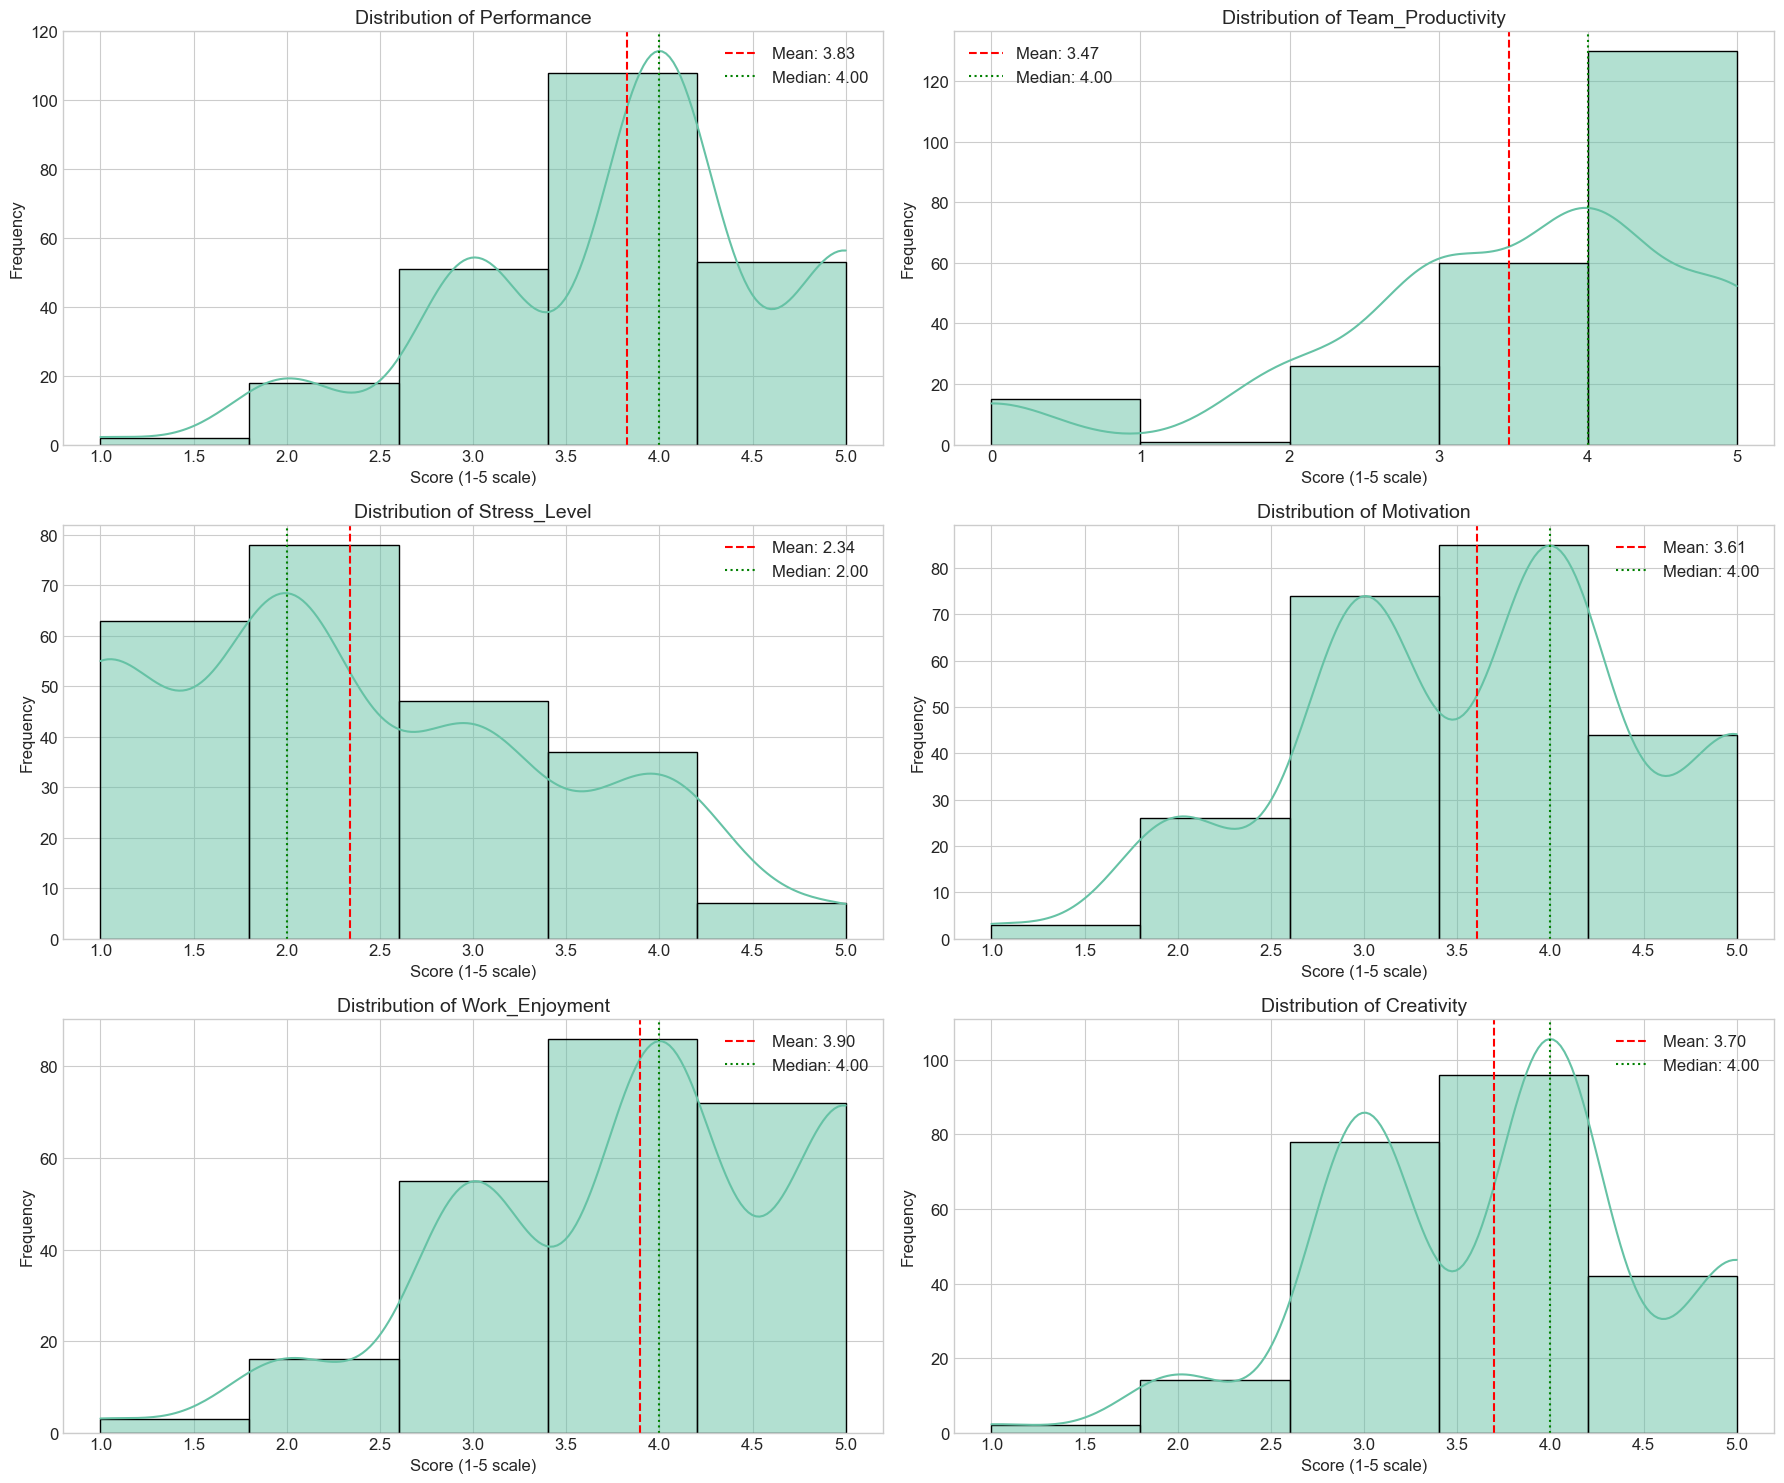

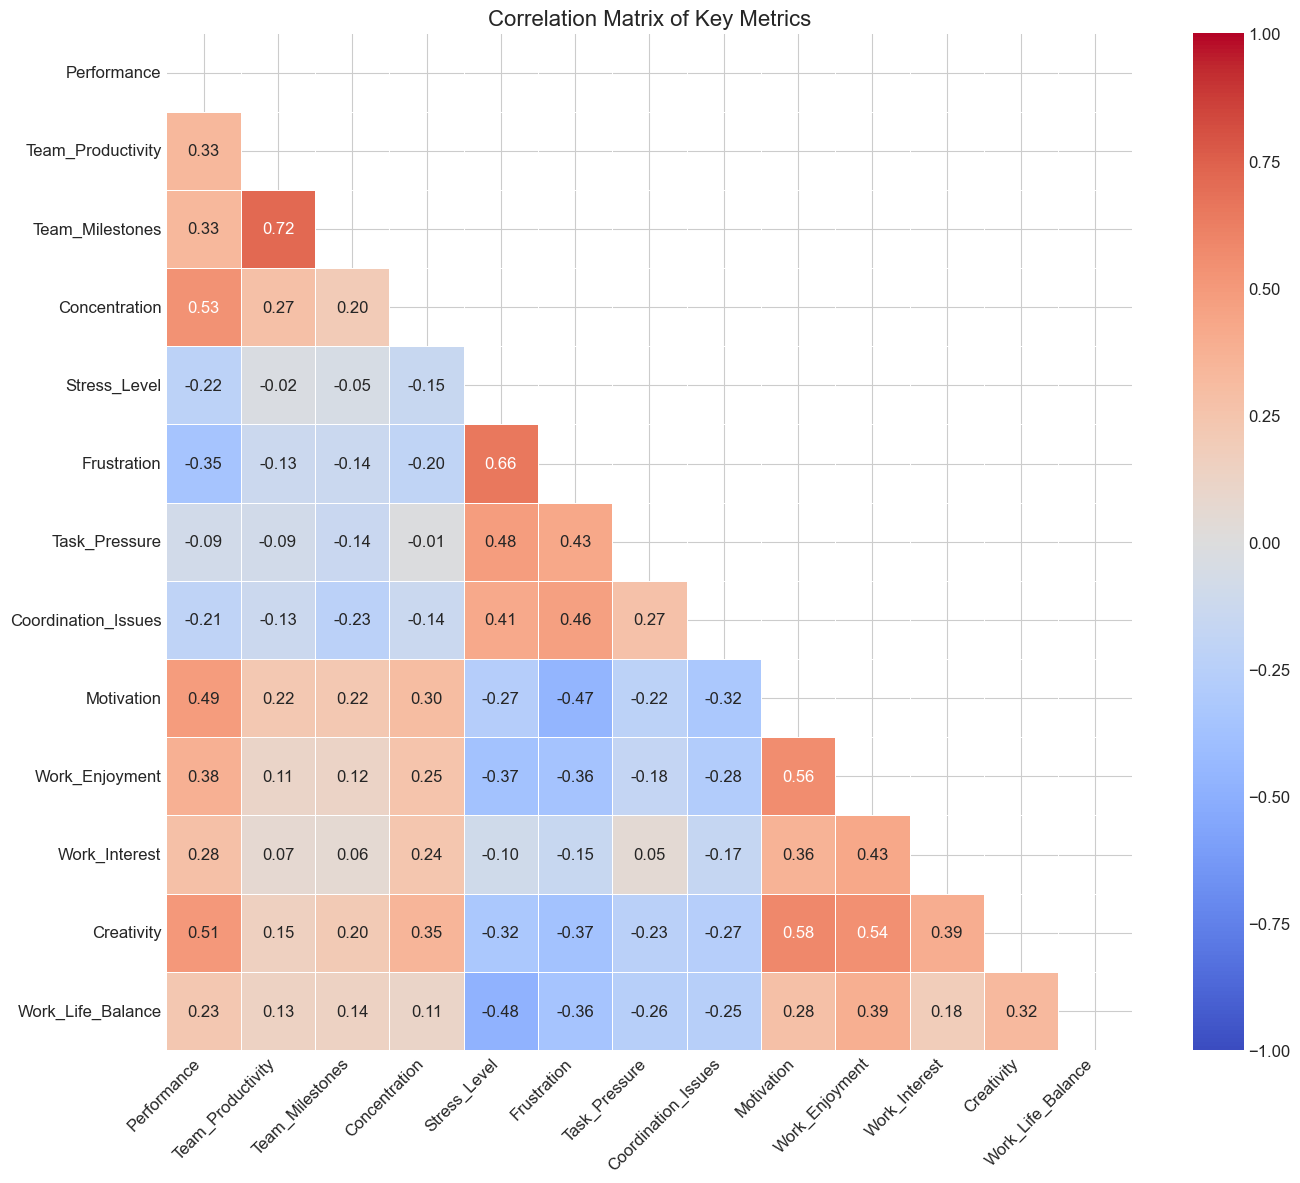

C:\Users\Camilo Daza\AppData\Local\Temp\ipykernel_22592\2641982612.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RemoteWork_Level', y=metric, data=df_clean, palette=remote_palette)
C:\Users\Camilo Daza\AppData\Local\Temp\ipykernel_22592\2641982612.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RemoteWork_Level', y=metric, data=df_clean, palette=remote_palette)
C:\Users\Camilo Daza\AppData\Local\Temp\ipykernel_22592\2641982612.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RemoteWork_Level', y=metric, data=df_clean

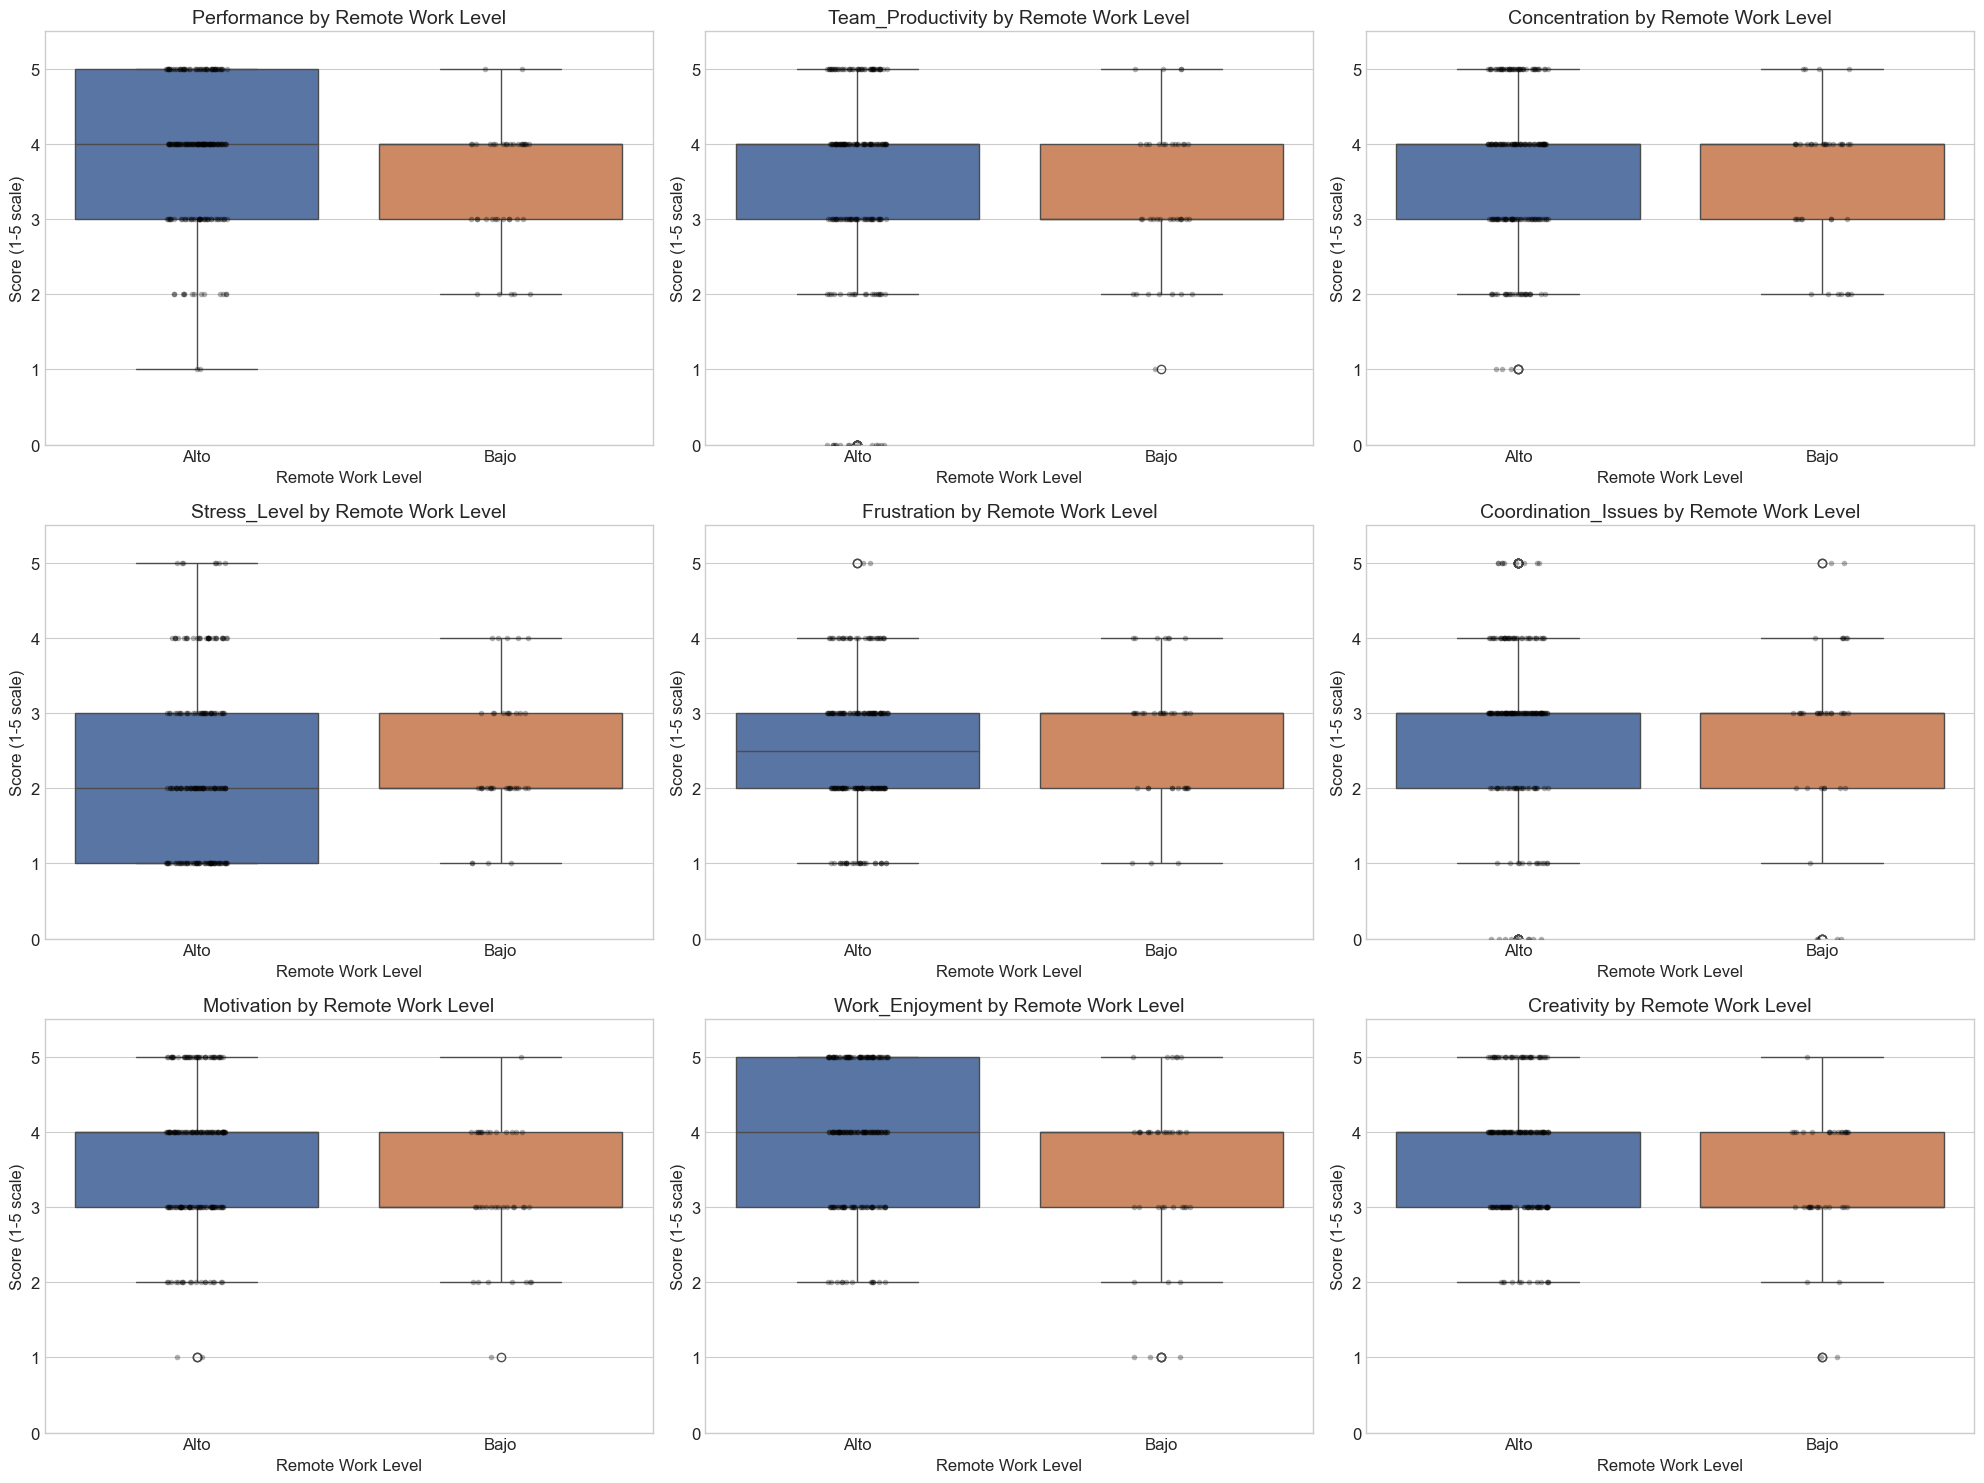

C:\Users\Camilo Daza\AppData\Local\Temp\ipykernel_22592\2641982612.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=metric, data=gender_df, palette=gender_palette)
c:\Users\Camilo Daza\OneDrive - Universidad de los andes\2. Universidad Sistemas Full\Semestre 4 ISIS\1. Tesis\03. Wip\Analysis\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 39.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Camilo Daza\AppData\Local\Temp\ipykernel_22592\2641982612.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=metric, data=gender_df, palette=gender_palette)

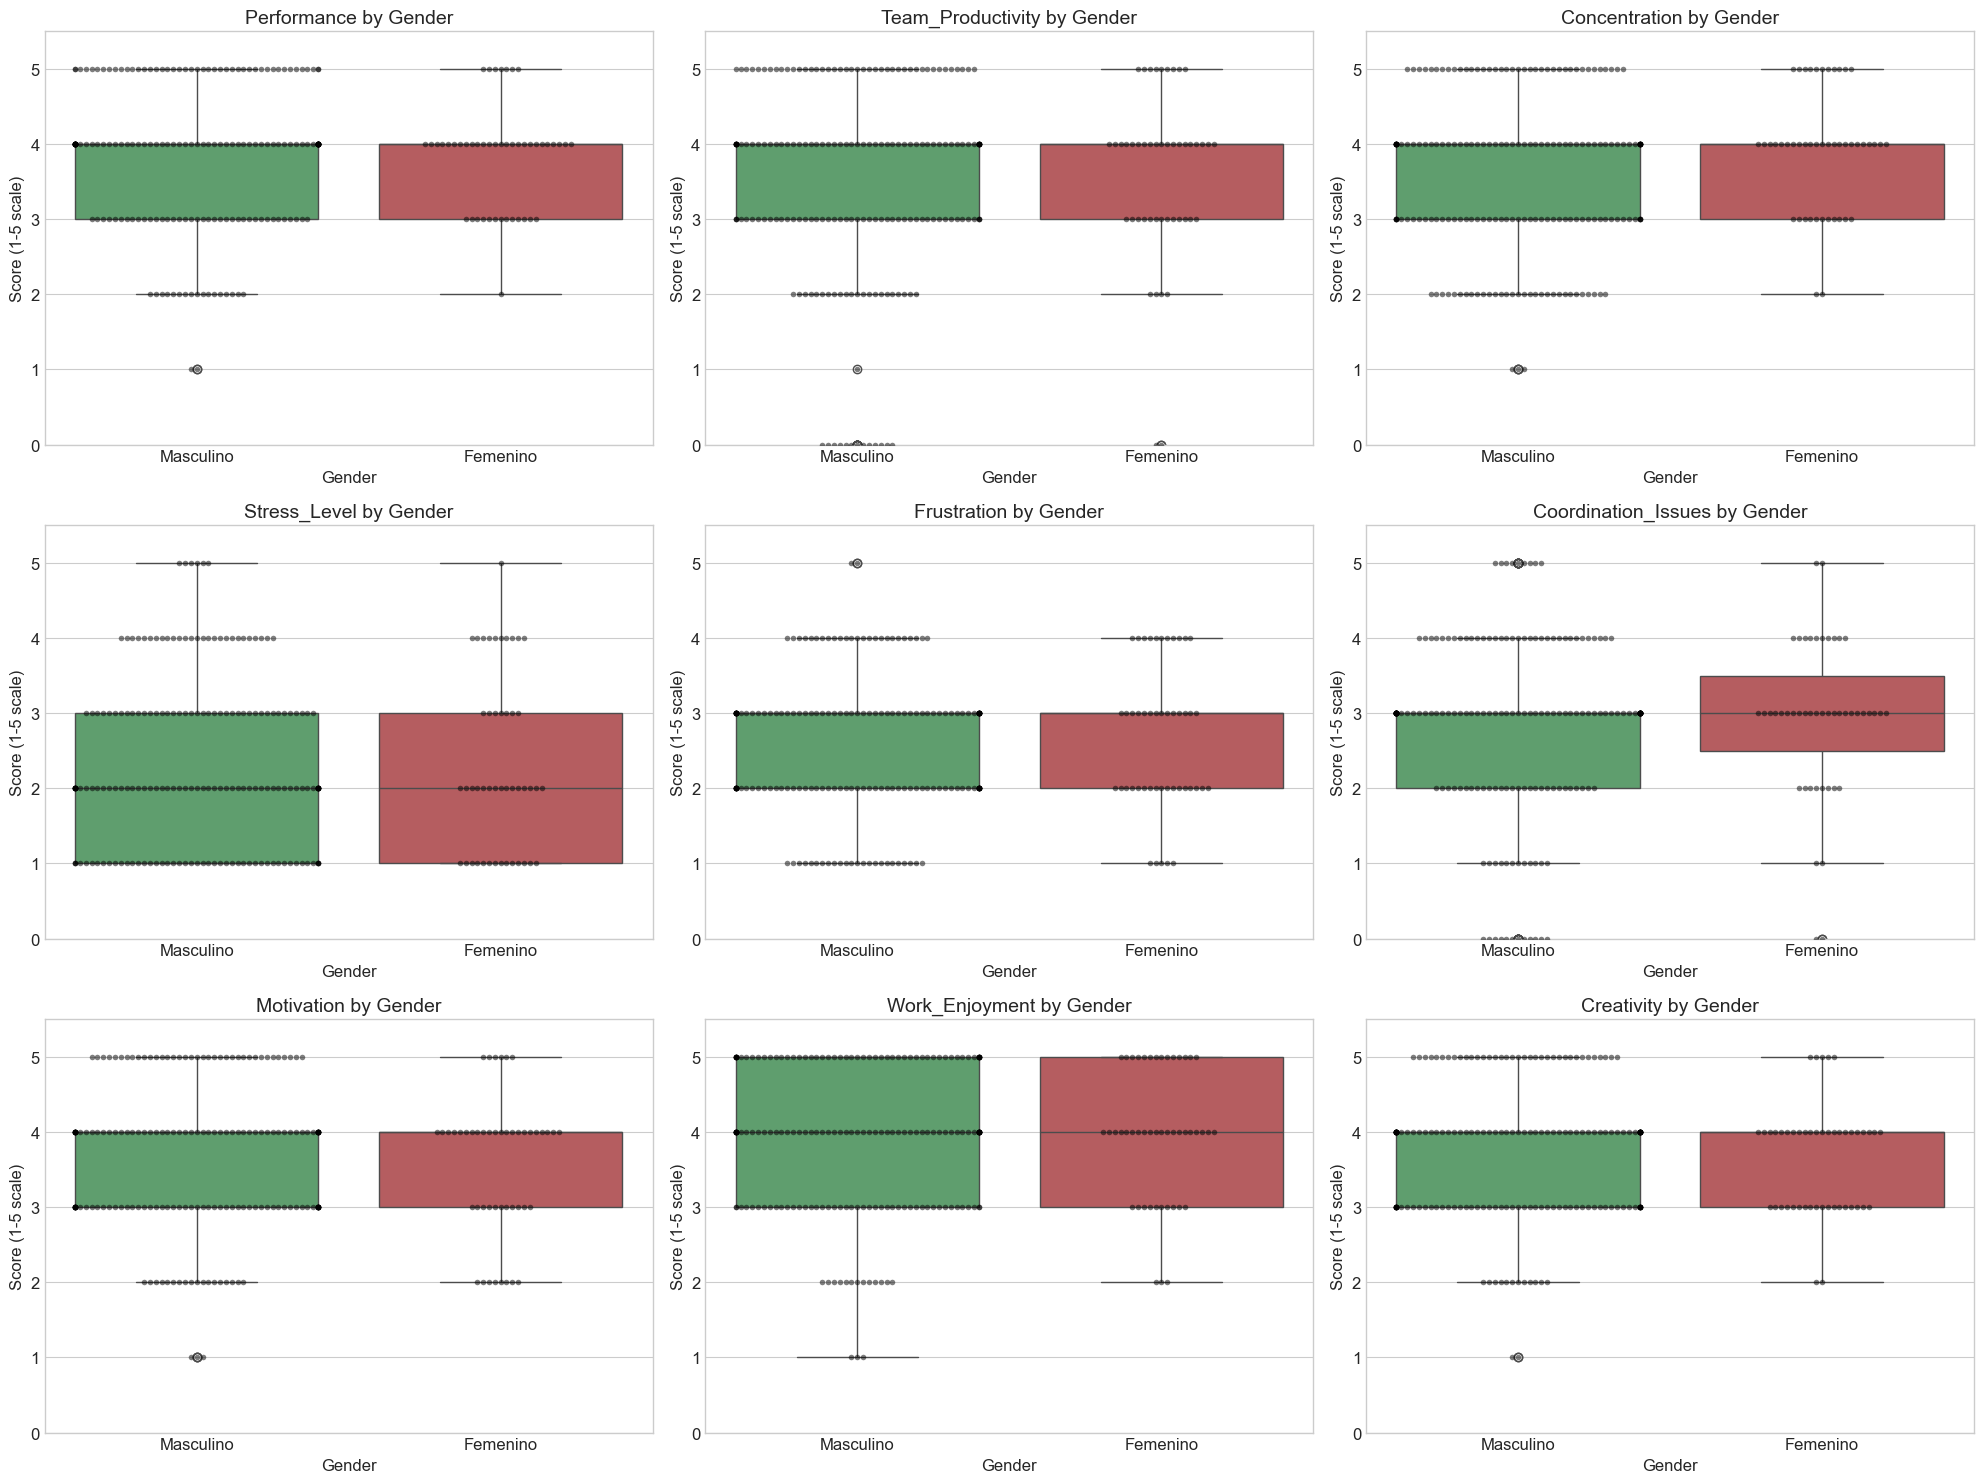

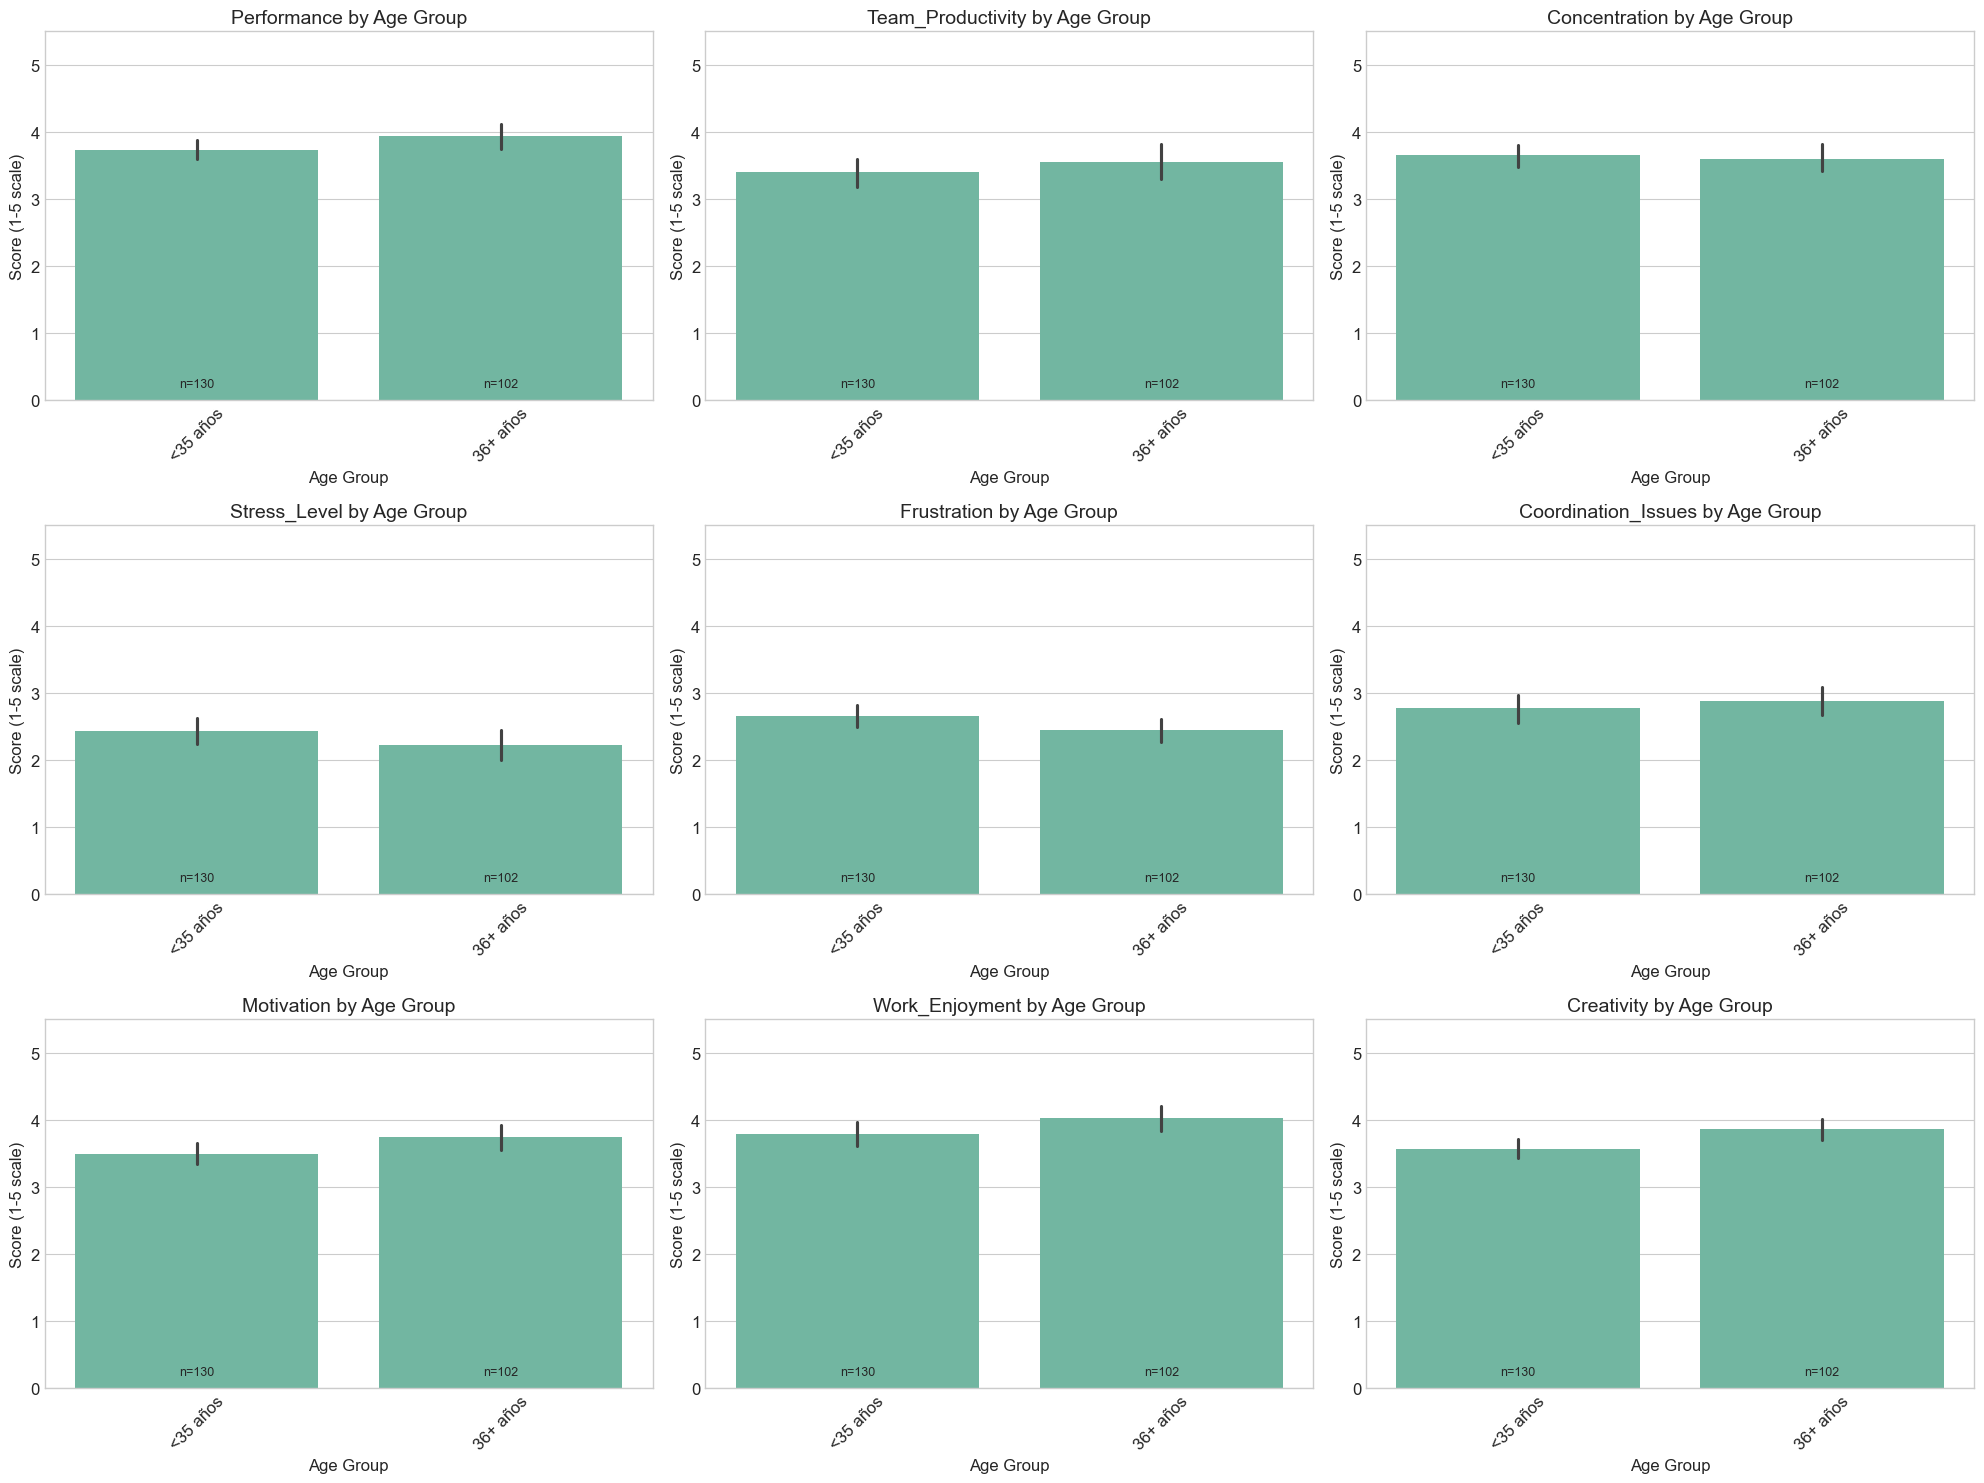

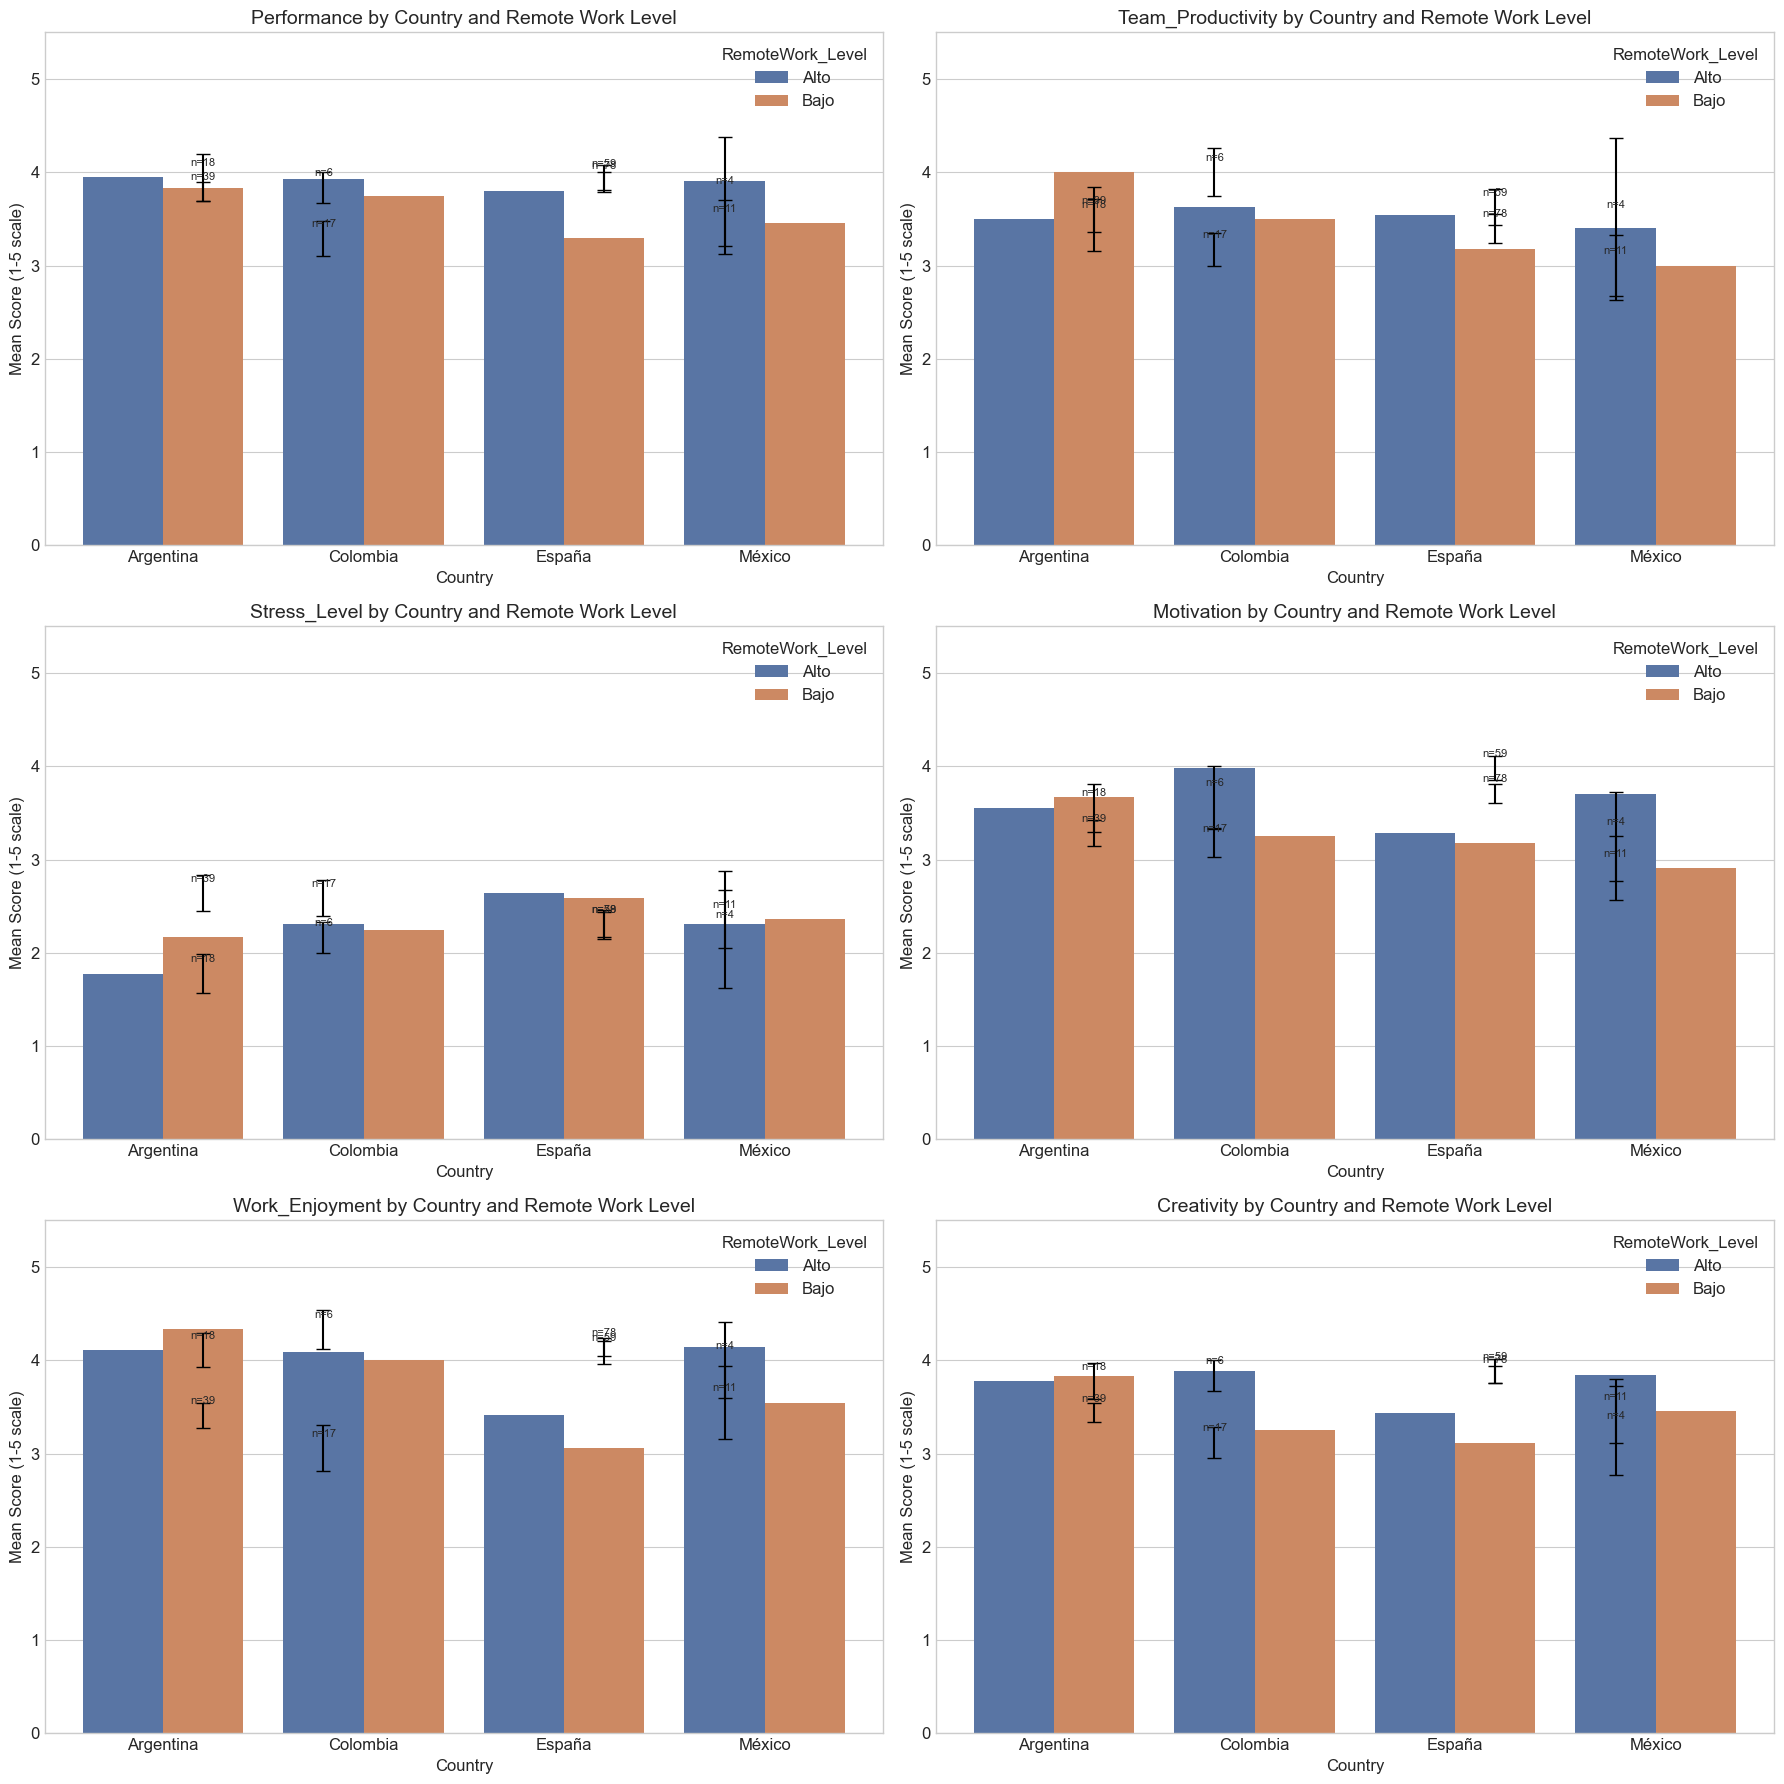

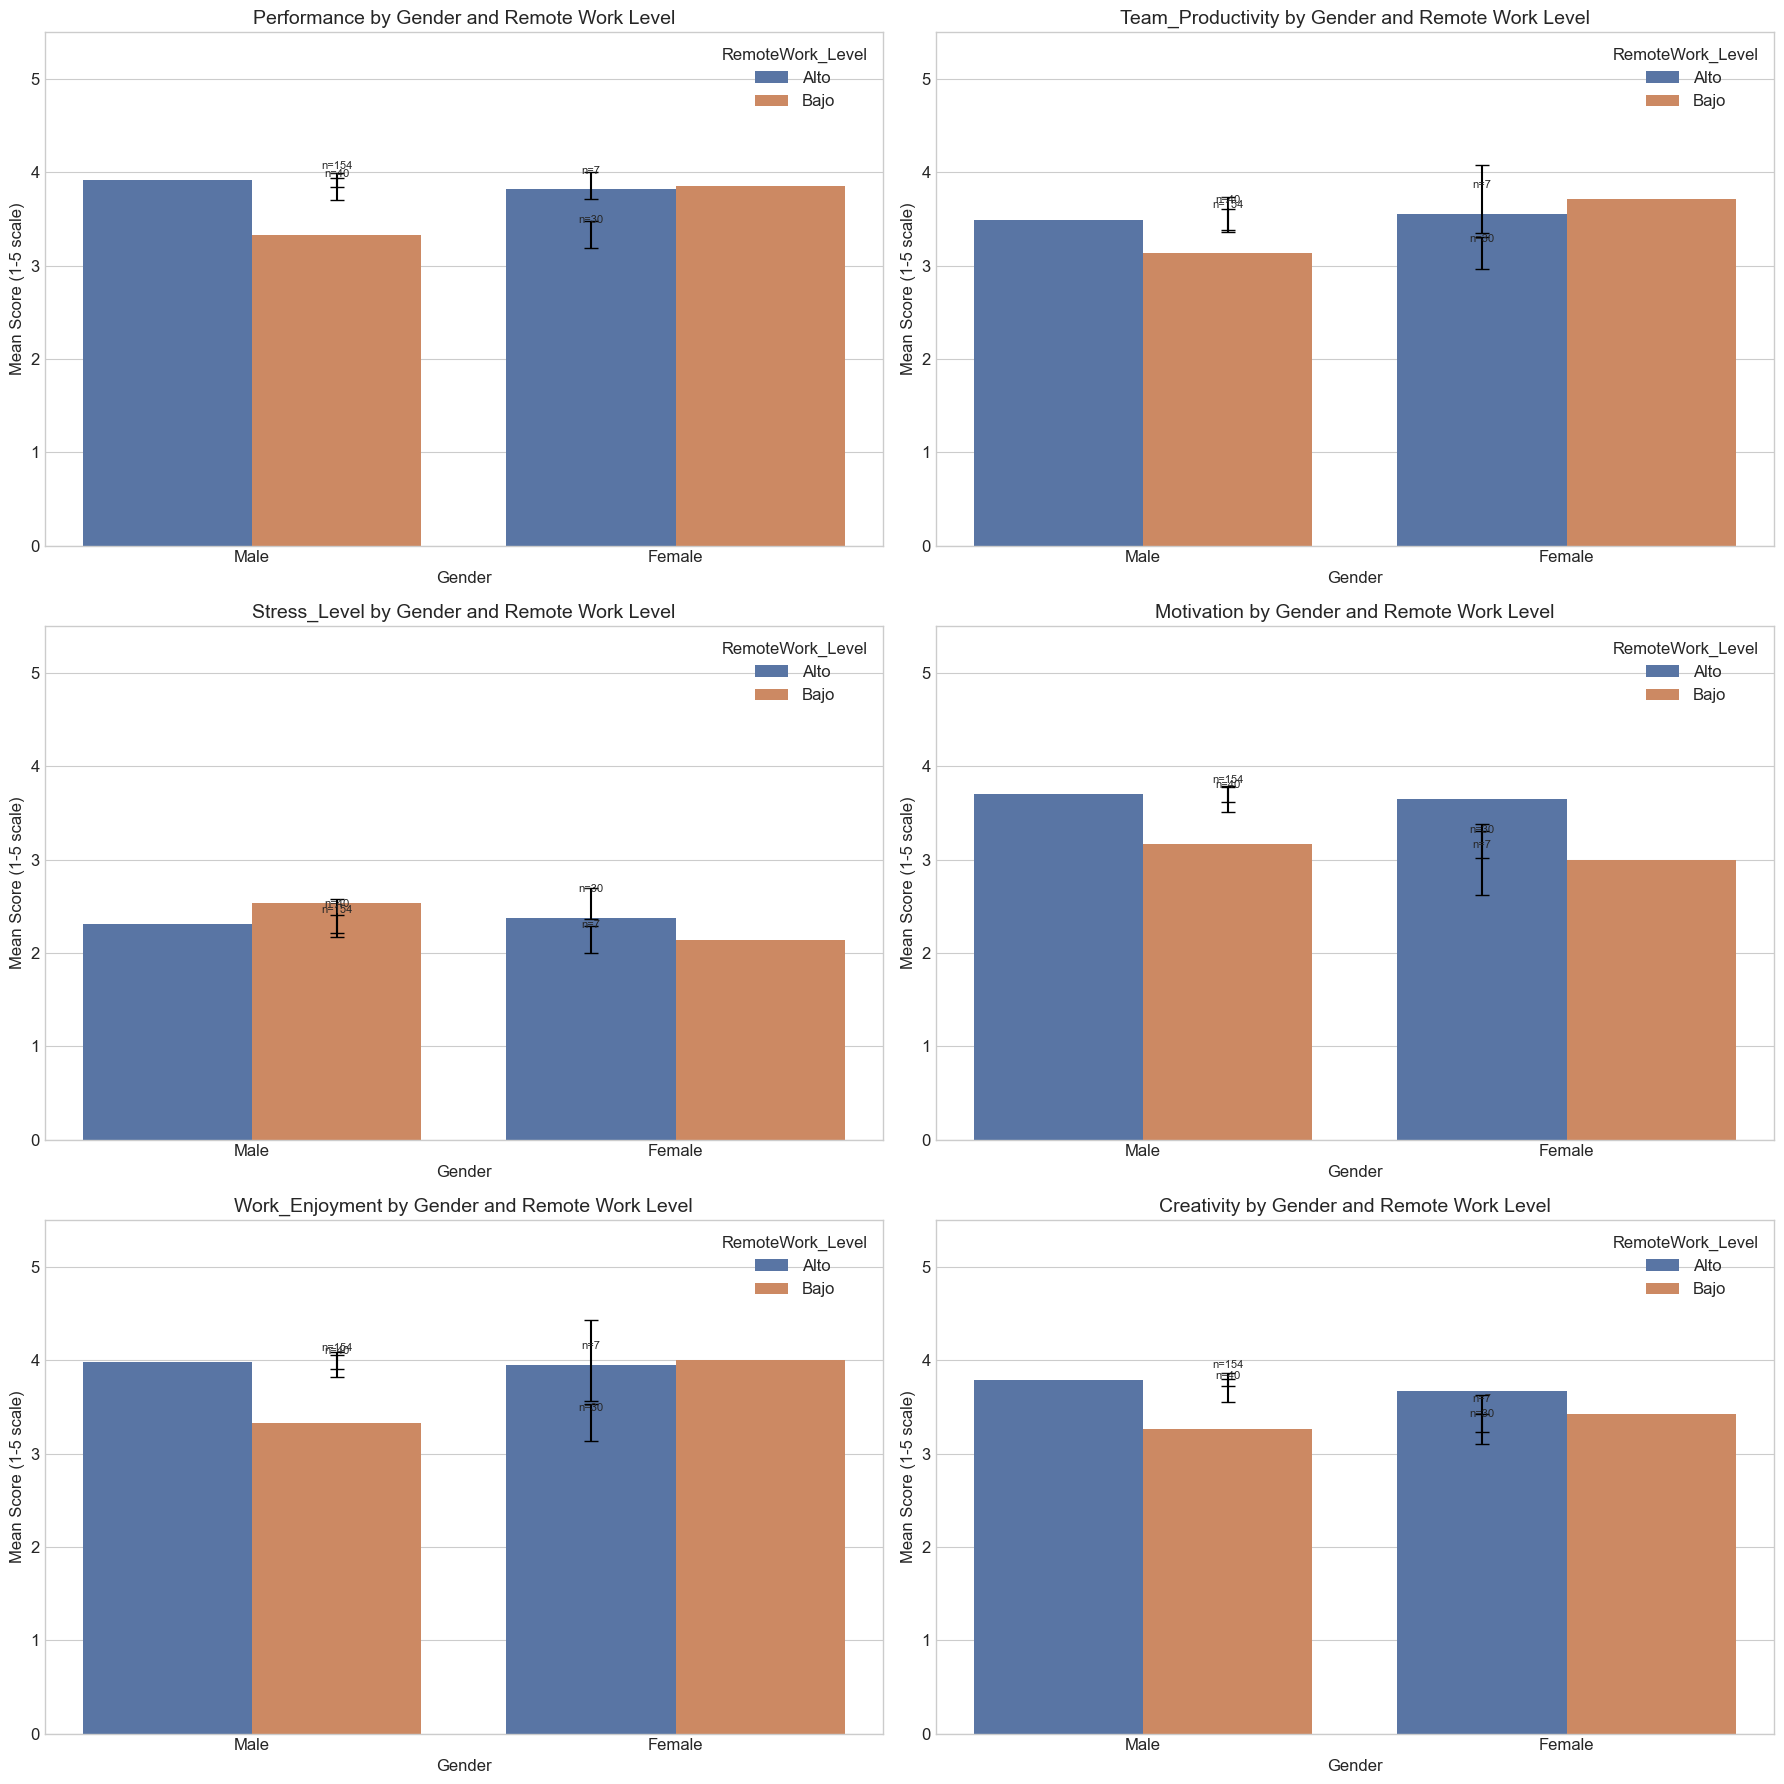

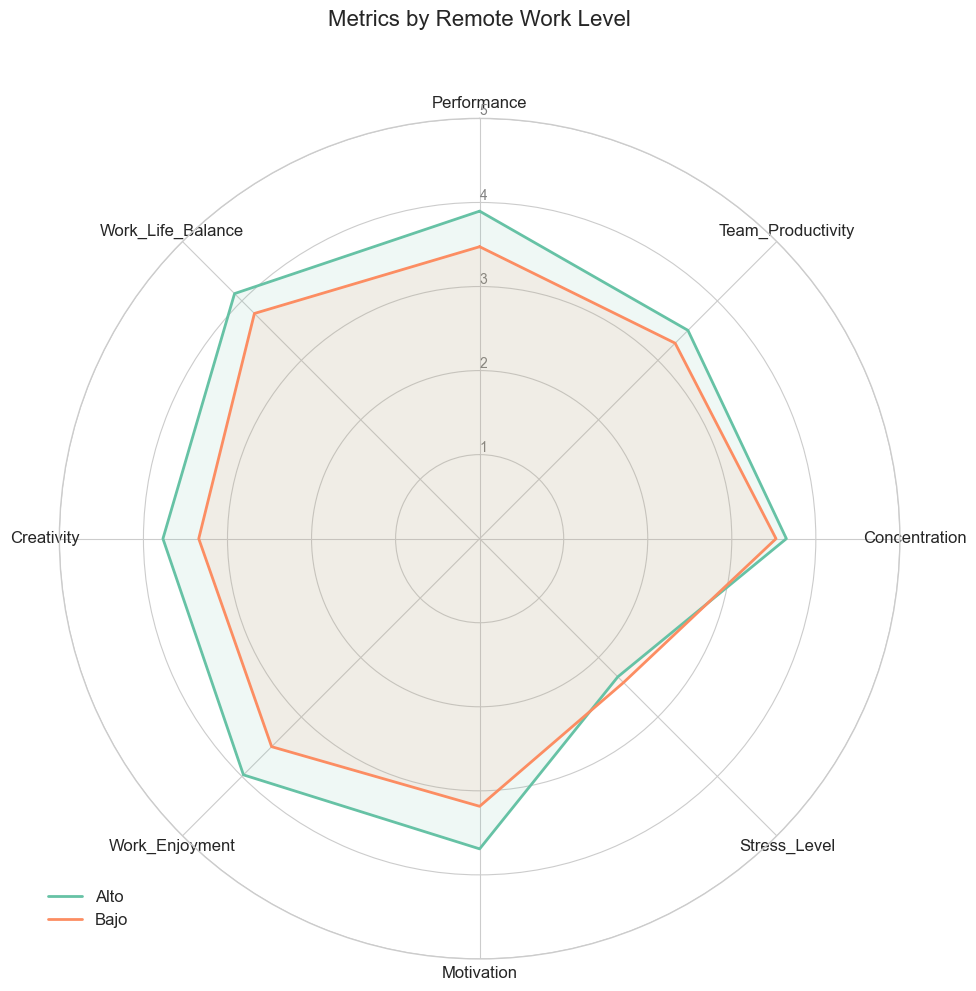

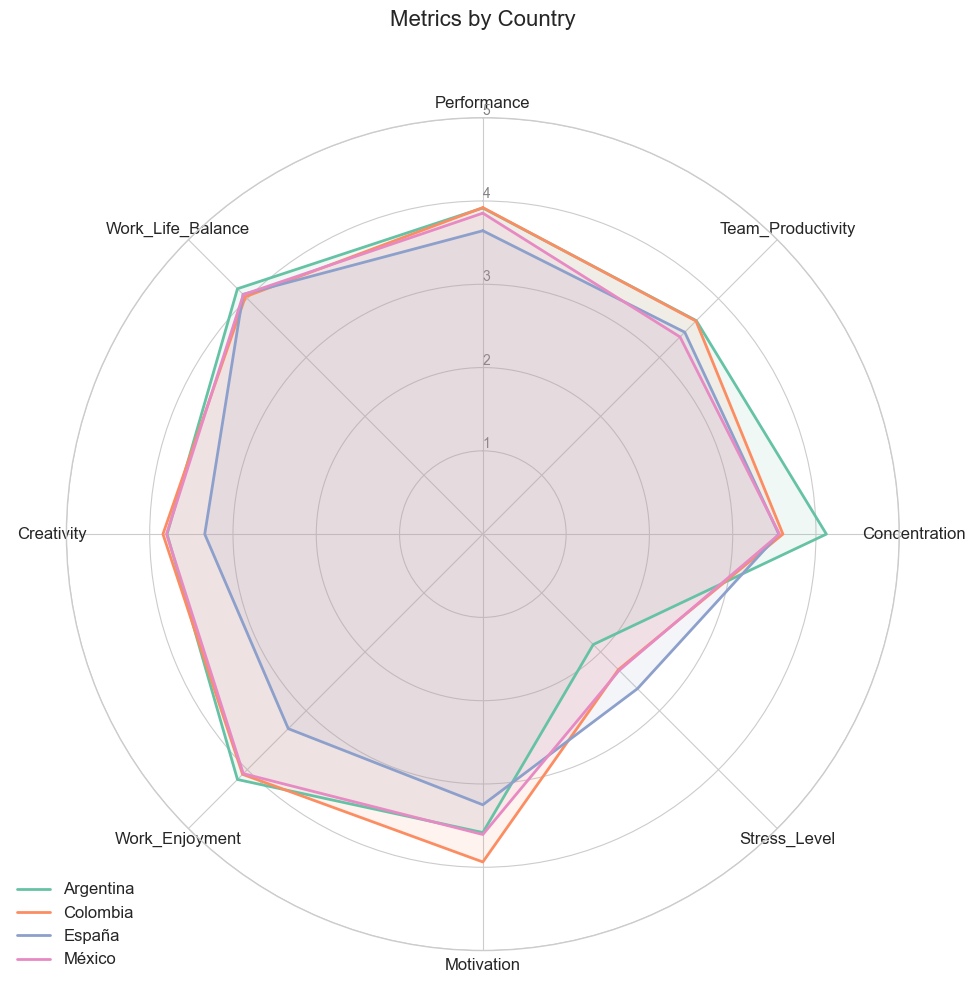

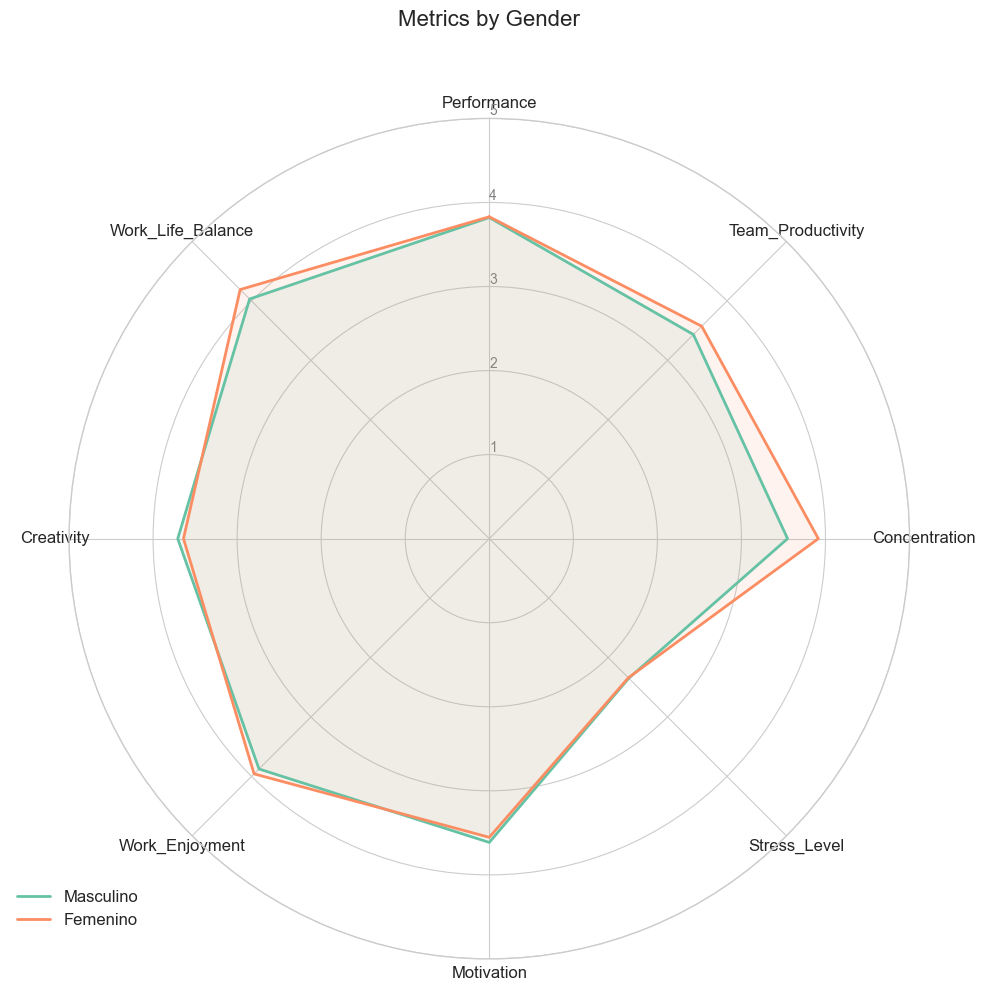

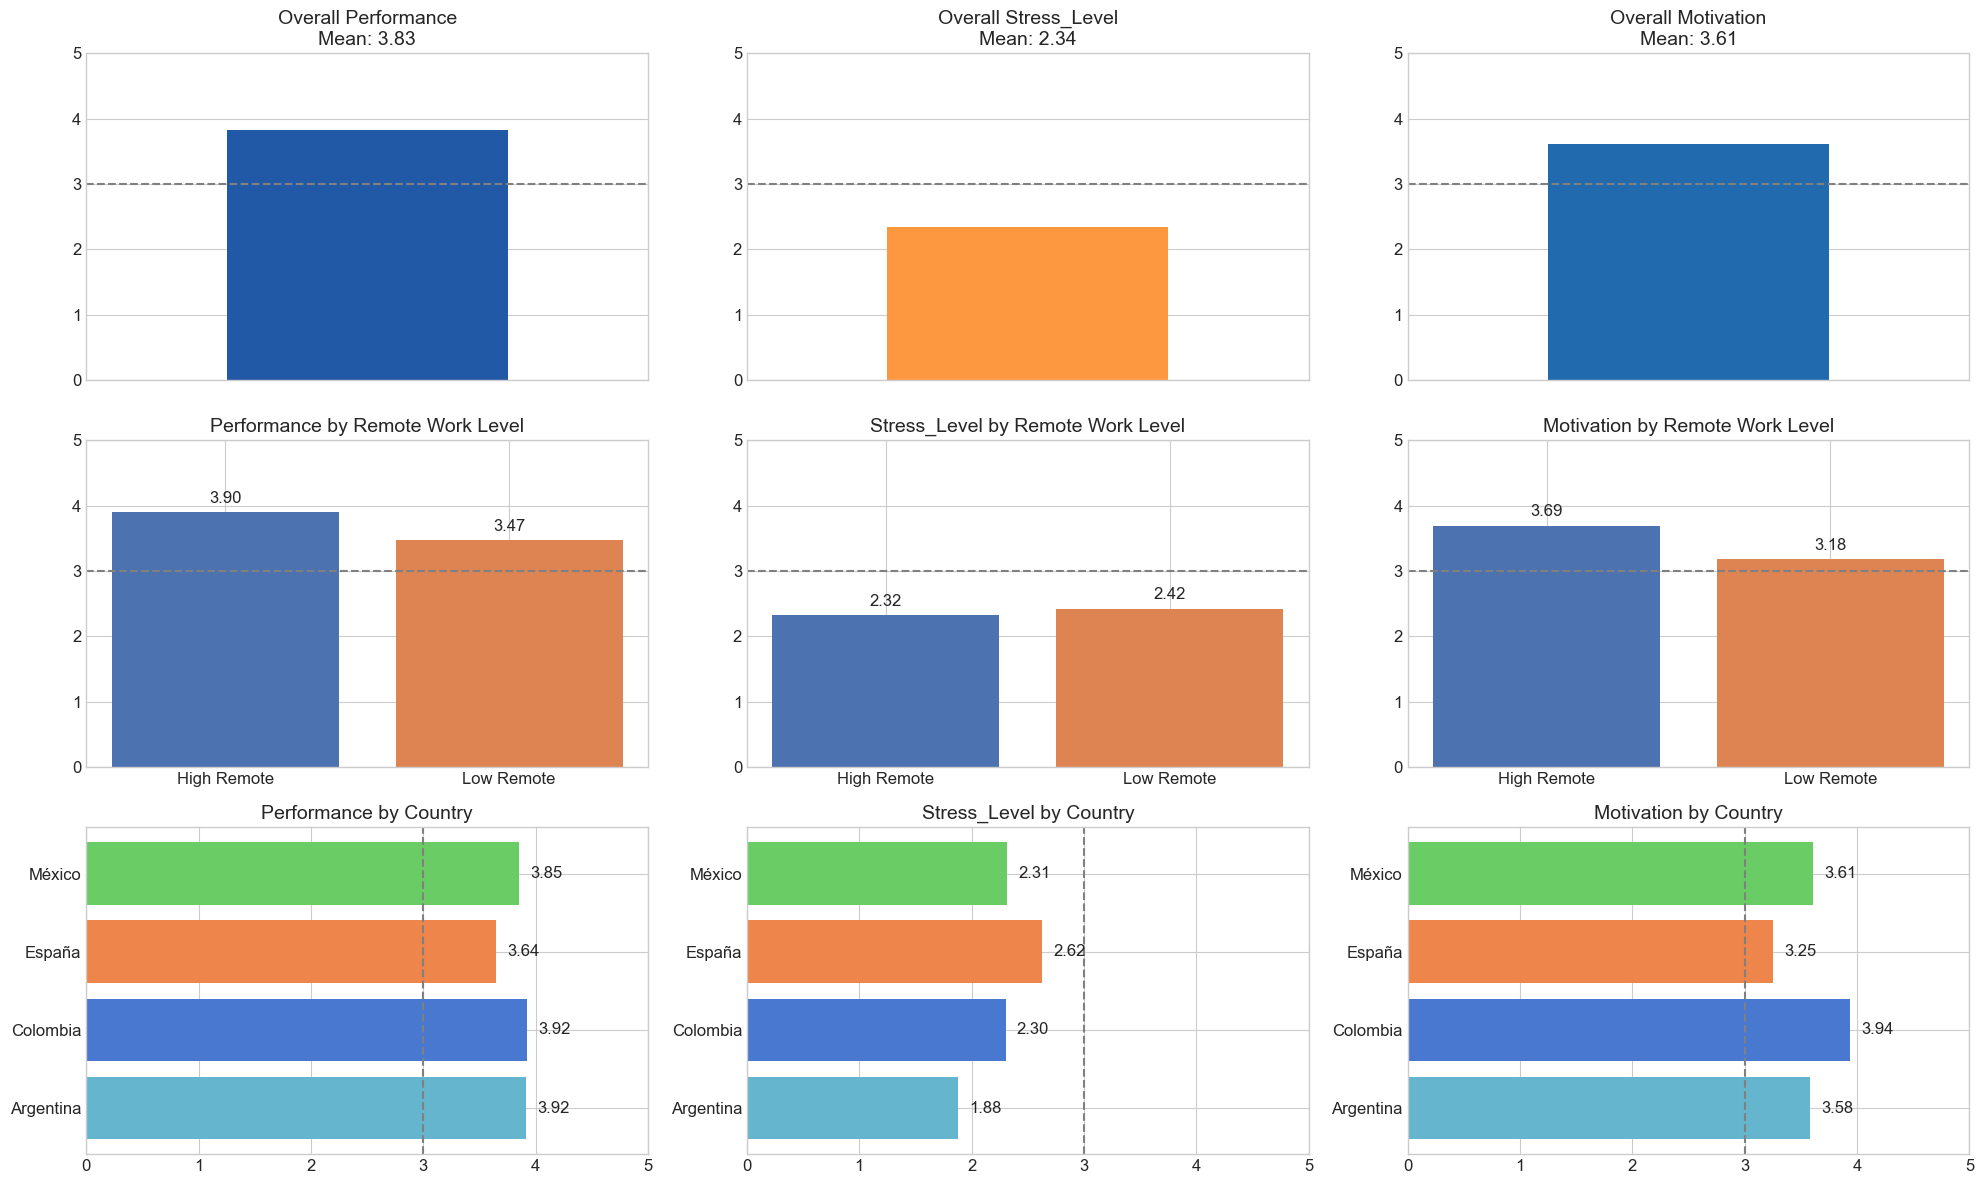

In [ ]:
remote_palette = {"Alto": "#4C72B0", "Bajo": "#DD8452"}
gender_palette = {"Masculino": "#55A868", "Femenino": "#C44E52", "No binario": "#8172B3"}
country_palette = {"Argentina": "#64B5CD", "Colombia": "#4878D0", "España": "#EE854A", "México": "#6ACC64"}
metric_palette = {"Performance": "#4C72B0", "Stress_Level": "#C44E52", "Motivation": "#55A868"}

# Define measurement categories again for reference
performance_metrics = ['Performance', 'Team_Productivity', 'Team_Milestones', 'Concentration']
stress_metrics = ['Stress_Level', 'Frustration', 'Task_Pressure', 'Coordination_Issues']
motivation_metrics = ['Motivation', 'Work_Enjoyment', 'Work_Interest', 'Creativity', 'Work_Life_Balance']

# %%
# 4.1 Create Distributions of Key Metrics
plt.figure(figsize=(18, 15))

# Focus on primary metrics from each category
primary_metrics = ['Performance', 'Team_Productivity', 'Stress_Level', 
                  'Motivation', 'Work_Enjoyment', 'Creativity']

for i, metric in enumerate(primary_metrics):
    plt.subplot(3, 2, i+1)
    
    sns.histplot(df_clean[metric], kde=True, bins=5)
    plt.title(f'Distribution of {metric}', fontsize=14)
    plt.xlabel('Score (1-5 scale)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    
    # Add mean and median lines
    mean_val = df_clean[metric].mean()
    median_val = df_clean[metric].median()
    
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle=':', label=f'Median: {median_val:.2f}')
    plt.legend()

plt.tight_layout()
plt.show()

# %%
# 4.2 Create Correlation Heatmap Between Key Metrics
# This helps identify relationships between metrics
plt.figure(figsize=(14, 12))

# Select key metrics for correlation analysis
corr_metrics = performance_metrics + stress_metrics + motivation_metrics
corr_df = df_clean[corr_metrics].copy()

# Calculate correlation matrix
corr_matrix = corr_df.corr()

# Create heatmap with annotations
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Create mask for upper triangle
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, vmin=-1, vmax=1, 
           linewidths=0.5)

plt.title('Correlation Matrix of Key Metrics', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# %%
# 4.3 Remote Work Level Comparisons - Boxplots
# Boxplots show distribution details (median, quartiles, outliers)
plt.figure(figsize=(20, 15))

# We'll use 9 key metrics - 3 from each category
boxplot_metrics = ['Performance', 'Team_Productivity', 'Concentration',
                  'Stress_Level', 'Frustration', 'Coordination_Issues',
                  'Motivation', 'Work_Enjoyment', 'Creativity']

for i, metric in enumerate(boxplot_metrics):
    plt.subplot(3, 3, i+1)
    
    # Create boxplot
    sns.boxplot(x='RemoteWork_Level', y=metric, data=df_clean, palette=remote_palette)
    
    # Add individual data points for more detail
    sns.stripplot(x='RemoteWork_Level', y=metric, data=df_clean, color='black', alpha=0.3, size=4)
    
    plt.title(f'{metric} by Remote Work Level', fontsize=14)
    plt.xlabel('Remote Work Level', fontsize=12)
    plt.ylabel('Score (1-5 scale)', fontsize=12)
    plt.ylim(0, 5.5)  # Consistent y-axis scale

plt.tight_layout()
plt.show()


# %%
# 4.5 Gender Comparisons - Box and Swarm Plots
# This combines boxplots with individual data points
plt.figure(figsize=(20, 15))

# Filter out 'No binario' if sample size is too small
gender_df = df_clean.copy()
if len(df_clean[df_clean['Gender'] == 'No binario']) < 5:
    gender_df = df_clean[df_clean['Gender'] != 'No binario']

for i, metric in enumerate(boxplot_metrics):
    plt.subplot(3, 3, i+1)
    
    # Create boxplot with swarm overlay
    sns.boxplot(x='Gender', y=metric, data=gender_df, palette=gender_palette)
    sns.swarmplot(x='Gender', y=metric, data=gender_df, color='black', alpha=0.5, size=4)
    
    plt.title(f'{metric} by Gender', fontsize=14)
    plt.xlabel('Gender', fontsize=12)
    plt.ylabel('Score (1-5 scale)', fontsize=12)
    plt.ylim(0, 5.5)  # Consistent y-axis scale

plt.tight_layout()
plt.show()

# %%
# 4.6 Age Group Comparisons - Grouped Bar Charts
plt.figure(figsize=(20, 15))

for i, metric in enumerate(boxplot_metrics):
    plt.subplot(3, 3, i+1)
    
    # Create grouped bar chart
    age_order = ['<35 años', '36+ años']
    sns.barplot(x='Age_Range', y=metric, data=df_clean, order=age_order)
    
    plt.title(f'{metric} by Age Group', fontsize=14)
    plt.xlabel('Age Group', fontsize=12)
    plt.ylabel('Score (1-5 scale)', fontsize=12)
    plt.ylim(0, 5.5)  # Consistent y-axis scale
    plt.xticks(rotation=45)
    
    # Add sample size for each age group
    for j, age in enumerate(age_order):
        count = len(df_clean[df_clean['Age_Range'] == age])
        if count > 0:
            plt.text(j, 0.2, f'n={count}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# %%
# 4.7 Interactive Visualizations - Country × Remote Work Level
plt.figure(figsize=(18, 18))

# Focus on 6 key metrics for this detailed analysis
interaction_metrics = ['Performance', 'Team_Productivity', 'Stress_Level', 
                     'Motivation', 'Work_Enjoyment', 'Creativity']

for i, metric in enumerate(interaction_metrics):
    plt.subplot(3, 2, i+1)
    
    # Prepare data for the interaction plot
    interaction_data = []
    for country in df_clean['Country'].unique():
        for remote_level in ['Alto', 'Bajo']:
            filtered_df = df_clean[(df_clean['Country'] == country) & 
                                 (df_clean['RemoteWork_Level'] == remote_level)]
            
            if len(filtered_df) > 0:
                interaction_data.append({
                    'Country': country,
                    'RemoteWork_Level': remote_level,
                    'Value': filtered_df[metric].mean(),
                    'Count': len(filtered_df),
                    'StdErr': filtered_df[metric].std() / np.sqrt(len(filtered_df)) if len(filtered_df) > 1 else 0
                })
    
    interaction_df = pd.DataFrame(interaction_data)
    
    # Create the interaction plot with error bars
    g = sns.barplot(x='Country', y='Value', hue='RemoteWork_Level', data=interaction_df, palette=remote_palette)
    
    # Add error bars
    for j, row in enumerate(interaction_df.itertuples()):
        g.errorbar(j % 4 + (0.2 if row.RemoteWork_Level == 'Alto' else -0.2), 
                 row.Value, yerr=row.StdErr, fmt='none', c='black', capsize=5)
    
    plt.title(f'{metric} by Country and Remote Work Level', fontsize=14)
    plt.xlabel('Country', fontsize=12)
    plt.ylabel('Mean Score (1-5 scale)', fontsize=12)
    plt.ylim(0, 5.5)
    
    # Add sample size annotations
    for j, row in enumerate(interaction_df.itertuples()):
        x_pos = j % 4 + (0.2 if row.RemoteWork_Level == 'Alto' else -0.2)
        plt.text(x_pos, row.Value + 0.1, f'n={row.Count}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# %%
# 4.8 Interactive Visualizations - Gender × Remote Work Level
plt.figure(figsize=(18, 18))

for i, metric in enumerate(interaction_metrics):
    plt.subplot(3, 2, i+1)
    
    # Prepare data for the interaction plot - focus on M/F due to sample size
    interaction_data = []
    for gender in ['Masculino', 'Femenino']:
        for remote_level in ['Alto', 'Bajo']:
            filtered_df = df_clean[(df_clean['Gender'] == gender) & 
                                 (df_clean['RemoteWork_Level'] == remote_level)]
            
            if len(filtered_df) > 0:
                interaction_data.append({
                    'Gender': 'Male' if gender == 'Masculino' else 'Female',
                    'RemoteWork_Level': remote_level,
                    'Value': filtered_df[metric].mean(),
                    'Count': len(filtered_df),
                    'StdErr': filtered_df[metric].std() / np.sqrt(len(filtered_df)) if len(filtered_df) > 1 else 0
                })
    
    interaction_df = pd.DataFrame(interaction_data)
    
    # Create the interaction plot with error bars
    g = sns.barplot(x='Gender', y='Value', hue='RemoteWork_Level', data=interaction_df, palette=remote_palette)
    
    # Add error bars
    for j, row in enumerate(interaction_df.itertuples()):
        g.errorbar(j % 2 + (0.2 if row.RemoteWork_Level == 'Alto' else -0.2), 
                 row.Value, yerr=row.StdErr, fmt='none', c='black', capsize=5)
    
    plt.title(f'{metric} by Gender and Remote Work Level', fontsize=14)
    plt.xlabel('Gender', fontsize=12)
    plt.ylabel('Mean Score (1-5 scale)', fontsize=12)
    plt.ylim(0, 5.5)
    
    # Add sample size annotations
    for j, row in enumerate(interaction_df.itertuples()):
        x_pos = j % 2 + (0.2 if row.RemoteWork_Level == 'Alto' else -0.2)
        plt.text(x_pos, row.Value + 0.1, f'n={row.Count}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# %%
# 4.9 Radar Charts for Comprehensive Pattern Visualization
# This provides a unique way to visualize patterns across multiple metrics
#import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

def radar_chart(df, metrics, group_col, title):
    # Set up the radar chart
    n_metrics = len(metrics)
    angles = np.linspace(0, 2*np.pi, n_metrics, endpoint=False).tolist()
    angles += angles[:1]  # Close the polygon
    
    fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))
    
    # Add metric labels around the chart
    ax.set_theta_offset(np.pi / 2)  # Start from top
    ax.set_theta_direction(-1)  # Go clockwise
    
    # Add axis labels with padding
    plt.xticks(angles[:-1], metrics, fontsize=12)
    
    # Draw axis lines for each metric
    ax.set_rlabel_position(0)
    plt.yticks([1, 2, 3, 4, 5], ['1', '2', '3', '4', '5'], color='grey', fontsize=10)
    plt.ylim(0, 5)
    
    # Get unique groups and assign colors
    groups = df[group_col].unique()
    
    # Calculate mean for each group and metric
    for i, group in enumerate(groups):
        group_data = df[df[group_col] == group]
        values = [group_data[metric].mean() for metric in metrics]
        values += values[:1]  # Close the polygon
        
        # Plot the group data
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=group)
        ax.fill(angles, values, alpha=0.1)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    
    plt.title(title, fontsize=16, y=1.1)
    return fig, ax

# %%
# Create radar charts for each demographic group
metrics_for_radar = ['Performance', 'Team_Productivity', 'Concentration', 'Stress_Level', 
                    'Motivation', 'Work_Enjoyment', 'Creativity', 'Work_Life_Balance']

# Remote Work Level radar chart
fig, ax = radar_chart(df_clean, metrics_for_radar, 'RemoteWork_Level', 'Metrics by Remote Work Level')
plt.tight_layout()
plt.show()

# Country radar chart
fig, ax = radar_chart(df_clean, metrics_for_radar, 'Country', 'Metrics by Country')
plt.tight_layout()
plt.show()

# Gender radar chart (filtering out No binario if sample size is too small)
gender_df = df_clean.copy()
if len(df_clean[df_clean['Gender'] == 'No binario']) < 5:
    gender_df = df_clean[df_clean['Gender'] != 'No binario']
    
fig, ax = radar_chart(gender_df, metrics_for_radar, 'Gender', 'Metrics by Gender')
plt.tight_layout()
plt.show()

# %%
# 4.10 Create Multi-Metric Dashboard
# Summarize overall patterns across key metrics and groups
plt.figure(figsize=(20, 12))

# Dashboard Layout:
# 1. Top Row: Key Metrics Overall
top_metrics = ['Performance', 'Stress_Level', 'Motivation']

# First row: Overall averages
for i, metric in enumerate(top_metrics):
    plt.subplot(3, 3, i+1)
    
    # Create gauge-like visualization
    mean_val = df_clean[metric].mean()
    
    # Create a color gradient based on the metric
    if metric == 'Stress_Level':
        color = plt.cm.YlOrRd(mean_val/5)  # Higher stress = more red
    else:
        color = plt.cm.YlGnBu(mean_val/5)  # Higher values = more blue
    
    plt.bar(0, mean_val, width=0.5, color=color)
    plt.ylim(0, 5)
    plt.xlim(-0.5, 0.5)
    plt.xticks([])
    plt.yticks([0, 1, 2, 3, 4, 5])
    plt.title(f'Overall {metric}\nMean: {mean_val:.2f}', fontsize=14)
    
    # Add a horizontal line at the midpoint (3)
    plt.axhline(y=3, linestyle='--', color='gray')

# Second row: Remote Work Level differences
for i, metric in enumerate(top_metrics):
    plt.subplot(3, 3, i+4)
    
    alto_mean = df_clean[df_clean['RemoteWork_Level'] == 'Alto'][metric].mean()
    bajo_mean = df_clean[df_clean['RemoteWork_Level'] == 'Bajo'][metric].mean()
    
    # Create a bar chart
    bars = plt.bar(['High Remote', 'Low Remote'], [alto_mean, bajo_mean], 
           color=['#4C72B0', '#DD8452'])
    
    plt.ylim(0, 5)
    plt.title(f'{metric} by Remote Work Level', fontsize=14)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.2f}', ha='center', va='bottom')
    
    # Add a horizontal line at the midpoint (3)
    plt.axhline(y=3, linestyle='--', color='gray')

# Third row: Country comparison for key metrics
for i, metric in enumerate(top_metrics):
    plt.subplot(3, 3, i+7)
    
    country_means = []
    for country in ['Argentina', 'Colombia', 'España', 'México']:
        mean_val = df_clean[df_clean['Country'] == country][metric].mean()
        country_means.append({'Country': country, 'Mean': mean_val})
    
    country_df = pd.DataFrame(country_means)
    
    # Create a horizontal bar chart
    bars = plt.barh(country_df['Country'], country_df['Mean'], color=list(country_palette.values()))
    
    plt.xlim(0, 5)
    plt.title(f'{metric} by Country', fontsize=14)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2.,
                f'{width:.2f}', ha='left', va='center')
    
    # Add a vertical line at the midpoint (3)
    plt.axvline(x=3, linestyle='--', color='gray')

plt.tight_layout()
plt.show()

# SECTION 5: STATISTICAL TESTS FOR GROUP DIFFERENCES

T-tests comparing High vs Low Remote Work:
              Metric Group1 Group2     Mean1     Mean2  Difference  \
0        Performance   Alto   Bajo  3.896907  3.473684    0.423223   
1  Team_Productivity   Alto   Bajo  3.505155  3.289474    0.215681   
2    Team_Milestones   Alto   Bajo  3.391753  3.184211    0.207542   
3      Concentration   Alto   Bajo  3.649485  3.526316    0.123169   
4       Stress_Level   Alto   Bajo  2.324742  2.421053   -0.096310   
5         Motivation   Alto   Bajo  3.690722  3.184211    0.506511   
6     Work_Enjoyment   Alto   Bajo  3.974227  3.500000    0.474227   
7  Work_Life_Balance   Alto   Bajo  4.123711  3.789474    0.334238   
8         Creativity   Alto   Bajo  3.768041  3.342105    0.425936   

   t_statistic   p_value  Significant  
0     2.926545  0.004905         True  
1     1.150318  0.254009        False  
2     1.207873  0.231155        False  
3     0.737504  0.463853        False  
4    -0.591525  0.556147        False  
5     3.239426  

C:\Users\Camilo Daza\AppData\Local\Temp\ipykernel_22592\3010818550.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Difference', data=remote_ttests,


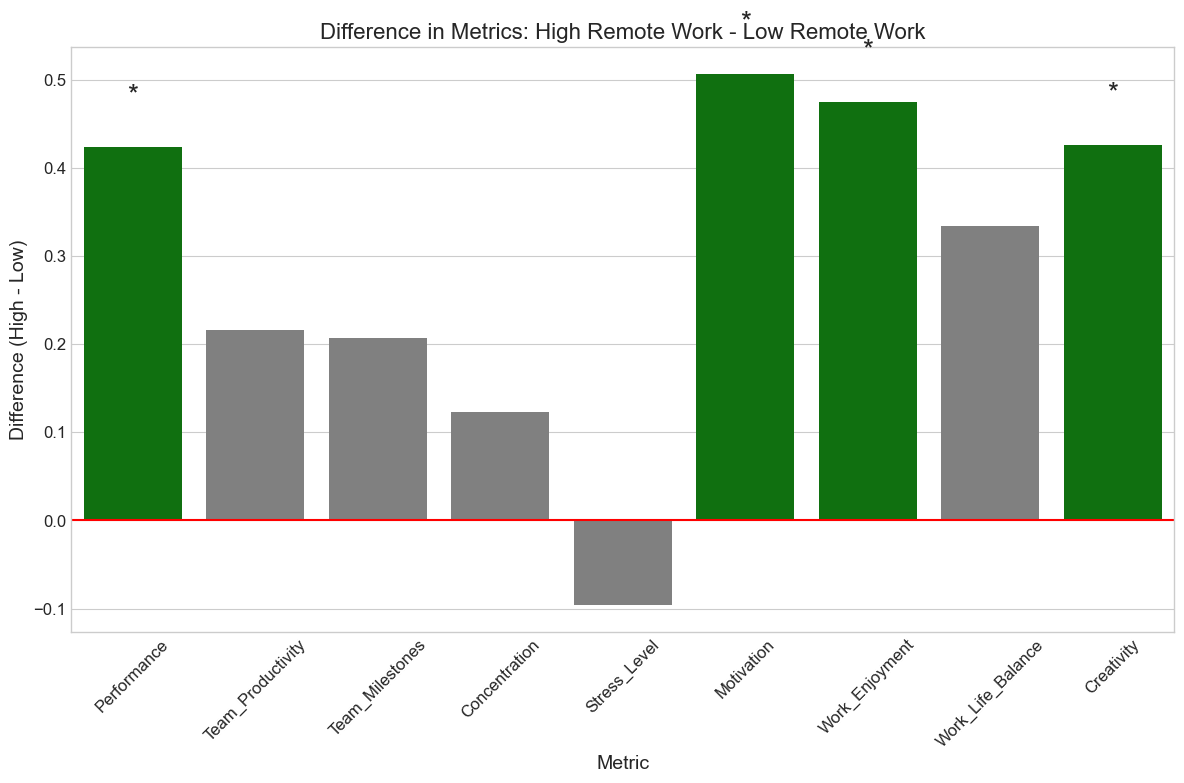

C:\Users\Camilo Daza\AppData\Local\Temp\ipykernel_22592\3010818550.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='F_statistic', data=country_anova,



ANOVA results for Country differences:
              Metric  F_statistic   p_value  Significant
0        Performance     1.116405  0.343197        False
1  Team_Productivity     0.649974  0.583715        False
2    Team_Milestones     1.058485  0.367544        False
3      Concentration     2.189147  0.090106        False
4       Stress_Level     2.644198  0.050000         True
5         Motivation     5.334734  0.001435         True
6     Work_Enjoyment    10.493098  0.000002         True
7  Work_Life_Balance     0.087085  0.967067        False
8         Creativity     4.466030  0.004535         True


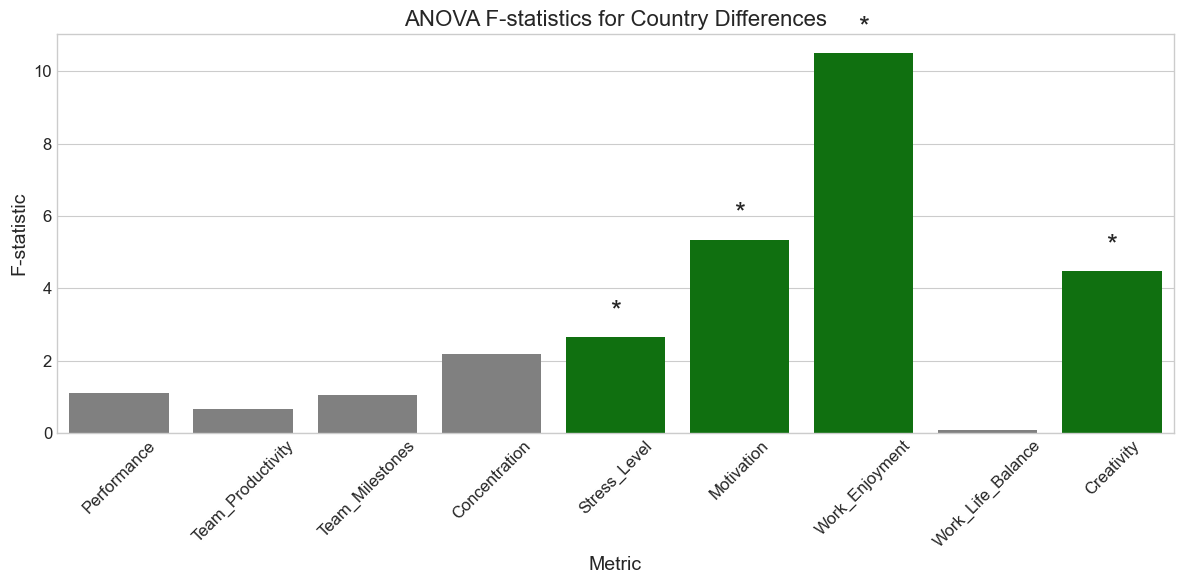


ANOVA results for Age Group differences:
              Metric  F_statistic   p_value  Significant
0        Performance     2.923878  0.088626        False
1  Team_Productivity     0.832437  0.362524        False
2    Team_Milestones     0.002814  0.957741        False
3      Concentration     0.172063  0.678671        False
4       Stress_Level     1.899110  0.169517        False
5         Motivation     3.762768  0.053628        False
6     Work_Enjoyment     3.480992  0.063351        False
7  Work_Life_Balance     0.925822  0.336961        False
8         Creativity     6.742922  0.010019         True


C:\Users\Camilo Daza\AppData\Local\Temp\ipykernel_22592\3010818550.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='F_statistic', data=age_anova,


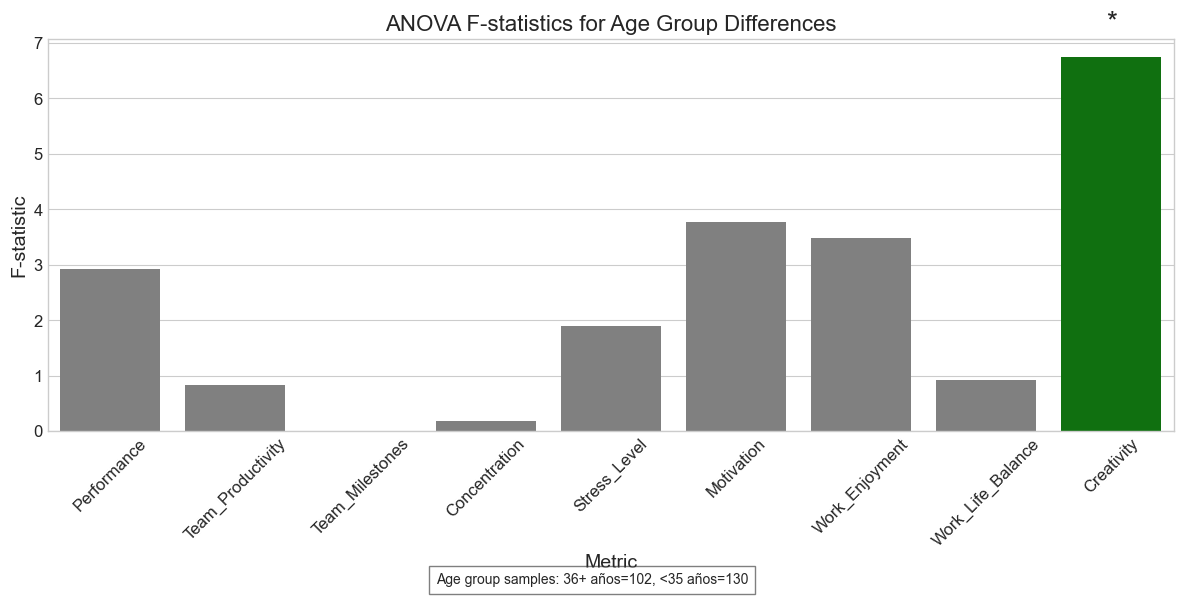


T-test results comparing Males vs Females:
              Metric     Group1    Group2     Mean1     Mean2  Difference  \
0        Performance  Masculino  Femenino  3.820652  3.829787   -0.009135   
1  Team_Productivity  Masculino  Femenino  3.434783  3.574468   -0.139685   
2    Team_Milestones  Masculino  Femenino  3.375000  3.255319    0.119681   
3      Concentration  Masculino  Femenino  3.548913  3.914894   -0.365981   
4       Stress_Level  Masculino  Femenino  2.347826  2.340426    0.007401   
5         Motivation  Masculino  Femenino  3.614130  3.553191    0.060939   
6     Work_Enjoyment  Masculino  Femenino  3.875000  3.957447   -0.082447   
7  Work_Life_Balance  Masculino  Femenino  4.032609  4.191489   -0.158881   
8         Creativity  Masculino  Femenino  3.706522  3.638298    0.068224   

   t_statistic   p_value  Significant  
0    -0.073818  0.941313        False  
1    -0.712863  0.477970        False  
2     0.598429  0.551452        False  
3    -2.607202  0.010675 

C:\Users\Camilo Daza\AppData\Local\Temp\ipykernel_22592\3010818550.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Difference', data=gender_ttests,


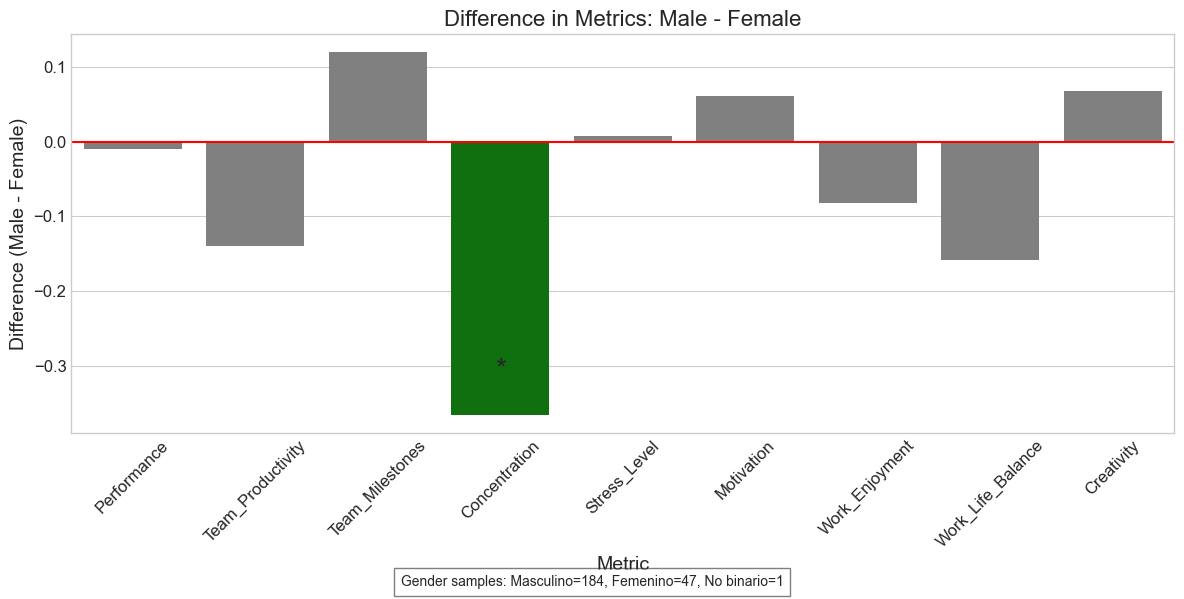

In [35]:
def t_test_by_group(df: pd.DataFrame, group_col: str, metric_cols: List[str], 
                   group1: str, group2: str, alpha: float = 0.05) -> pd.DataFrame:
    """
    Perform t-tests comparing two groups for each metric
    """
    results = []
    
    for metric in metric_cols:
        # Get data for each group
        group1_data = df[df[group_col] == group1][metric].dropna()
        group2_data = df[df[group_col] == group2][metric].dropna()
        
        # Skip if not enough data
        if len(group1_data) < 2 or len(group2_data) < 2:
            continue
        
        # Perform t-test
        t_stat, p_val = ttest_ind(group1_data, group2_data, equal_var=False)
        
        # Calculate means
        mean1 = group1_data.mean()
        mean2 = group2_data.mean()
        diff = mean1 - mean2
        
        # Store results
        results.append({
            'Metric': metric,
            'Group1': group1,
            'Group2': group2,
            'Mean1': mean1,
            'Mean2': mean2,
            'Difference': diff,
            't_statistic': t_stat,
            'p_value': p_val,
            'Significant': p_val < alpha
        })
    
    return pd.DataFrame(results)

# %%
def anova_by_group(df: pd.DataFrame, group_col: str, metric_cols: List[str], 
                  alpha: float = 0.05) -> pd.DataFrame:
    """
    Perform one-way ANOVA tests for each metric across groups
    """
    results = []
    
    for metric in metric_cols:
        # Get unique groups
        groups = df[group_col].unique()
        
        # Get data for each group
        group_data = [df[df[group_col] == group][metric].dropna() for group in groups]
        
        # Skip if any group has insufficient data
        if any(len(data) < 2 for data in group_data):
            continue
        
        # Perform ANOVA
        f_stat, p_val = f_oneway(*group_data)
        
        # Store results
        results.append({
            'Metric': metric,
            'F_statistic': f_stat,
            'p_value': p_val,
            'Significant': p_val < alpha
        })
    
    return pd.DataFrame(results)

# %%
# 5.1 T-test for Remote Work Level (Alto vs Bajo)
remote_ttests = t_test_by_group(df_clean, 'RemoteWork_Level', key_metrics, 'Alto', 'Bajo')
print("T-tests comparing High vs Low Remote Work:")
print(remote_ttests)

# %%
# Visualize t-test results for Remote Work Level
plt.figure(figsize=(12, 8))
significant_metrics = remote_ttests[remote_ttests['Significant'] == True]['Metric'].tolist()

# Create a bar chart showing the difference between Alto and Bajo for each metric
sns.barplot(x='Metric', y='Difference', data=remote_ttests, 
            palette=['green' if x in significant_metrics else 'gray' for x in remote_ttests['Metric']])

plt.axhline(y=0, color='r', linestyle='-')
plt.title('Difference in Metrics: High Remote Work - Low Remote Work', fontsize=16)
plt.xlabel('Metric', fontsize=14)
plt.ylabel('Difference (High - Low)', fontsize=14)
plt.xticks(rotation=45)

# Add significance indicators
for i, row in remote_ttests.iterrows():
    if row['Significant']:
        plt.text(i, row['Difference'] + 0.05, '*', fontsize=20, ha='center')

plt.tight_layout()
plt.show()

# %%
# 5.2 ANOVA for Country differences
country_anova = anova_by_group(df_clean, 'Country', key_metrics)
print("\nANOVA results for Country differences:")
print(country_anova)

# %%
# Visualize ANOVA results for Country
plt.figure(figsize=(12, 6))
significant_metrics = country_anova[country_anova['Significant'] == True]['Metric'].tolist()

# Create a bar chart showing the F-statistic for each metric
sns.barplot(x='Metric', y='F_statistic', data=country_anova, 
            palette=['green' if x in significant_metrics else 'gray' for x in country_anova['Metric']])

plt.title('ANOVA F-statistics for Country Differences', fontsize=16)
plt.xlabel('Metric', fontsize=14)
plt.ylabel('F-statistic', fontsize=14)
plt.xticks(rotation=45)

# Add significance indicators
for i, row in country_anova.iterrows():
    if row['Significant']:
        plt.text(i, row['F_statistic'] + 0.5, '*', fontsize=20, ha='center')

plt.tight_layout()
plt.show()

# %%
# 5.3 ANOVA for Age Group differences
age_anova = anova_by_group(df_clean, 'Age_Range', key_metrics)
print("\nANOVA results for Age Group differences:")
print(age_anova)

# %%
# Visualize ANOVA results for Age Groups
plt.figure(figsize=(12, 6))
significant_metrics = age_anova[age_anova['Significant'] == True]['Metric'].tolist()

# Create a bar chart showing the F-statistic for each metric
sns.barplot(x='Metric', y='F_statistic', data=age_anova, 
            palette=['green' if x in significant_metrics else 'gray' for x in age_anova['Metric']])

plt.title('ANOVA F-statistics for Age Group Differences', fontsize=16)
plt.xlabel('Metric', fontsize=14)
plt.ylabel('F-statistic', fontsize=14)
plt.xticks(rotation=45)

# Add significance indicators
for i, row in age_anova.iterrows():
    if row['Significant']:
        plt.text(i, row['F_statistic'] + 0.5, '*', fontsize=20, ha='center')

# Display age group sample sizes
sample_sizes = df_clean['Age_Range'].value_counts().sort_index()
plt.figtext(0.5, 0.01, f"Age group samples: {', '.join([f'{k}={v}' for k, v in sample_sizes.items()])}", 
            ha='center', fontsize=10, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

plt.tight_layout()
plt.show()

# %%
# 5.4 ANOVA/T-test for Gender differences
# We'll use t-test instead of ANOVA since we primarily have two genders 
# (the No binario category has very few samples)
gender_ttests = t_test_by_group(df_clean, 'Gender', key_metrics, 'Masculino', 'Femenino')
print("\nT-test results comparing Males vs Females:")
print(gender_ttests)

# %%
# Visualize Gender differences
plt.figure(figsize=(12, 6))
significant_metrics = gender_ttests[gender_ttests['Significant'] == True]['Metric'].tolist()

# Create a bar chart showing the difference between Males and Females for each metric
sns.barplot(x='Metric', y='Difference', data=gender_ttests, 
            palette=['green' if x in significant_metrics else 'gray' for x in gender_ttests['Metric']])

plt.axhline(y=0, color='r', linestyle='-')
plt.title('Difference in Metrics: Male - Female', fontsize=16)
plt.xlabel('Metric', fontsize=14)
plt.ylabel('Difference (Male - Female)', fontsize=14)
plt.xticks(rotation=45)

# Add significance indicators
for i, row in gender_ttests.iterrows():
    if row['Significant']:
        plt.text(i, row['Difference'] + 0.05, '*', fontsize=20, ha='center')

# Display gender sample sizes
male_count = len(df_clean[df_clean['Gender'] == 'Masculino'])
female_count = len(df_clean[df_clean['Gender'] == 'Femenino'])
nb_count = len(df_clean[df_clean['Gender'] == 'No binario'])
plt.figtext(0.5, 0.01, f"Gender samples: Masculino={male_count}, Femenino={female_count}, No binario={nb_count}", 
            ha='center', fontsize=10, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

plt.tight_layout()
plt.show()
# END OF SECTION 5

# SECTION 6: INTERACTION ANALYSIS - HOW REMOTE WORK EFFECTS VARY BY DEMOGRAPHICS


SECTION 6: INTERACTION ANALYSIS - HOW REMOTE WORK EFFECTS VARY BY DEMOGRAPHICS

6.1 Remote Work Effect by Country:

Country: Argentina
              Metric  Alto_Mean  Bajo_Mean  Difference  t_statistic   p_value  \
0        Performance   3.944444   3.833333    0.111111     0.371015  0.714312   
1         Motivation   3.555556   3.666667   -0.111111    -0.263416  0.796855   
2       Stress_Level   1.777778   2.166667   -0.388889    -1.463348  0.159707   
3  Work_Life_Balance   4.277778   3.833333    0.444444     1.583323  0.128883   
4      Concentration   4.111111   4.166667   -0.055556    -0.182753  0.856716   
5     Work_Enjoyment   4.111111   4.333333   -0.222222    -0.803982  0.436057   
6  Team_Productivity   3.500000   4.000000   -0.500000    -1.159510  0.259881   

   Significant  
0        False  
1        False  
2        False  
3        False  
4        False  
5        False  
6        False  
  Skipping Performance due to insufficient data
  Skipping Motivation due to in

<Figure size 1600x1200 with 0 Axes>

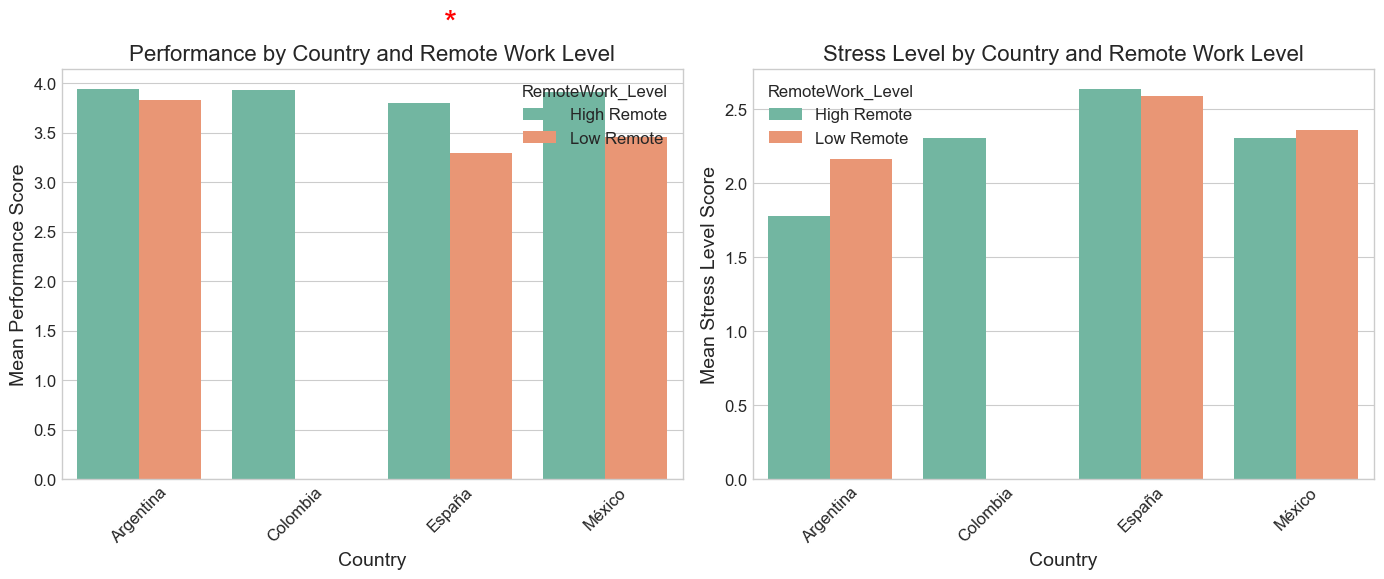

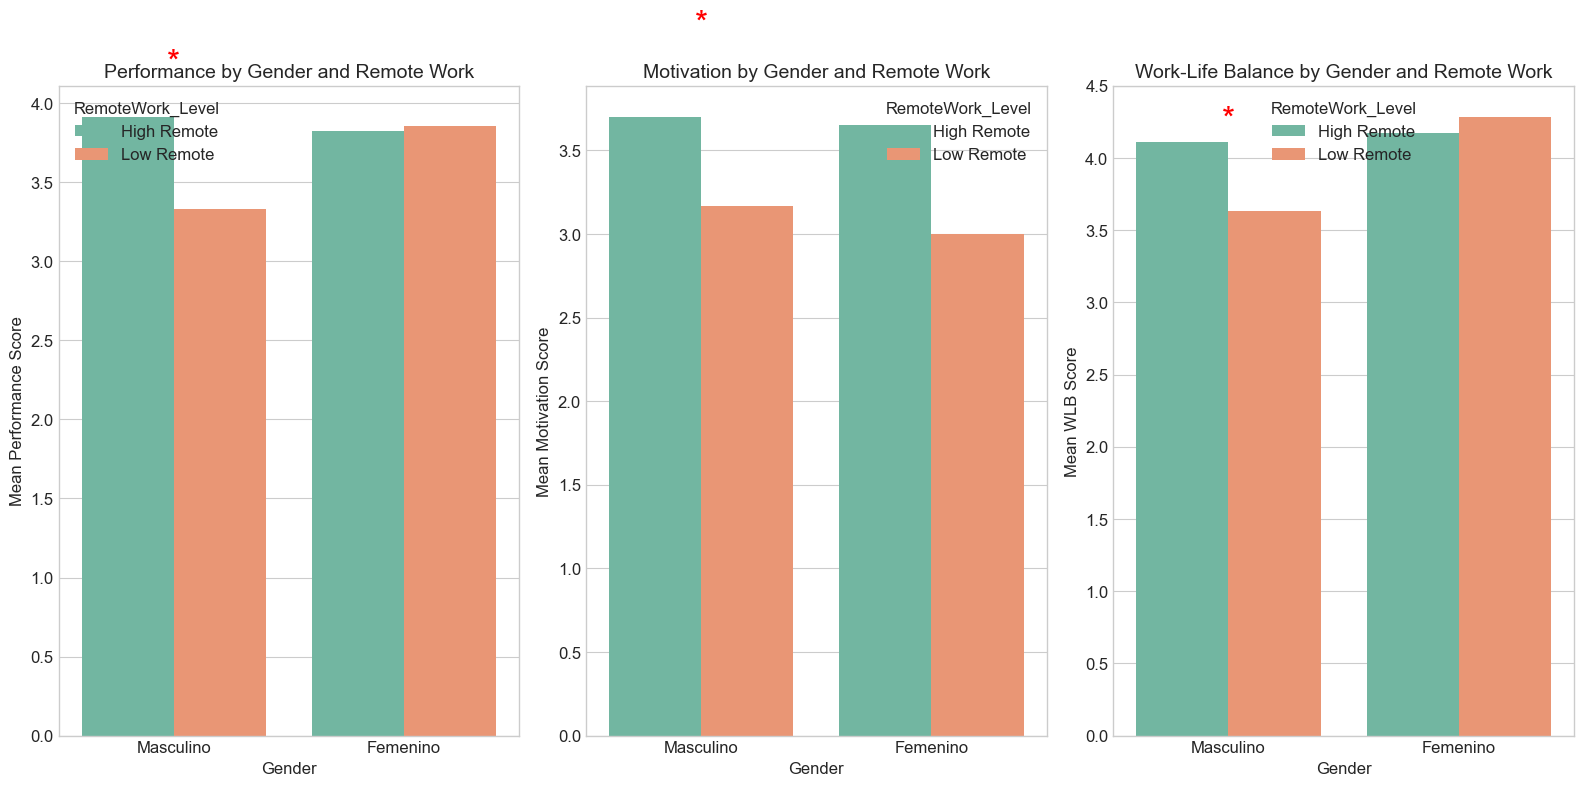

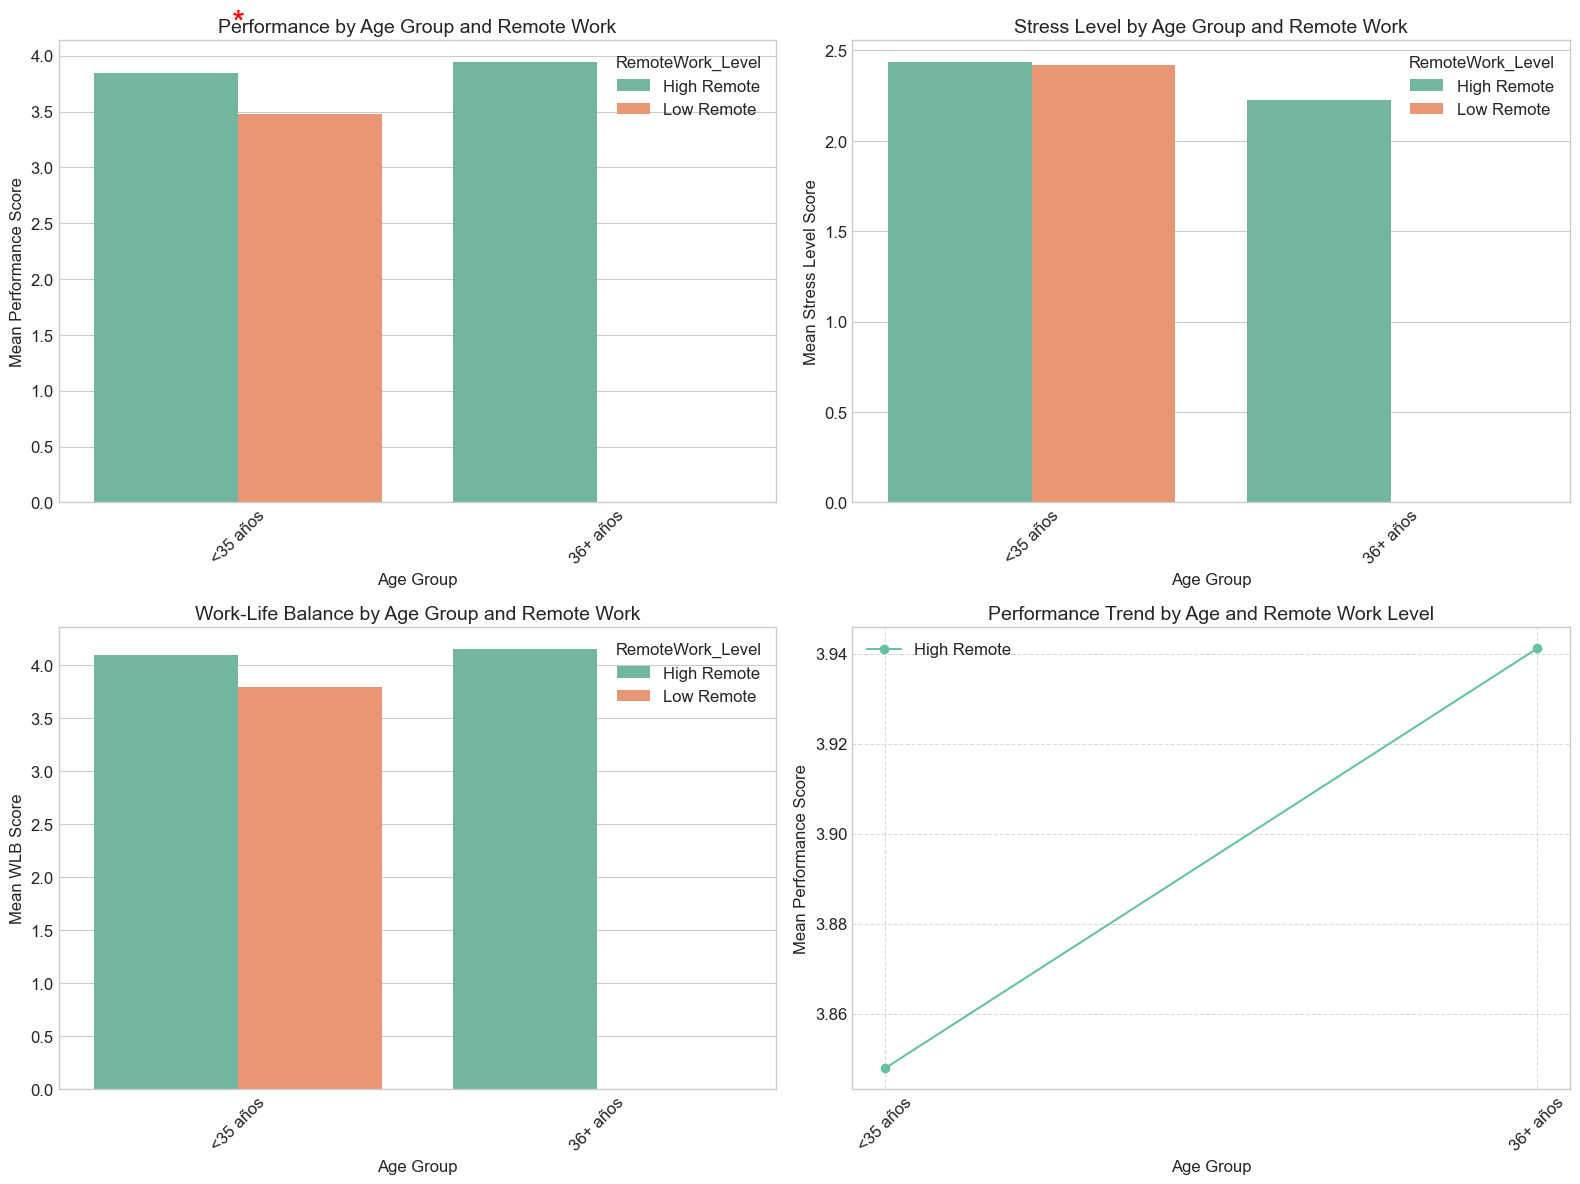


6.8 Summary of Key Interaction Findings:

Significant Remote Work Effects by Country:
  España: Performance differs by 0.50 points (p=0.0275)
  México: Motivation differs by 0.80 points (p=0.0460)

Significant Remote Work Effects by Gender:
  Masculino: Performance differs by 0.58 points (p=0.0010)
  Masculino: Motivation differs by 0.53 points (p=0.0021)
  Masculino: Work_Life_Balance differs by 0.48 points (p=0.0402)
  Masculino: Work_Enjoyment differs by 0.65 points (p=0.0035)

Significant Remote Work Effects by Age Group:
  <35 años: Performance differs by 0.37 points (p=0.0196)
  <35 años: Motivation differs by 0.45 points (p=0.0103)
  <35 años: Work_Enjoyment differs by 0.41 points (p=0.0468)

Complex Interaction Patterns:
  See visualizations and ANOVA results for complex interaction patterns.
  Key finding: The effect of remote work varies significantly by demographic factors.


In [ ]:
# Define a utility function to conduct t-tests by group
def t_test_by_group(df, group_var, metrics, group1, group2):
    results = []
    
    for metric in metrics:
        # Extract data for each group
        group1_data = df[df[group_var] == group1][metric].dropna()
        group2_data = df[df[group_var] == group2][metric].dropna()
        
        # Skip/pss if not enough data
        if len(group1_data) < 5 or len(group2_data) < 5:
            print(f"  Skipping {metric} due to insufficient data")
            continue
        
        # Conduct t-test
        t_stat, p_val = ttest_ind(group1_data, group2_data, equal_var=False)
        
        # Calculate means and difference
        mean1 = group1_data.mean()
        mean2 = group2_data.mean()
        diff = mean1 - mean2
        
        # Determine if significant
        significant = p_val < 0.05
        
        # Store result
        results.append({
            'Metric': metric,
            f'{group1}_Mean': mean1,
            f'{group2}_Mean': mean2,
            'Difference': diff,
            't_statistic': t_stat,
            'p_value': p_val,
            'Significant': significant
        })
    
    return pd.DataFrame(results)

print("\n" + "="*80)
print("SECTION 6: INTERACTION ANALYSIS - HOW REMOTE WORK EFFECTS VARY BY DEMOGRAPHICS")
print("="*80)

# Define key metrics we want to examine
key_metrics = ['Performance', 'Motivation', 'Stress_Level', 'Work_Life_Balance', 
              'Concentration', 'Work_Enjoyment', 'Team_Productivity']

# 6.1 Remote Work Effect by Country
print("\n6.1 Remote Work Effect by Country:")

# Create a figure to visualize these interactions
plt.figure(figsize=(16, 12))
significant_country_effects = []

for i, country in enumerate(df_clean['Country'].unique()):
    country_df = df_clean[df_clean['Country'] == country]
    country_remote_ttests = t_test_by_group(country_df, 'RemoteWork_Level', 
                                           key_metrics, 
                                           'Alto', 'Bajo')
    
    print(f"\nCountry: {country}")
    print(country_remote_ttests)
    
    # Store significant effects
    for _, row in country_remote_ttests.iterrows():
        if row['Significant']:
            significant_country_effects.append({
                'Country': country,
                'Metric': row['Metric'],
                'Difference': row['Difference'],
                'p_value': row['p_value']
            })

# 6.2 Remote Work Effect by Gender
print("\n6.2 Remote Work Effect by Gender:")

significant_gender_effects = []
for gender in df_clean['Gender'].unique():
    if pd.isna(gender) or gender not in ['Masculino', 'Femenino']:
        continue
        
    gender_df = df_clean[df_clean['Gender'] == gender]
    gender_remote_ttests = t_test_by_group(gender_df, 'RemoteWork_Level', 
                                          key_metrics, 
                                          'Alto', 'Bajo')
    
    print(f"\nGender: {gender}")
    print(gender_remote_ttests)
    
    # Store significant effects
    for _, row in gender_remote_ttests.iterrows():
        if row['Significant']:
            significant_gender_effects.append({
                'Gender': gender,
                'Metric': row['Metric'],
                'Difference': row['Difference'],
                'p_value': row['p_value']
            })

# 6.3 Remote Work Effect by Age Group
print("\n6.3 Remote Work Effect by Age Group:")

significant_age_effects = []
for age_group in df_clean['Age_Range'].unique():
    if pd.isna(age_group):
        continue
        
    age_df = df_clean[df_clean['Age_Range'] == age_group]
    age_remote_ttests = t_test_by_group(age_df, 'RemoteWork_Level', 
                                      key_metrics, 
                                      'Alto', 'Bajo')
    
    print(f"\nAge Group: {age_group}")
    print(age_remote_ttests)
    
    # Store significant effects
    for _, row in age_remote_ttests.iterrows():
        if row['Significant']:
            significant_age_effects.append({
                'Age_Group': age_group,
                'Metric': row['Metric'],
                'Difference': row['Difference'],
                'p_value': row['p_value']
            })

# 6.4 Complex Interaction: Country x Gender x Remote Work
print("\n6.4 Complex Interaction: Country x Gender x Remote Work")

# Define the function to calculate mean metrics
def calculate_mean_metrics(df, metrics):
    """Calculate mean of each metric in the dataframe"""
    return {metric: df[metric].mean() for metric in metrics if metric in df.columns}

# Container for interaction data
complex_interaction_data = []

# Loop through each country
for country in df_clean['Country'].unique():
    country_df = df_clean[df_clean['Country'] == country]
    
    # Loop through each gender
    for gender in ['Masculino', 'Femenino']:
        gender_df = country_df[country_df['Gender'] == gender]
        
        # Skip if not enough data
        if len(gender_df) < 10:
            print(f"  Skipping {country}-{gender} due to insufficient data")
            continue
        
        # Loop through remote work levels
        for remote_level in ['Alto', 'Bajo']:
            subset_df = gender_df[gender_df['RemoteWork_Level'] == remote_level]
            
            # Skip if not enough data
            if len(subset_df) < 5:
                print(f"  Skipping {country}-{gender}-{remote_level} due to insufficient data")
                continue
            
            # Calculate means for key metrics
            means = calculate_mean_metrics(subset_df, key_metrics)
            
            # Add demographic info
            means['Country'] = country
            means['Gender'] = gender
            means['RemoteWork_Level'] = 'High Remote' if remote_level == 'Alto' else 'Low Remote'
            means['Count'] = len(subset_df)
            
            # Add to data collection
            complex_interaction_data.append(means)

# Create DataFrame from complex interaction data
complex_interaction_df = pd.DataFrame(complex_interaction_data)

# Display summary of complex interactions
print("\nSummary of Country x Gender x Remote Work Interactions:")
print(complex_interaction_df[['Country', 'Gender', 'RemoteWork_Level', 'Count', 
                           'Performance', 'Motivation', 'Stress_Level']].sort_values(
                           by=['Country', 'Gender', 'RemoteWork_Level']))

# 6.5 Interaction Analysis: Age x Remote Work for each Country
print("\n6.5 Interaction Analysis: Age x Remote Work for each Country")

# Container for age x remote work x country data
age_remote_country_data = []

# Loop through each country
for country in df_clean['Country'].unique():
    country_df = df_clean[df_clean['Country'] == country]
    
    # Loop through age groups
    for age_group in country_df['Age_Range'].unique():
        if pd.isna(age_group):
            continue
            
        age_df = country_df[country_df['Age_Range'] == age_group]
        
        # Skip if not enough data
        if len(age_df) < 10:
            print(f"  Skipping {country}-{age_group} due to insufficient data")
            continue
        
        # Loop through remote work levels
        for remote_level in ['Alto', 'Bajo']:
            subset_df = age_df[age_df['RemoteWork_Level'] == remote_level]
            
            # Skip if not enough data
            if len(subset_df) < 5:
                print(f"  Skipping {country}-{age_group}-{remote_level} due to insufficient data")
                continue
            
            # Calculate means for key metrics
            means = calculate_mean_metrics(subset_df, key_metrics)
            
            # Add demographic info
            means['Country'] = country
            means['Age_Group'] = age_group
            means['RemoteWork_Level'] = 'High Remote' if remote_level == 'Alto' else 'Low Remote'
            means['Count'] = len(subset_df)
            
            # Add to data collection
            age_remote_country_data.append(means)

# Create DataFrame from age x remote work x country data
age_remote_country_df = pd.DataFrame(age_remote_country_data)

# Display summary 
print("\nSummary of Age x Remote Work x Country Interactions:")
print(age_remote_country_df[['Country', 'Age_Group', 'RemoteWork_Level', 'Count', 
                         'Performance', 'Stress_Level']].sort_values(
                         by=['Country', 'Age_Group', 'RemoteWork_Level']))

# 6.6 ANOVA Analysis: Combined Effects of Multiple Factors
print("\n6.6 ANOVA Analysis: Combined Effects of Multiple Factors")

# Check if we have statsmodels for more advanced analysis
try:
    import statsmodels.api as sm
    from statsmodels.formula.api import ols
    have_statsmodels = True
except ImportError:
    print("  statsmodels not available, skipping advanced ANOVA analysis")
    have_statsmodels = False

if have_statsmodels:
    # For each key outcome, run multi-factor ANOVA
    for outcome in ['Performance', 'Motivation', 'Stress_Level', 'Work_Life_Balance']:
        if outcome not in df_clean.columns:
            continue
            
        print(f"\nANOVA for {outcome}:")
        
        # Prepare data frame - drop NA values that would cause issues
        anova_df = df_clean.dropna(subset=[outcome, 'RemoteWork_Level', 'Country', 'Gender'])
        
        # Skip if not enough data
        if len(anova_df) < 30:
            print(f"  Skipping {outcome} ANOVA due to insufficient data")
            continue
        
        # Define and fit the model
        try:
            model = ols(f'{outcome} ~ C(RemoteWork_Level) + C(Country) + C(Gender) + C(RemoteWork_Level):C(Country) + C(RemoteWork_Level):C(Gender)', 
                      data=anova_df).fit()
            
            # Run ANOVA
            anova_table = sm.stats.anova_lm(model, typ=2)
            print(anova_table)
            
            # Print significant effects
            print("\n  Significant effects (p < 0.05):")
            sig_effects = anova_table[anova_table['PR(>F)'] < 0.05]
            if len(sig_effects) > 0:
                for effect, row in sig_effects.iterrows():
                    print(f"    {effect}: F={row['F']:.2f}, p={row['PR(>F)']:.4f}")
            else:
                print("    None found")
                
        except Exception as e:
            print(f"  Error running ANOVA: {str(e)}")

# 6.7 Visualize key interaction findings

# First: Remote Work x Country interaction for Performance
country_interaction_data = []
for country in df_clean['Country'].unique():
    for remote_level in ['Alto', 'Bajo']:
        # Filter data for this combination
        filtered_df = df_clean[(df_clean['Country'] == country) & 
                            (df_clean['RemoteWork_Level'] == remote_level)]
        
        # If enough data, calculate mean performance
        if len(filtered_df) >= 5:
            mean_perf = filtered_df['Performance'].mean()
            mean_stress = filtered_df['Stress_Level'].mean() if 'Stress_Level' in filtered_df.columns else None
            
            # Store the result
            country_interaction_data.append({
                'Country': country,
                'RemoteWork_Level': 'High Remote' if remote_level == 'Alto' else 'Low Remote',
                'Performance': mean_perf,
                'Stress_Level': mean_stress,
                'Count': len(filtered_df)
            })

# Create a DataFrame from the collected data
country_interaction_df = pd.DataFrame(country_interaction_data)

# Plot the interaction for Performance
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Country', y='Performance', hue='RemoteWork_Level', data=country_interaction_df)
plt.title('Performance by Country and Remote Work Level', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Mean Performance Score', fontsize=14)
plt.xticks(rotation=45)

# Mark significant differences on the chart
for effect in significant_country_effects:
    if effect['Metric'] == 'Performance':
        country_idx = list(df_clean['Country'].unique()).index(effect['Country'])
        plt.text(country_idx, 4.5, '*', fontsize=24, ha='center', color='red')

# Plot the interaction for Stress Level
if 'Stress_Level' in df_clean.columns:
    plt.subplot(1, 2, 2)
    sns.barplot(x='Country', y='Stress_Level', hue='RemoteWork_Level', data=country_interaction_df)
    plt.title('Stress Level by Country and Remote Work Level', fontsize=16)
    plt.xlabel('Country', fontsize=14)
    plt.ylabel('Mean Stress Level Score', fontsize=14)
    plt.xticks(rotation=45)
    
    # Mark significant differences on the chart
    for effect in significant_country_effects:
        if effect['Metric'] == 'Stress_Level':
            country_idx = list(df_clean['Country'].unique()).index(effect['Country'])
            plt.text(country_idx, 4.5, '*', fontsize=24, ha='center', color='red')

plt.tight_layout()
plt.show()

# Second: Remote Work x Gender interaction for Performance and Motivation
gender_interaction = []
for gender in ['Masculino', 'Femenino']:
    for remote_level in ['Alto', 'Bajo']:
        # Filter data for this combination
        filtered_df = df_clean[(df_clean['Gender'] == gender) & 
                            (df_clean['RemoteWork_Level'] == remote_level)]
        
        # If enough data, calculate means for this group
        if len(filtered_df) >= 5:
            mean_perf = filtered_df['Performance'].mean()
            mean_motiv = filtered_df['Motivation'].mean() if 'Motivation' in filtered_df.columns else None
            mean_wlb = filtered_df['Work_Life_Balance'].mean() if 'Work_Life_Balance' in filtered_df.columns else None
            
            # Store the results
            gender_interaction.append({
                'Gender': gender,
                'RemoteWork_Level': 'High Remote' if remote_level == 'Alto' else 'Low Remote',
                'Performance': mean_perf,
                'Motivation': mean_motiv,
                'Work_Life_Balance': mean_wlb,
                'Count': len(filtered_df)
            })

# Create a DataFrame from the collected data
gender_int_df = pd.DataFrame(gender_interaction)

# Create a figure with multiple subplots
plt.figure(figsize=(16, 8))

# Plot Performance by Gender and Remote Work
plt.subplot(1, 3, 1)
sns.barplot(x='Gender', y='Performance', hue='RemoteWork_Level', data=gender_int_df)
plt.title('Performance by Gender and Remote Work', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Mean Performance Score', fontsize=12)

# Mark significant differences
for effect in significant_gender_effects:
    if effect['Metric'] == 'Performance':
        gender_idx = 0 if effect['Gender'] == 'Masculino' else 1
        plt.text(gender_idx, 4.2, '*', fontsize=24, ha='center', color='red')

# Plot Motivation by Gender and Remote Work (if available)
if 'Motivation' in df_clean.columns:
    plt.subplot(1, 3, 2)
    sns.barplot(x='Gender', y='Motivation', hue='RemoteWork_Level', data=gender_int_df)
    plt.title('Motivation by Gender and Remote Work', fontsize=14)
    plt.xlabel('Gender', fontsize=12)
    plt.ylabel('Mean Motivation Score', fontsize=12)
    
    # Mark significant differences
    for effect in significant_gender_effects:
        if effect['Metric'] == 'Motivation':
            gender_idx = 0 if effect['Gender'] == 'Masculino' else 1
            plt.text(gender_idx, 4.2, '*', fontsize=24, ha='center', color='red')

# Plot Work-Life Balance by Gender and Remote Work (if available)
if 'Work_Life_Balance' in df_clean.columns:
    plt.subplot(1, 3, 3)
    sns.barplot(x='Gender', y='Work_Life_Balance', hue='RemoteWork_Level', data=gender_int_df)
    plt.title('Work-Life Balance by Gender and Remote Work', fontsize=14)
    plt.xlabel('Gender', fontsize=12)
    plt.ylabel('Mean WLB Score', fontsize=12)
    
    # Mark significant differences
    for effect in significant_gender_effects:
        if effect['Metric'] == 'Work_Life_Balance':
            gender_idx = 0 if effect['Gender'] == 'Masculino' else 1
            plt.text(gender_idx, 4.2, '*', fontsize=24, ha='center', color='red')

plt.tight_layout()
plt.show()

# Third: Remote Work x Age Group interaction
age_interaction = []
for age_group in df_clean['Age_Range'].unique():
    if pd.isna(age_group):
        continue
        
    for remote_level in ['Alto', 'Bajo']:
        # Filter data for this combination
        filtered_df = df_clean[(df_clean['Age_Range'] == age_group) & 
                            (df_clean['RemoteWork_Level'] == remote_level)]
        
        # If enough data, calculate means for this group
        if len(filtered_df) >= 5:
            mean_perf = filtered_df['Performance'].mean()
            mean_stress = filtered_df['Stress_Level'].mean() if 'Stress_Level' in filtered_df.columns else None
            mean_wlb = filtered_df['Work_Life_Balance'].mean() if 'Work_Life_Balance' in filtered_df.columns else None
            
            # Store the results
            age_interaction.append({
                'Age_Group': age_group,
                'RemoteWork_Level': 'High Remote' if remote_level == 'Alto' else 'Low Remote',
                'Performance': mean_perf,
                'Stress_Level': mean_stress,
                'Work_Life_Balance': mean_wlb,
                'Count': len(filtered_df)
            })

# Create a DataFrame from the collected data
age_int_df = pd.DataFrame(age_interaction)

# Sort age groups for proper order in visualization
age_order = ['<35 años', '36+ años']
age_int_df['Age_Group_Ordered'] = pd.Categorical(age_int_df['Age_Group'], categories=age_order, ordered=True)
age_int_df = age_int_df.sort_values('Age_Group_Ordered')

# Create a figure with multiple subplots
plt.figure(figsize=(16, 12))

# Plot Performance by Age Group and Remote Work
plt.subplot(2, 2, 1)
sns.barplot(x='Age_Group', y='Performance', hue='RemoteWork_Level', data=age_int_df, order=age_order)
plt.title('Performance by Age Group and Remote Work', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Mean Performance Score', fontsize=12)
plt.xticks(rotation=45)

# Mark significant differences
for effect in significant_age_effects:
    if effect['Metric'] == 'Performance':
        age_idx = age_order.index(effect['Age_Group'])
        plt.text(age_idx, 4.2, '*', fontsize=24, ha='center', color='red')

# Plot Stress Level by Age Group and Remote Work (if available)
if 'Stress_Level' in df_clean.columns:
    plt.subplot(2, 2, 2)
    sns.barplot(x='Age_Group', y='Stress_Level', hue='RemoteWork_Level', data=age_int_df, order=age_order)
    plt.title('Stress Level by Age Group and Remote Work', fontsize=14)
    plt.xlabel('Age Group', fontsize=12)
    plt.ylabel('Mean Stress Level Score', fontsize=12)
    plt.xticks(rotation=45)
    
    # Mark significant differences
    for effect in significant_age_effects:
        if effect['Metric'] == 'Stress_Level':
            age_idx = age_order.index(effect['Age_Group'])
            plt.text(age_idx, 4.2, '*', fontsize=24, ha='center', color='red')

# Plot Work-Life Balance by Age Group and Remote Work (if available)
if 'Work_Life_Balance' in df_clean.columns:
    plt.subplot(2, 2, 3)
    sns.barplot(x='Age_Group', y='Work_Life_Balance', hue='RemoteWork_Level', data=age_int_df, order=age_order)
    plt.title('Work-Life Balance by Age Group and Remote Work', fontsize=14)
    plt.xlabel('Age Group', fontsize=12)
    plt.ylabel('Mean WLB Score', fontsize=12)
    plt.xticks(rotation=45)
    
    # Mark significant differences
    for effect in significant_age_effects:
        if effect['Metric'] == 'Work_Life_Balance':
            age_idx = age_order.index(effect['Age_Group'])
            plt.text(age_idx, 4.2, '*', fontsize=24, ha='center', color='red')

# Add a fourth plot with line chart for clearer trend visualization
plt.subplot(2, 2, 4)
# Reshape data for line plot
high_remote = age_int_df[age_int_df['RemoteWork_Level'] == 'High Remote'].set_index('Age_Group')['Performance']
low_remote = age_int_df[age_int_df['RemoteWork_Level'] == 'Low Remote'].set_index('Age_Group')['Performance']

# Generate x positions
x_pos = np.arange(len(age_order))
width = 0.35

# Only include age groups that exist in the data
existing_age_groups = [ag for ag in age_order if ag in high_remote.index or ag in low_remote.index]
x_pos = np.arange(len(existing_age_groups))

# Plot lines
if len(high_remote) > 1:
    plt.plot(x_pos, [high_remote.get(ag, np.nan) for ag in existing_age_groups], 'o-', label='High Remote')
if len(low_remote) > 1:
    plt.plot(x_pos, [low_remote.get(ag, np.nan) for ag in existing_age_groups], 's-', label='Low Remote')

plt.title('Performance Trend by Age and Remote Work Level', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Mean Performance Score', fontsize=12)
plt.xticks(x_pos, existing_age_groups, rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

# Summary of key interaction findings
print("\n6.8 Summary of Key Interaction Findings:")
print("\nSignificant Remote Work Effects by Country:")
if significant_country_effects:
    for effect in significant_country_effects:
        print(f"  {effect['Country']}: {effect['Metric']} differs by {effect['Difference']:.2f} points (p={effect['p_value']:.4f})")
else:
    print("  None found")

print("\nSignificant Remote Work Effects by Gender:")
if significant_gender_effects:
    for effect in significant_gender_effects:
        print(f"  {effect['Gender']}: {effect['Metric']} differs by {effect['Difference']:.2f} points (p={effect['p_value']:.4f})")
else:
    print("  None found")

print("\nSignificant Remote Work Effects by Age Group:")
if significant_age_effects:
    for effect in significant_age_effects:
        print(f"  {effect['Age_Group']}: {effect['Metric']} differs by {effect['Difference']:.2f} points (p={effect['p_value']:.4f})")
else:
    print("  None found")

print("\nComplex Interaction Patterns:")
print("  See visualizations and ANOVA results for complex interaction patterns.")
print("  Key finding: The effect of remote work varies significantly by demographic factors.")

# Section 7: Findings

In [ ]:


def generate_key_findings(df_clean, significant_country_effects, significant_gender_effects, 
                          significant_age_effects, complex_interaction_df=None, 
                          age_remote_country_df=None, large_effect_threshold=0.4):
    findings = []
    findings.append("# Key Findings\n")
    
    # 1. Remote Work Level Impact (Overall)
    findings.append("## 1. Remote Work Level Impact (Overall)")
    
    # Perform overall t-tests for remote work impact
    remote_metrics = ['Performance', 'Motivation', 'Stress_Level', 'Work_Life_Balance', 
                     'Concentration', 'Work_Enjoyment', 'Team_Productivity']
    
    # Filter to metrics that actually exist in the data
    remote_metrics = [m for m in remote_metrics if m in df_clean.columns]
    
    # Calculate overall remote work impact
    overall_remote_effects = []
    
    for metric in remote_metrics:
        # Get data for high and low remote work
        high_remote = df_clean[df_clean['RemoteWork_Level'] == 'Alto'][metric].dropna()
        low_remote = df_clean[df_clean['RemoteWork_Level'] == 'Bajo'][metric].dropna()
        
        # Skip if not enough data
        if len(high_remote) < 5 or len(low_remote) < 5:
            continue
            
        # Calculate means
        high_mean = high_remote.mean()
        low_mean = low_remote.mean()
        diff = high_mean - low_mean
        
        # Conduct t-test
        t_stat, p_val = ttest_ind(high_remote, low_remote, equal_var=False)
        
        # Store result
        overall_remote_effects.append({
            'Metric': metric,
            'High_Mean': high_mean,
            'Low_Mean': low_mean,
            'Difference': diff,
            't_statistic': t_stat,
            'p_value': p_val,
            'Significant': p_val < 0.05
        })
    
    # Add findings for significant overall remote work effects
    significant_metrics = [e for e in overall_remote_effects if e['Significant']]
    
    if significant_metrics:
        for effect in significant_metrics:
            metric = effect['Metric']
            diff = effect['Difference']
            p_val = effect['p_value']
            
            # Determine effect direction
            direction = "higher" if diff > 0 else "lower"
            
            # Format the finding
            finding = f"- **{metric}**: Employees with high remote work report significantly {direction} {metric.lower()} "
            finding += f"({abs(diff):.2f} points, p={p_val:.3f})."
            
            findings.append(finding)
    else:
        findings.append("- No statistically significant differences were found between high and low remote work levels overall.")
    
    # Add non-significant metrics with large differences
    notable_nonsig = [e for e in overall_remote_effects 
                      if not e['Significant'] and abs(e['Difference']) > large_effect_threshold]
    
    if notable_nonsig:
        findings.append("\n  Notable non-significant trends:")
        for effect in notable_nonsig:
            metric = effect['Metric']
            diff = effect['Difference']
            p_val = effect['p_value']
            
            # Determine effect direction
            direction = "higher" if diff > 0 else "lower"
            
            # Format the finding
            finding = f"  - **{metric}**: High remote work is associated with {direction} {metric.lower()} "
            finding += f"({abs(diff):.2f} points), though not statistically significant (p={p_val:.3f})."
            
            findings.append(finding)
    
    findings.append("")  # Add blank line
    
    # 2. Country Differences in Remote Work Effects
    findings.append("## 2. Country Differences in Remote Work Effects")
    
    if significant_country_effects:
        # Group by country to organize findings
        country_findings = {}
        
        for effect in significant_country_effects:
            country = effect['Country']
            if country not in country_findings:
                country_findings[country] = []
            
            metric = effect['Metric']
            diff = effect['Difference']
            p_val = effect['p_value']
            
            direction = "higher" if diff > 0 else "lower"
            
            effect_text = f"**{metric}**: High remote work associates with {direction} {metric.lower()} "
            effect_text += f"({abs(diff):.2f} points, p={p_val:.3f})"
            
            country_findings[country].append(effect_text)
        
        # Add country-specific findings
        for country, effects in country_findings.items():
            findings.append(f"- **{country}**:")
            for effect in effects:
                findings.append(f"  - {effect}")
    else:
        findings.append("- No statistically significant country-specific remote work effects were found.")
        
        # Check sample sizes
        findings.append("\n  Country sample sizes:")
        for country in df_clean['Country'].unique():
            high_count = len(df_clean[(df_clean['Country'] == country) & 
                                    (df_clean['RemoteWork_Level'] == 'Alto')])
            low_count = len(df_clean[(df_clean['Country'] == country) & 
                                   (df_clean['RemoteWork_Level'] == 'Bajo')])
            findings.append(f"  - {country}: High Remote (n={high_count}), Low Remote (n={low_count})")
    
    findings.append("")  # Add blank line
    
    # 3. Gender Differences in Remote Work Effects
    findings.append("## 3. Gender Differences in Remote Work Effects")
    
    if significant_gender_effects:
        # Group by gender to organize findings
        gender_findings = {}
        
        for effect in significant_gender_effects:
            gender = effect['Gender']
            if gender not in gender_findings:
                gender_findings[gender] = []
            
            metric = effect['Metric']
            diff = effect['Difference']
            p_val = effect['p_value']
            
            direction = "higher" if diff > 0 else "lower"
            
            effect_text = f"**{metric}**: High remote work associates with {direction} {metric.lower()} "
            effect_text += f"({abs(diff):.2f} points, p={p_val:.3f})"
            
            gender_findings[gender].append(effect_text)
        
        # Add gender-specific findings
        for gender, effects in gender_findings.items():
            gender_name = "Men" if gender == "Masculino" else "Women"
            findings.append(f"- **{gender_name}**:")
            for effect in effects:
                findings.append(f"  - {effect}")
            
        # Add interpretation of gender differences
        if "Masculino" in gender_findings and "Femenino" in gender_findings:
            findings.append("\n- **Gender Comparison**: Remote work appears to affect men and women differently:")
            
            male_metrics = set([e['Metric'] for e in significant_gender_effects if e['Gender'] == 'Masculino'])
            female_metrics = set([e['Metric'] for e in significant_gender_effects if e['Gender'] == 'Femenino'])
            
            # Metrics that show significant effects for men but not women
            men_only = male_metrics - female_metrics
            if men_only:
                findings.append(f"  - Remote work significantly affects {', '.join(men_only)} for men but not for women")
            
            # Metrics that show significant effects for women but not men
            women_only = female_metrics - male_metrics
            if women_only:
                findings.append(f"  - Remote work significantly affects {', '.join(women_only)} for women but not for men")
            
            # Metrics with opposite effects
            opposite_effects = []
            for m in male_metrics.intersection(female_metrics):
                male_effect = next(e for e in significant_gender_effects 
                                  if e['Gender'] == 'Masculino' and e['Metric'] == m)
                female_effect = next(e for e in significant_gender_effects 
                                    if e['Gender'] == 'Femenino' and e['Metric'] == m)
                
                if (male_effect['Difference'] > 0) != (female_effect['Difference'] > 0):
                    opposite_effects.append(m)
            
            if opposite_effects:
                findings.append(f"  - Remote work has opposite effects on {', '.join(opposite_effects)} for men versus women")
    else:
        findings.append("- No statistically significant gender-specific remote work effects were found.")
        
        # Check sample sizes
        findings.append("\n  Gender sample sizes:")
        for gender in ['Masculino', 'Femenino']:
            gender_name = "Men" if gender == "Masculino" else "Women"
            high_count = len(df_clean[(df_clean['Gender'] == gender) & 
                                    (df_clean['RemoteWork_Level'] == 'Alto')])
            low_count = len(df_clean[(df_clean['Gender'] == gender) & 
                                   (df_clean['RemoteWork_Level'] == 'Bajo')])
            findings.append(f"  - {gender_name}: High Remote (n={high_count}), Low Remote (n={low_count})")
    
    findings.append("")  # Add blank line
    
    # 4. Age Group Differences in Remote Work Effects
    findings.append("## 4. Age Group Differences in Remote Work Effects")
    
    if significant_age_effects:
        # Group by age to organize findings
        age_findings = {}
        
        for effect in significant_age_effects:
            age_group = effect['Age_Group']
            if age_group not in age_findings:
                age_findings[age_group] = []
            
            metric = effect['Metric']
            diff = effect['Difference']
            p_val = effect['p_value']
            
            direction = "higher" if diff > 0 else "lower"
            
            effect_text = f"**{metric}**: High remote work associates with {direction} {metric.lower()} "
            effect_text += f"({abs(diff):.2f} points, p={p_val:.3f})"
            
            age_findings[age_group].append(effect_text)
        
        # Add age-specific findings
        for age_group, effects in age_findings.items():
            findings.append(f"- **{age_group}**:")
            for effect in effects:
                findings.append(f"  - {effect}")
        
        # Identify patterns across age groups
        findings.append("\n- **Age Group Patterns**:")
        
        # Check if younger groups have different patterns than older groups
        young_groups = ['<25 años', '25-35 años']
        old_groups = ['46-55 años', '>56 años']
        
        young_metrics = set()
        for g in young_groups:
            if g in age_findings:
                young_metrics.update([e['Metric'] for e in significant_age_effects if e['Age_Group'] == g])
        
        old_metrics = set()
        for g in old_groups:
            if g in age_findings:
                old_metrics.update([e['Metric'] for e in significant_age_effects if e['Age_Group'] == g])
        
        # Metrics that show significant effects for young but not old groups
        young_only = young_metrics - old_metrics
        if young_only:
            findings.append(f"  - Remote work significantly affects {', '.join(young_only)} for younger employees but not older ones")
        
        # Metrics that show significant effects for old but not young groups
        old_only = old_metrics - young_metrics
        if old_only:
            findings.append(f"  - Remote work significantly affects {', '.join(old_only)} for older employees but not younger ones")
    else:
        findings.append("- No statistically significant age-specific remote work effects were found.")
        
        # Check sample sizes
        findings.append("\n  Age group sample sizes:")
        for age_group in sorted(df_clean['Age_Range'].unique()):
            if pd.isna(age_group):
                continue
            high_count = len(df_clean[(df_clean['Age_Range'] == age_group) & 
                                    (df_clean['RemoteWork_Level'] == 'Alto')])
            low_count = len(df_clean[(df_clean['Age_Range'] == age_group) & 
                                   (df_clean['RemoteWork_Level'] == 'Bajo')])
            findings.append(f"  - {age_group}: High Remote (n={high_count}), Low Remote (n={low_count})")
    
    findings.append("")  # Add blank line
    
    # 5. Complex Interaction Patterns
    findings.append("## 5. Complex Interaction Patterns")
    
    if complex_interaction_df is not None and len(complex_interaction_df) > 0:
        # Look for notable interaction patterns
        findings.append("- **Country × Gender × Remote Work Interactions**:")
        
        # Check for the largest remote work effects within each country-gender combination
        notable_interactions = []
        
        for country in df_clean['Country'].unique():
            for gender in ['Masculino', 'Femenino']:
                # Filter interaction data
                filtered_data = complex_interaction_df[
                    (complex_interaction_df['Country'] == country) & 
                    (complex_interaction_df['Gender'] == gender)
                ]
                
                # Skip if we don't have both high and low remote data
                if len(filtered_data) < 2:
                    continue
                
                # For each metric, calculate the difference between high and low remote
                for metric in remote_metrics:
                    if metric not in filtered_data.columns:
                        continue
                        
                    # Get high and low remote values
                    high_data = filtered_data[filtered_data['RemoteWork_Level'] == 'High Remote']
                    low_data = filtered_data[filtered_data['RemoteWork_Level'] == 'Low Remote']
                    
                    if len(high_data) == 0 or len(low_data) == 0:
                        continue
                    
                    high_val = high_data[metric].values[0]
                    low_val = low_data[metric].values[0]
                    diff = high_val - low_val
                    
                    # If difference is large, add to notable interactions
                    if abs(diff) > large_effect_threshold:
                        gender_name = "Men" if gender == "Masculino" else "Women"
                        direction = "higher" if diff > 0 else "lower"
                        
                        notable_interactions.append({
                            'Country': country,
                            'Gender': gender_name,
                            'Metric': metric,
                            'Difference': diff,
                            'Text': f"**{country} {gender_name}**: High remote work associates with {direction} {metric} ({abs(diff):.2f} points)"
                        })
        
        # Sort by absolute difference and add findings
        if notable_interactions:
            notable_interactions.sort(key=lambda x: abs(x['Difference']), reverse=True)
            
            # Take top 5 most notable interactions
            for interaction in notable_interactions[:5]:
                findings.append(f"  - {interaction['Text']}")
        else:
            findings.append("  - No notable complex interaction patterns were identified")
    else:
        findings.append("- Complex interaction analysis could not be performed due to insufficient data.")
    
    findings.append("")  # Add blank line
    
    # 6. Recommendations
    findings.append("## 6. Recommendations")
    
    # Base recommendations on findings
    recommendations = []
    
    # If high remote work shows benefits overall
    beneficial_metrics = [e for e in overall_remote_effects if e['Significant'] and e['Difference'] > 0]
    if beneficial_metrics:
        benefit_metrics = ', '.join([e['Metric'] for e in beneficial_metrics])
        recommendations.append(f"- **Expand remote work options** where possible, as it's associated with better {benefit_metrics}.")
    
    # If high remote work shows drawbacks overall
    drawback_metrics = [e for e in overall_remote_effects if e['Significant'] and e['Difference'] < 0]
    if drawback_metrics:
        drawback_metrics_list = ', '.join([e['Metric'] for e in drawback_metrics])
        recommendations.append(f"- **Provide targeted support** for remote workers to address challenges with {drawback_metrics_list}.")
    
    # If there are country differences
    if significant_country_effects:
        recommendations.append("- **Develop country-specific remote work strategies** that account for regional differences in remote work effectiveness.")
        
        # Look for countries where remote work is particularly beneficial
        beneficial_countries = set()
        for effect in significant_country_effects:
            if effect['Difference'] > 0:
                beneficial_countries.add(effect['Country'])
        
        if beneficial_countries:
            countries_list = ', '.join(beneficial_countries)
            recommendations.append(f"- **Use best practices from {countries_list}** where remote work shows the most benefits.")
    
    # If there are gender differences
    if significant_gender_effects:
        recommendations.append("- **Address gender-specific remote work experiences** through targeted support and resources.")
        
        # Look for gender-specific challenges
        male_challenges = [e['Metric'] for e in significant_gender_effects 
                          if e['Gender'] == 'Masculino' and e['Difference'] < 0]
        female_challenges = [e['Metric'] for e in significant_gender_effects 
                            if e['Gender'] == 'Femenino' and e['Difference'] < 0]
        
        if male_challenges:
            challenges_list = ', '.join(male_challenges)
            recommendations.append(f"- **Support male remote workers** with challenges related to {challenges_list}.")
        
        if female_challenges:
            challenges_list = ', '.join(female_challenges)
            recommendations.append(f"- **Support female remote workers** with challenges related to {challenges_list}.")
    
    # If there are age differences
    if significant_age_effects:
        recommendations.append("- **Customize remote work policies by age group** to address different needs and challenges.")
        
        # Look for age-specific challenges
        young_challenges = []
        for effect in significant_age_effects:
            if effect['Age_Group'] in ['<25 años', '25-35 años'] and effect['Difference'] < 0:
                young_challenges.append(effect['Metric'])
        
        old_challenges = []
        for effect in significant_age_effects:
            if effect['Age_Group'] in ['46-55 años', '>56 años'] and effect['Difference'] < 0:
                old_challenges.append(effect['Metric'])
        
        if young_challenges:
            challenges_list = ', '.join(set(young_challenges))
            recommendations.append(f"- **Provide younger remote workers** with additional support for {challenges_list}.")
        
        if old_challenges:
            challenges_list = ', '.join(set(old_challenges))
            recommendations.append(f"- **Help older remote workers** address challenges with {challenges_list}.")
    
    # General recommendations
    #recommendations.append("- **Conduct follow-up research** to better understand why remote work effects vary across demographic groups.")
    #recommendations.append("- **Create feedback mechanisms** to continuously monitor and improve remote work experiences.")
    #recommendations.append("- **Develop a hybrid work model** that offers flexibility while addressing identified challenges.")
    
    findings.extend(recommendations)
    
    # Join all findings into a single string
    return "\n".join(findings)

# Run key findings analysis
try:
    # Use data from Section 6 if available
    key_findings = generate_key_findings(
        df_clean,
        significant_country_effects,
        significant_gender_effects,
        significant_age_effects,
        complex_interaction_df,
        age_remote_country_df
    )
    
    print("\n" + "="*80)
    print("KEY FINDINGS")
    print("="*80)
    print(key_findings)
    
except Exception as e:
    print("\nError generating key findings:", str(e))
    print("Make sure you have run Section 6 and have all required variables defined.")



KEY FINDINGS
# Key Findings

## 1. Remote Work Level Impact (Overall)
- **Performance**: Employees with high remote work report significantly higher performance (0.42 points, p=0.005).
- **Motivation**: Employees with high remote work report significantly higher motivation (0.51 points, p=0.002).
- **Work_Enjoyment**: Employees with high remote work report significantly higher work_enjoyment (0.47 points, p=0.017).

## 2. Country Differences in Remote Work Effects
- **España**:
  - **Performance**: High remote work associates with higher performance (0.50 points, p=0.027)
- **México**:
  - **Motivation**: High remote work associates with higher motivation (0.80 points, p=0.046)

## 3. Gender Differences in Remote Work Effects
- **Men**:
  - **Performance**: High remote work associates with higher performance (0.58 points, p=0.001)
  - **Motivation**: High remote work associates with higher motivation (0.53 points, p=0.002)
  - **Work_Life_Balance**: High remote work associates with hi

# Section 8 Saving Information

In [11]:
# Create directory for plots if it doesn't exist
import os
output_dir = './demographic_plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# %%
# Create a function to generate and save all key visualizations
def generate_and_save_visualizations():
    # 1. Demographic distributions
    plt.figure(figsize=(16, 10))
    
    # Country distribution
    plt.subplot(2, 2, 1)
    sns.countplot(x='Country', data=df_clean)
    plt.title('Distribution by Country', fontsize=14)
    plt.xticks(rotation=45)
    
    # Gender distribution
    plt.subplot(2, 2, 2)
    sns.countplot(x='Gender', data=df_clean)
    plt.title('Distribution by Gender', fontsize=14)
    
    # Age distribution
    plt.subplot(2, 2, 3)
    age_order = ['<25 años', '25-35 años', '36-45 años', '46-55 años', '>56 años']
    sns.countplot(x='Age_Range', data=df_clean, order=age_order)
    plt.title('Distribution by Age Range', fontsize=14)
    plt.xticks(rotation=45)
    
    # Remote Work Level distribution
    plt.subplot(2, 2, 4)
    sns.countplot(x='RemoteWork_Level', data=df_clean)
    plt.title('Distribution by Remote Work Level', fontsize=14)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/demographic_distributions.png", dpi=300)
    plt.close()
    
    # 2. Remote Work Level comparison
    plt.figure(figsize=(14, 8))
    
    # Filter data for high and low remote work
    high_remote = df_clean[df_clean['RemoteWork_Level'] == 'Alto']
    low_remote = df_clean[df_clean['RemoteWork_Level'] == 'Bajo']
    
    # Prepare data for plotting
    data_to_plot = []
    for metric in key_metrics:
        data_to_plot.append({
            'Metric': metric,
            'High_Remote_Mean': high_remote[metric].mean(),
            'Low_Remote_Mean': low_remote[metric].mean(),
            'High_Remote_Std': high_remote[metric].std(),
            'Low_Remote_Std': low_remote[metric].std()
        })
    
    plot_df = pd.DataFrame(data_to_plot)
    
    # Create bar chart for Remote Work Level comparison
    ax = sns.barplot(x='Metric', y='value', hue='Remote_Level', 
                    data=pd.melt(plot_df, 
                                id_vars=['Metric'], 
                                value_vars=['High_Remote_Mean', 'Low_Remote_Mean'],
                                var_name='Remote_Level', 
                                value_name='value'))
    
    plt.title('Performance Metrics by Remote Work Level', fontsize=16)
    plt.xlabel('Metric', fontsize=14)
    plt.ylabel('Mean Score (1-5 scale)', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/remote_work_comparison.png", dpi=300)
    plt.close()
    
    # 3. Country comparison - Heatmap
    plt.figure(figsize=(12, 6))
    
    # Prepare data for country comparison
    country_data = []
    for country in df_clean['Country'].unique():
        for metric in key_metrics:
            country_data.append({
                'Country': country,
                'Metric': metric,
                'Mean': df_clean[df_clean['Country'] == country][metric].mean()
            })
    
    country_df = pd.DataFrame(country_data)
    
    # Create a heatmap for better visualization of multiple metrics across countries
    country_pivot = country_df.pivot(index='Country', columns='Metric', values='Mean')
    
    sns.heatmap(country_pivot, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5)
    plt.title('Performance Metrics by Country', fontsize=16)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/country_metrics_heatmap.png", dpi=300)
    plt.close()
    
    # 4. T-test results visualization
    remote_ttests = t_test_by_group(df_clean, 'RemoteWork_Level', key_metrics, 'Alto', 'Bajo')
    plt.figure(figsize=(12, 8))
    significant_metrics = remote_ttests[remote_ttests['Significant'] == True]['Metric'].tolist()
    
    # Create a bar chart showing the difference between Alto and Bajo for each metric
    sns.barplot(x='Metric', y='Difference', data=remote_ttests, 
                palette=['green' if x in significant_metrics else 'gray' for x in remote_ttests['Metric']])
    
    plt.axhline(y=0, color='r', linestyle='-')
    plt.title('Difference in Metrics: High Remote Work - Low Remote Work', fontsize=16)
    plt.xlabel('Metric', fontsize=14)
    plt.ylabel('Difference (High - Low)', fontsize=14)
    plt.xticks(rotation=45)
    
    # Add significance indicators
    for i, row in remote_ttests.iterrows():
        if row['Significant']:
            plt.text(i, row['Difference'] + 0.05, '*', fontsize=20, ha='center')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/remote_work_ttest_results.png", dpi=300)
    plt.close()
    
    # 5. Country x Remote Work interaction
    interaction_data = []
    for country in df_clean['Country'].unique():
        for remote_level in ['Alto', 'Bajo']:
            # Filter data for this combination
            filtered_df = df_clean[(df_clean['Country'] == country) & 
                                (df_clean['RemoteWork_Level'] == remote_level)]
            
            # Calculate mean performance for this group
            mean_perf = filtered_df['Performance'].mean()
            
            # Store the result
            interaction_data.append({
                'Country': country,
                'RemoteWork_Level': 'High Remote' if remote_level == 'Alto' else 'Low Remote',
                'Performance': mean_perf
            })
    
    # Create a DataFrame from the collected data
    interaction_df = pd.DataFrame(interaction_data)
    
    # Plot the interaction
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Country', y='Performance', hue='RemoteWork_Level', data=interaction_df)
    plt.title('Performance by Country and Remote Work Level', fontsize=16)
    plt.xlabel('Country', fontsize=14)
    plt.ylabel('Mean Performance Score (1-5 scale)', fontsize=14)
    
    # Highlight Spain where we found a significant difference
    plt.text(2, 4.5, '*', fontsize=24, ha='center', color='red')
    plt.text(2, 4.3, 'Significant', fontsize=10, ha='center', color='red')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/country_remote_interaction.png", dpi=300)
    plt.close()
    
    # 6. Gender x Remote Work interaction
    gender_interaction = []
    for gender in ['Masculino', 'Femenino']:
        for remote_level in ['Alto', 'Bajo']:
            # Filter data for this combination
            filtered_df = df_clean[(df_clean['Gender'] == gender) & 
                                (df_clean['RemoteWork_Level'] == remote_level)]
            
            # Calculate means for this group
            mean_perf = filtered_df['Performance'].mean()
            mean_motiv = filtered_df['Motivation'].mean()
            
            # Store the results
            gender_interaction.append({
                'Gender': gender,
                'RemoteWork_Level': 'High Remote' if remote_level == 'Alto' else 'Low Remote',
                'Performance': mean_perf,
                'Motivation': mean_motiv
            })
    
    # Create a DataFrame from the collected data
    gender_int_df = pd.DataFrame(gender_interaction)
    
    # Plot the Performance interaction
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.barplot(x='Gender', y='Performance', hue='RemoteWork_Level', data=gender_int_df)
    plt.title('Performance by Gender and Remote Work Level', fontsize=14)
    plt.xlabel('Gender', fontsize=12)
    plt.ylabel('Mean Performance Score', fontsize=12)
    
    # Highlight significant differences
    plt.text(0, 4.2, '*', fontsize=24, ha='center', color='red')
    
    # Plot the Motivation interaction
    plt.subplot(1, 2, 2)
    sns.barplot(x='Gender', y='Motivation', hue='RemoteWork_Level', data=gender_int_df)
    plt.title('Motivation by Gender and Remote Work Level', fontsize=14)
    plt.xlabel('Gender', fontsize=12)
    plt.ylabel('Mean Motivation Score', fontsize=12)
    
    # Highlight significant differences
    plt.text(0, 3.9, '*', fontsize=24, ha='center', color='red')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/gender_remote_interaction.png", dpi=300)
    plt.close()

# Generate and save all visualizations
generate_and_save_visualizations()
print(f"All visualizations have been saved to the '{output_dir}' directory")

C:\Users\Camilo Daza\AppData\Local\Temp\ipykernel_25580\347022548.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Difference', data=remote_ttests,


All visualizations have been saved to the './demographic_plots' directory


# SECTION 9: PLS-SEM Initialization

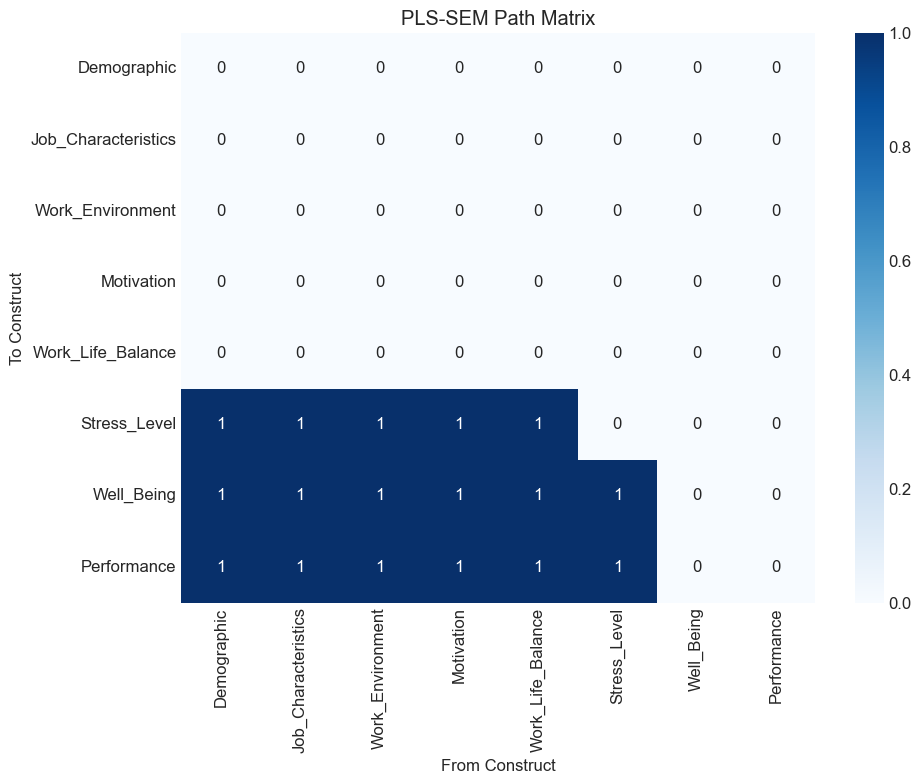

In [27]:
# Importing necessary libraries for PLS-SEM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from plspm.config import Config
from plspm.plspm import Plspm
from plspm.scale import Scale
from plspm.scheme import Scheme
from plspm.mode import Mode

# Define the main constructs for our model
constructs = [
    "Demographic",        # Demographic factors
    "Job_Characteristics", # Job-related variables
    "Work_Environment",   # Work environment factors
    "Motivation",         # Motivation and engagement
    "Work_Life_Balance",  # Work-life balance
    "Stress_Level",       # Stress (outcome)
    "Well_Being",         # Well-being (outcome)
    "Performance"         # Performance (outcome)
]

# Define the path relationships (structural model)
# Empty list means the construct doesn't depend on any other construct
path_matrix = np.zeros((len(constructs), len(constructs)))
path_matrix[5, 0] = 1  # Stress_Level depends on Demographic
path_matrix[5, 1] = 1  # Stress_Level depends on Job_Characteristics
path_matrix[5, 2] = 1  # Stress_Level depends on Work_Environment
path_matrix[5, 3] = 1  # Stress_Level depends on Motivation
path_matrix[5, 4] = 1  # Stress_Level depends on Work_Life_Balance
#path_matrix[5, 6] = 1  # Stress level depends on well being
 
path_matrix[6, 0] = 1  # Well_Being depends on Demographic
path_matrix[6, 1] = 1  # Well_Being depends on Job_Characteristics
path_matrix[6, 2] = 1  # Well_Being depends on Work_Environment
path_matrix[6, 3] = 1  # Well_Being depends on Motivation
path_matrix[6, 4] = 1  # Well_Being depends on Work_Life_Balance
path_matrix[6, 5] = 1  # Well_Being depends on Stress_Level

path_matrix[7, 0] = 1  # Performance depends on Demographic
path_matrix[7, 1] = 1  # Performance depends on Job_Characteristics
path_matrix[7, 2] = 1  # Performance depends on Work_Environment
path_matrix[7, 3] = 1  # Performance depends on Motivation
path_matrix[7, 4] = 1  # Performance depends on Work_Life_Balance
path_matrix[7, 5] = 1  # Performance depends on Stress_Level

# Display the path matrix
plt.figure(figsize=(10, 8))
sns.heatmap(path_matrix, annot=True, cmap='Blues', xticklabels=constructs, yticklabels=constructs)
plt.title('PLS-SEM Path Matrix')
plt.xlabel('From Construct')
plt.ylabel('To Construct')
plt.tight_layout()
plt.show()

# SECTION 10: PREPARE DATA FOR PLS-SEM

Imputing missing values for Tools_Satisfaction
Prepared PLS-SEM dataset with 232 observations and 23 variables
Indicators being used: ['Age_Numeric', 'Gender_Numeric', 'Team_Productivity', 'Team_Milestones', 'Concentration', 'RemoteWork_Numeric', 'Communication_Issues', 'Tools_Satisfaction', 'Motivation', 'Work_Interest', 'Creativity', 'Work_Life_Balance', 'Time_Management', 'Flexibility', 'Stress_Level', 'Frustration', 'Task_Pressure', 'Coordination_Issues', 'Work_Enjoyment', 'Job_Satisfaction', 'Belonging', 'Performance', 'Country']

Sample of prepared data for PLS-SEM:
   Age_Numeric  Gender_Numeric  Team_Productivity  Team_Milestones  \
0            2               1                  4                4   
1            2               2                  5                5   
2            3               2                  5                5   
3            3               1                  4                4   
4            3               1                  3                2   



C:\Users\Camilo Daza\AppData\Local\Temp\ipykernel_25580\1684150212.py:145: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_plssem[ind].fillna(df_plssem[ind].mean(), inplace=True)


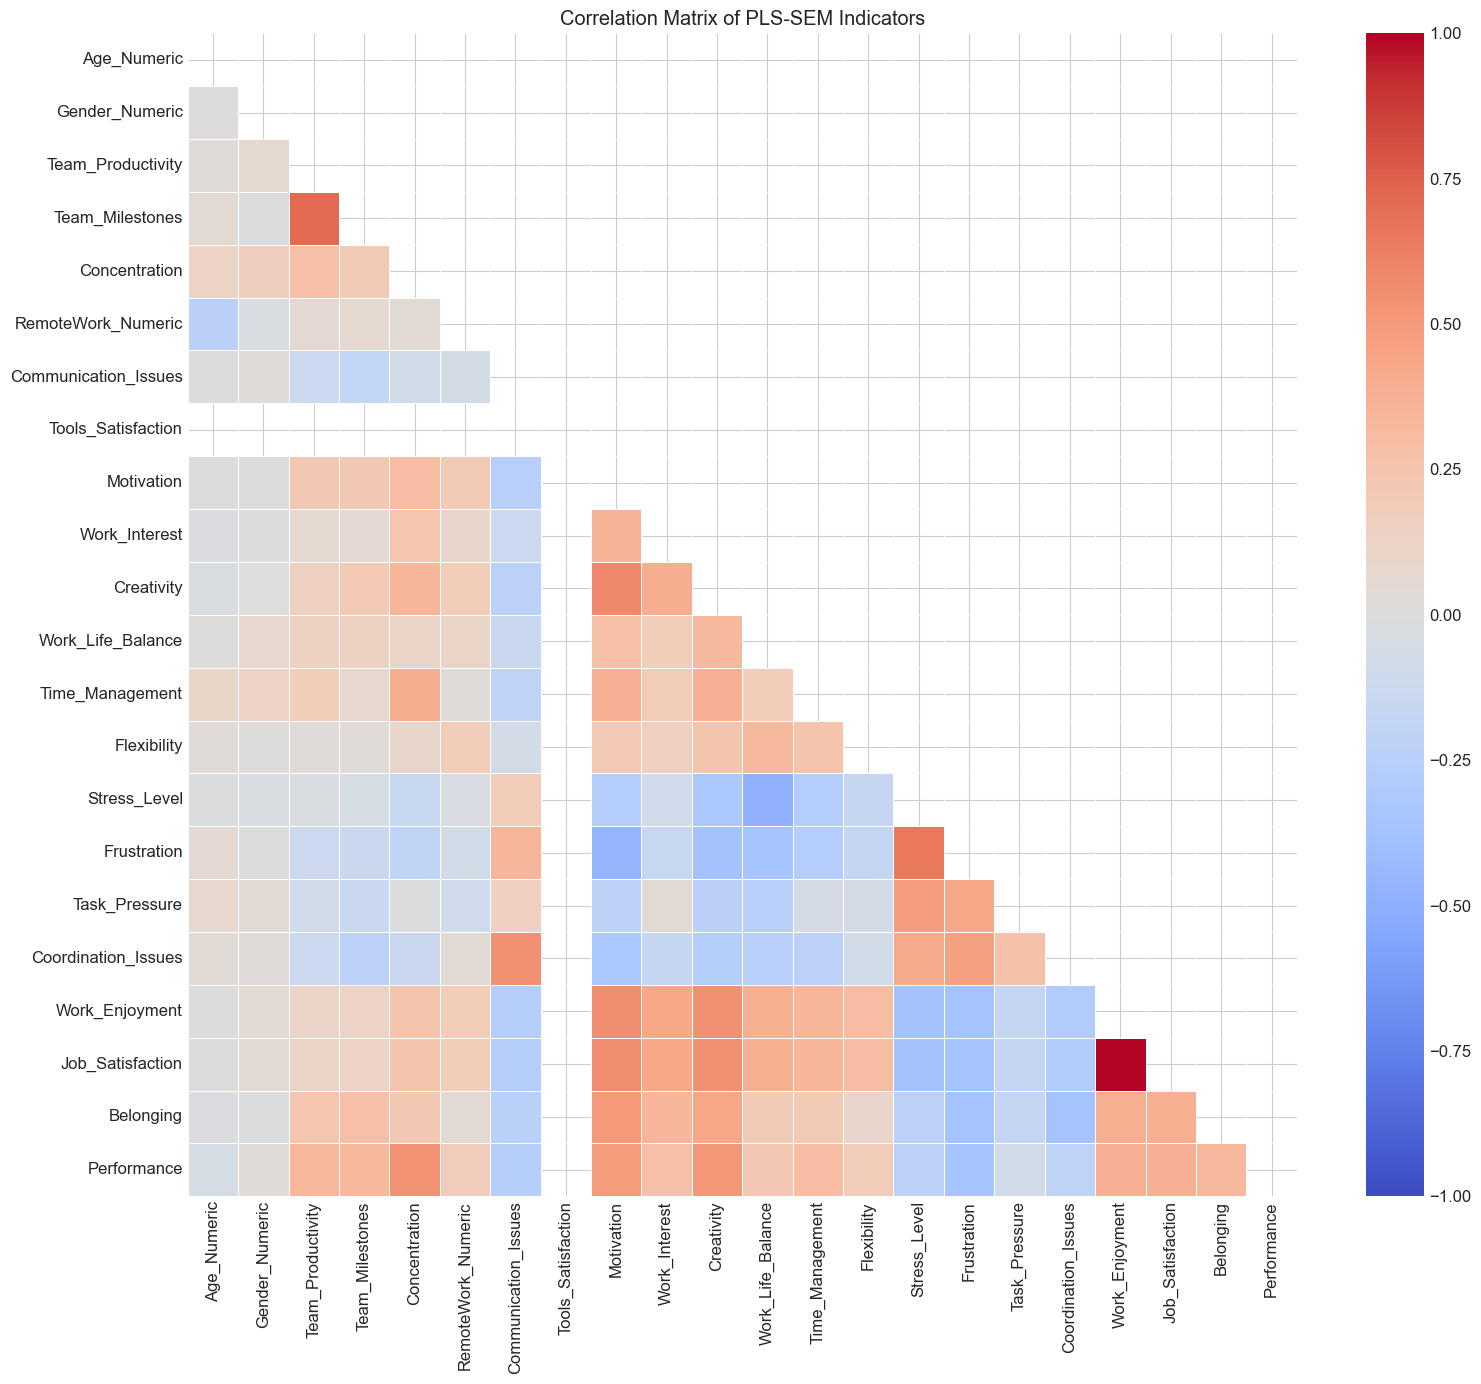

In [44]:
# Function to prepare data for PLS-SEM analysis
def prepare_data_for_plssem(df):
    """
    Prepare the dataset for PLS-SEM analysis by:
    1. Renaming and recoding variables
    2. Creating latent variable indicators
    3. Handling missing values
    4. Standardizing variables if needed
    """
    # Start with the cleaned data
    df_plssem = df_clean.copy()
    
    # Create aggregate indicators for each construct
    
    # 1. Demographic construct indicators
    # Convert categorical variables to appropriate numeric codes
    if 'Age_Range' in df_plssem.columns:
        # Map age groups to numeric values
        age_mapping = {
            '<25 años': 1,
            '25-35 años': 2,
            '36-45 años': 3,
            '46-55 años': 4,
            '>56 años': 5
        }
        df_plssem['Age_Numeric'] = df_plssem['Age_Range'].map(age_mapping)
    
    if 'Gender' in df_plssem.columns:
        # Map gender to numeric values
        gender_mapping = {
            'Masculino': 1,
            'Femenino': 2,
            'No binario': 3
        }
        df_plssem['Gender_Numeric'] = df_plssem['Gender'].map(gender_mapping)
    
    # Add education level (may already exist in your data with a different name)
    if 'Nivel_Estudios' in df_plssem.columns:
        # Map education levels to numeric values if needed
        education_mapping = {
            'Estudios primarios': 1,
            'Estudios secundarios': 2,
            'Universitarios en curso': 3,
            'Universitarios completo': 4,
            'Postgrado': 5
        }
        df_plssem['Education_Level'] = df_plssem['Nivel_Estudios'].map(education_mapping)
    
    # 2. Job Characteristics construct indicators
    # Already have these variables from previous analysis
    job_characteristics = ['Team_Productivity', 'Team_Milestones', 'Concentration']
    
    # 3. Work Environment construct indicators
    # Map RemoteWork_Level to numeric
    if 'RemoteWork_Level' in df_plssem.columns:
        remote_mapping = {
            'Alto': 2,  # High remote work
            'Bajo': 1   # Low remote work
        }
        df_plssem['RemoteWork_Numeric'] = df_plssem['RemoteWork_Level'].map(remote_mapping)
    
    # Communication issues
    if 'Communication_Issues' not in df_plssem.columns and 'Problemas_Comunicacion' in df_plssem.columns:
        df_plssem['Communication_Issues'] = df_plssem['Problemas_Comunicacion']
    
    # Technical tools satisfaction
    if 'Tools_Satisfaction' not in df_plssem.columns and 'Las herramientas de comunicación (Teams, Zoom, Slack,...) utilizadas por mi empresa, desde casa:' in df.columns:
        df_plssem['Tools_Satisfaction'] = df['Las herramientas de comunicación (Teams, Zoom, Slack,...) utilizadas por mi empresa, desde casa:'].map(ordinal_mapping)
    
    # 4. Motivation construct indicators
    motivation_vars = ['Motivation', 'Work_Enjoyment', 'Work_Interest', 'Creativity']
    
    # 5. Work-Life Balance construct indicators
    if 'Work_Life_Balance' not in df_plssem.columns and 'Equilibrio_VidaPersonal' in df_plssem.columns:
        df_plssem['Work_Life_Balance'] = df_plssem['Equilibrio_VidaPersonal']
    
    # Time management
    if 'Time_Management' not in df_plssem.columns and 'Manejo_Tiempo' in df_plssem.columns:
        df_plssem['Time_Management'] = df_plssem['Manejo_Tiempo']
    
    # Flexibility
    if 'Flexibility' not in df_plssem.columns and 'Nivel_Flexibilidad' in df_plssem.columns:
        df_plssem['Flexibility'] = df_plssem['Nivel_Flexibilidad']
    
    # 6. Stress Level construct indicators
    stress_vars = ['Stress_Level', 'Frustration', 'Task_Pressure', 'Coordination_Issues']
    
    # 7. Well-Being construct indicators
    if 'Job_Satisfaction' not in df_plssem.columns:
        # Job satisfaction might be derived from work enjoyment if not directly available
        df_plssem['Job_Satisfaction'] = df_plssem['Work_Enjoyment'] if 'Work_Enjoyment' in df_plssem.columns else None
    
    if 'Belonging' not in df_plssem.columns and 'Sentimiento_Pertenencia' in df_plssem.columns:
        df_plssem['Belonging'] = df_plssem['Sentimiento_Pertenencia']
    
    # Define key indicators for each construct based on what's actually available in the data
    # This avoids errors when variables don't exist
    
    # First, check which potential indicators actually exist in our dataframe
    available_indicators = {
        'Demographic': [col for col in ['Age_Numeric', 'Gender_Numeric', 'Education_Level'] 
                        if col in df_plssem.columns],
        'Job_Characteristics': [col for col in ['Team_Productivity', 'Team_Milestones', 'Concentration'] 
                              if col in df_plssem.columns],
        'Work_Environment': [col for col in ['RemoteWork_Numeric', 'Communication_Issues', 'Tools_Satisfaction'] 
                          if col in df_plssem.columns],
        'Motivation': [col for col in ['Motivation', 'Work_Interest', 'Creativity'] 
                     if col in df_plssem.columns],
        'Work_Life_Balance': [col for col in ['Work_Life_Balance', 'Time_Management', 'Flexibility'] 
                           if col in df_plssem.columns],
        'Stress_Level': [col for col in ['Stress_Level', 'Frustration', 'Task_Pressure', 'Coordination_Issues'] 
                       if col in df_plssem.columns],
        'Well_Being': [col for col in ['Work_Enjoyment', 'Job_Satisfaction', 'Belonging'] 
                     if col in df_plssem.columns],
        'Performance': [col for col in ['Performance'] 
                      if col in df_plssem.columns]
    }
    
    # For each construct, ensure we have at least one indicator
    for construct, ind_list in available_indicators.items():
        if not ind_list:
            print(f"Warning: No indicators available for {construct}. Creating a proxy.")
            
            # Create proxy based on related constructs
            if construct == 'Performance' and 'Well_Being' in available_indicators and available_indicators['Well_Being']:
                # Use well-being as proxy for performance if needed
                proxy_col = available_indicators['Well_Being'][0]
                df_plssem[f'{construct}_Proxy'] = df_plssem[proxy_col]
                available_indicators[construct] = [f'{construct}_Proxy']
            elif construct == 'Well_Being' and 'Performance' in available_indicators and available_indicators['Performance']:
                # Use performance as proxy for well-being if needed
                proxy_col = available_indicators['Performance'][0]
                df_plssem[f'{construct}_Proxy'] = df_plssem[proxy_col]
                available_indicators[construct] = [f'{construct}_Proxy']
            else:
                # Create a default proxy (this is not ideal but prevents errors)
                df_plssem[f'{construct}_Proxy'] = 3  # Neutral value
                available_indicators[construct] = [f'{construct}_Proxy']
    
    # Handle missing values for each indicator
    for construct, ind_list in available_indicators.items():
        for ind in ind_list:
            if df_plssem[ind].isna().any():
                print(f"Imputing missing values for {ind}")
                df_plssem[ind].fillna(df_plssem[ind].mean(), inplace=True)
    
    # Ensure all indicators are numeric
    for construct, ind_list in available_indicators.items():
        for ind in ind_list:
            if not pd.api.types.is_numeric_dtype(df_plssem[ind]):
                print(f"Converting {ind} to numeric")
                df_plssem[ind] = pd.to_numeric(df_plssem[ind], errors='coerce')
                df_plssem[ind].fillna(df_plssem[ind].mean(), inplace=True)
    
    # Select only the indicators needed for the PLS-SEM analysis
    needed_columns = []
    for ind_list in available_indicators.values():
        needed_columns.extend(ind_list)
    
    # Also include Country for the country-specific analysis
    if 'Country' in df_plssem.columns:
        needed_columns.append('Country')
    
    # Extract only the needed columns
    df_plssem_final = df_plssem[needed_columns].copy()
    
    print(f"Prepared PLS-SEM dataset with {len(df_plssem_final)} observations and {len(needed_columns)} variables")
    print(f"Indicators being used: {needed_columns}")
    
    return df_plssem_final, available_indicators

# Prepare the data for PLS-SEM
df_plssem, indicators = prepare_data_for_plssem(df_clean)

# Display the first few rows of the prepared data
print("\nSample of prepared data for PLS-SEM:")
print(df_plssem.head())

# Display indicators for each construct
print("\nIndicators used for each construct:")
for construct, ind_list in indicators.items():
    print(f"{construct}: {ind_list}")

# Check correlation between indicators
print("\nCorrelation between key indicators:")
plt.figure(figsize=(16, 14))
correlation_matrix = df_plssem.drop(columns=['Country'] if 'Country' in df_plssem.columns else []).corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
           linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of PLS-SEM Indicators')
plt.tight_layout()
plt.show()


# SECTION 11: PLS-SEM MODEL

In [38]:
# Create the PLS-SEM model configuration
def create_plssem_config(indicators):
    """
    Create the PLS-SEM model configuration based on defined indicators
    """
    # The error message indicates that 'path' must be a Pandas DataFrame
    # So we need to convert our path dictionary to a DataFrame
    
    # First, create an empty matrix with all constructs
    all_constructs = list(indicators.keys())
    num_constructs = len(all_constructs)
    path_matrix = pd.DataFrame(0, index=all_constructs, columns=all_constructs)
    
    # Fill in the relationships according to our model
    # Define which constructs affect other constructs
    path_matrix.loc['Demographic', 'Stress_Level'] = 1
    path_matrix.loc['Job_Characteristics', 'Stress_Level'] = 1
    path_matrix.loc['Work_Environment', 'Stress_Level'] = 1
    path_matrix.loc['Motivation', 'Stress_Level'] = 1
    path_matrix.loc['Work_Life_Balance', 'Stress_Level'] = 1
    
    path_matrix.loc['Demographic', 'Well_Being'] = 1
    path_matrix.loc['Job_Characteristics', 'Well_Being'] = 1
    path_matrix.loc['Work_Environment', 'Well_Being'] = 1
    path_matrix.loc['Motivation', 'Well_Being'] = 1
    path_matrix.loc['Work_Life_Balance', 'Well_Being'] = 1
    path_matrix.loc['Stress_Level', 'Well_Being'] = 1
    
    path_matrix.loc['Demographic', 'Performance'] = 1
    path_matrix.loc['Job_Characteristics', 'Performance'] = 1
    path_matrix.loc['Work_Environment', 'Performance'] = 1
    path_matrix.loc['Motivation', 'Performance'] = 1
    path_matrix.loc['Work_Life_Balance', 'Performance'] = 1
    path_matrix.loc['Stress_Level', 'Performance'] = 1
    
    print("Path matrix created as DataFrame:")
    print(path_matrix)
    
    try:
        # Based on error messages, Config expects a path matrix as DataFrame
        # And it might not use 'scales' as a parameter name
        config = Config(path_matrix)
        
        # Now set the scales/modes according to our indicators
        for construct, indicators_list in indicators.items():
            if len(indicators_list) > 0:
                # Set the manifest variables for each construct
                config.add_scale(construct, indicators_list, Mode.A)
                
        return config
    except Exception as e:
        print(f"Error creating Config: {str(e)}")
        raise

# Run the PLS-SEM model
def run_plssem(df_plssem, indicators):
    """
    Run the PLS-SEM model and return results
    """
    # Create the configuration
    config = create_plssem_config(indicators)
    
    # Run the PLS-SEM algorithm
    plspm_model = Plspm(df_plssem, config, scheme=Scheme.PATH, 
                       mode=Mode.A, scaled=False)
    
    return plspm_model

# Run the PLS-SEM model
try:
    plspm_model = run_plssem(df_plssem, indicators)
    
    # Print basic model results
    print("\nPLS-SEM Model Results:")
    print("\nPath Coefficients (Inner Model):")
    print(plspm_model.inner_model())
    
    print("\nOuter Model (Loadings):")
    print(plspm_model.outer_model())
    
    print("\nR-squared Values:")
    print(plspm_model.r_squared())
    
    print("\nModel Quality Metrics:")
    print("Cronbach's Alpha:")
    print(plspm_model.alpha())
    print("\nComposite Reliability:")
    print(plspm_model.rho())
    print("\nAverage Variance Extracted (AVE):")
    print(plspm_model.ave())
    print("\nGoodness of Fit:")
    print(plspm_model.gof())
    
except Exception as e:
    print(f"Error running PLS-SEM model: {str(e)}")
    print("Attempting alternative approach...")
    
    # If the standard PLSPM fails, we'll implement a simplified version using other approaches
    from sklearn.decomposition import PCA
    from sklearn.linear_model import LinearRegression
    
    # Function to run simplified alternative to PLS-SEM
    def simplified_plssem(df, indicators):
        results = {}
        
        # 1. Use PCA to create latent variables from indicators
        latent_scores = {}
        for construct, ind_list in indicators.items():
            if len(ind_list) > 1:
                # Use PCA to create latent variable
                pca = PCA(n_components=1)
                latent_scores[construct] = pca.fit_transform(df[ind_list])
            else:
                # Use the indicator directly if only one
                latent_scores[construct] = df[ind_list].values
        
        # 2. Run regressions for the structural model
        # Stress Level regression
        X_stress = np.hstack([
            latent_scores['Demographic'],
            latent_scores['Job_Characteristics'],
            latent_scores['Work_Environment'],
            latent_scores['Motivation'],
            latent_scores['Work_Life_Balance']
        ])
        y_stress = latent_scores['Stress_Level']
        stress_model = LinearRegression().fit(X_stress, y_stress)
        
        # Get coefficients and R²
        stress_coef = {
            'Demographic': stress_model.coef_[0] if X_stress.shape[1] > 0 else None,
            'Job_Characteristics': stress_model.coef_[1] if X_stress.shape[1] > 1 else None,
            'Work_Environment': stress_model.coef_[2] if X_stress.shape[1] > 2 else None,
            'Motivation': stress_model.coef_[3] if X_stress.shape[1] > 3 else None,
            'Work_Life_Balance': stress_model.coef_[4] if X_stress.shape[1] > 4 else None
        }
        stress_r2 = stress_model.score(X_stress, y_stress)
        
        # Well-Being regression
        X_wellbeing = np.hstack([
            latent_scores['Demographic'],
            latent_scores['Job_Characteristics'],
            latent_scores['Work_Environment'],
            latent_scores['Motivation'],
            latent_scores['Work_Life_Balance'],
            latent_scores['Stress_Level']
        ])
        y_wellbeing = latent_scores['Well_Being']
        wellbeing_model = LinearRegression().fit(X_wellbeing, y_wellbeing)
        
        # Get coefficients and R²
        wellbeing_coef = {
            'Demographic': wellbeing_model.coef_[0] if X_wellbeing.shape[1] > 0 else None,
            'Job_Characteristics': wellbeing_model.coef_[1] if X_wellbeing.shape[1] > 1 else None,
            'Work_Environment': wellbeing_model.coef_[2] if X_wellbeing.shape[1] > 2 else None,
            'Motivation': wellbeing_model.coef_[3] if X_wellbeing.shape[1] > 3 else None,
            'Work_Life_Balance': wellbeing_model.coef_[4] if X_wellbeing.shape[1] > 4 else None,
            'Stress_Level': wellbeing_model.coef_[5] if X_wellbeing.shape[1] > 5 else None
        }
        wellbeing_r2 = wellbeing_model.score(X_wellbeing, y_wellbeing)
        
        # Performance regression
        X_performance = np.hstack([
            latent_scores['Demographic'],
            latent_scores['Job_Characteristics'],
            latent_scores['Work_Environment'],
            latent_scores['Motivation'],
            latent_scores['Work_Life_Balance'],
            latent_scores['Stress_Level']
        ])
        y_performance = latent_scores['Performance']
        performance_model = LinearRegression().fit(X_performance, y_performance)
        
        # Get coefficients and R²
        performance_coef = {
            'Demographic': performance_model.coef_[0] if X_performance.shape[1] > 0 else None,
            'Job_Characteristics': performance_model.coef_[1] if X_performance.shape[1] > 1 else None,
            'Work_Environment': performance_model.coef_[2] if X_performance.shape[1] > 2 else None,
            'Motivation': performance_model.coef_[3] if X_performance.shape[1] > 3 else None,
            'Work_Life_Balance': performance_model.coef_[4] if X_performance.shape[1] > 4 else None,
            'Stress_Level': performance_model.coef_[5] if X_performance.shape[1] > 5 else None
        }
        performance_r2 = performance_model.score(X_performance, y_performance)
        
        # Store results
        results['stress_coefficients'] = stress_coef
        results['stress_r2'] = stress_r2
        results['wellbeing_coefficients'] = wellbeing_coef
        results['wellbeing_r2'] = wellbeing_r2
        results['performance_coefficients'] = performance_coef
        results['performance_r2'] = performance_r2
        
        return results
    
    # Run the simplified model
    simplified_results = simplified_plssem(df_plssem, indicators)
    
    # Print simplified results
    print("\nSimplified Model Results:")
    print("\nStress Level Path Coefficients:")
    for construct, coef in simplified_results['stress_coefficients'].items():
        if coef is not None:
            print(f"{construct}: {coef:.4f}")
    print(f"R² for Stress Level: {simplified_results['stress_r2']:.4f}")
    
    print("\nWell-Being Path Coefficients:")
    for construct, coef in simplified_results['wellbeing_coefficients'].items():
        if coef is not None:
            print(f"{construct}: {coef:.4f}")
    print(f"R² for Well-Being: {simplified_results['wellbeing_r2']:.4f}")
    
    print("\nPerformance Path Coefficients:")
    for construct, coef in simplified_results['performance_coefficients'].items():
        if coef is not None:
            print(f"{construct}: {coef:.4f}")
    print(f"R² for Performance: {simplified_results['performance_r2']:.4f}")


Path matrix created as DataFrame:
                     Demographic  Job_Characteristics  Work_Environment  \
Demographic                    0                    0                 0   
Job_Characteristics            0                    0                 0   
Work_Environment               0                    0                 0   
Motivation                     0                    0                 0   
Work_Life_Balance              0                    0                 0   
Stress_Level                   0                    0                 0   
Well_Being                     0                    0                 0   
Performance                    0                    0                 0   

                     Motivation  Work_Life_Balance  Stress_Level  Well_Being  \
Demographic                   0                  0             1           1   
Job_Characteristics           0                  0             1           1   
Work_Environment              0                  0

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values